# Consolidated analysis notebook

1. Import all relevant data  
   - first the current-study data  
   - then auxotrophy/reference data from other papers  
2. Generate all downstream dataframes  
3. Run the random forest model
   - due to long runtime, data is pulled from a specific run of the model
   - reruning the model may give slighty different results than those presented in the manuscript    
5. Generate figures in manuscript order  


In [2]:
# Imports and setup
import math
import re
import itertools
import statistics as stats
import warnings

import numpy as np
import pandas as pd
import seaborn as sns

import scipy as sp
from scipy.integrate import simpson
from scipy.optimize import curve_fit
from scipy.stats import mannwhitneyu, spearmanr

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Rectangle
from matplotlib import gridspec
from matplotlib.cm import ScalarMappable

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statannotations.Annotator import Annotator

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone

from joblib import Parallel, delayed, dump, load
import cld4py
import shap


sns.set(style="ticks", font_scale=2)

warnings.filterwarnings("ignore", message=".*points cannot be placed.*")
pd.set_option('future.no_silent_downcasting', True)


# 1. Import all relevant data

This section loads the raw/current-study datasets first, followed by the external auxotrophy and reference datasets.


## 1.1 Current-study raw data

In [5]:
#Create Dataframes
single_reads_dict={}

for bug in ["Bs","Ec"]:
    for n in range(1,4):
        file= "Data/Crossfeeding Experiments/"+bug+"_data_Ex"+str(n)+".xlsx"
        print (file)
        xl = pd.ExcelFile(file)
        
        if file == "Data/Crossfeeding Experiments/Bs_data_Ex1.xlsx":
            for i in xl.sheet_names:
                dataset= pd.read_excel(file, sheet_name=i,skiprows=32,
                                       usecols="A:M", index_col= "Unnamed: 0")    
                single_reads_dict[bug+"_"+str(n)+"_"+i]=dataset.dropna()
                
        else:            
            for i in xl.sheet_names:
                dataset= pd.read_excel(file, sheet_name=i,skiprows=23,
                                           usecols="B:N", index_col= "Unnamed: 1")    
                single_reads_dict[bug+"_"+str(n)+"_"+i]=dataset.dropna()

Data/Crossfeeding Experiments/Bs_data_Ex1.xlsx
Data/Crossfeeding Experiments/Bs_data_Ex2.xlsx
Data/Crossfeeding Experiments/Bs_data_Ex3.xlsx
Data/Crossfeeding Experiments/Ec_data_Ex1.xlsx
Data/Crossfeeding Experiments/Ec_data_Ex2.xlsx
Data/Crossfeeding Experiments/Ec_data_Ex3.xlsx


## 1.2 Auxotrophy/reference data from other papers

In [7]:
# Pathway gene list used by the KO analyses
pathway_genes_df = pd.read_csv("Data/AA_synthesis_pathways.csv")

# Koo et al. B. subtilis KO dataset
bs_KO_data_raw = pd.read_excel("Data/Koo et al Data.xlsx",
                               sheet_name="B", skiprows=24)

# Tong et al. E. coli endpoint biomass dataset
ec_KO_data_raw = pd.read_excel("Data/Tong et al Data.xlsx",
                               sheet_name="S1A - Endpoint Biomass")

# Wetmore et al. pooled fitness dataset
fit = pd.read_csv("Data/Wetmore et al Data/fit_logratios_good.tab", sep="\t")
genes = pd.read_csv("Data/Wetmore et al Data/fit_genes.tab", sep="\t")
q = pd.read_csv("Data/Wetmore et al Data/fit_quality.tab", sep="\t")

print("Koo raw shape:", bs_KO_data_raw.shape)
print("Tong raw shape:", ec_KO_data_raw.shape)
print("Wetmore fit shape:", fit.shape)


Koo raw shape: (3976, 51)
Tong raw shape: (3796, 32)
Wetmore fit shape: (3646, 96)


## 1.3 Amino-acid requirement datasets

In [9]:
#import datasets from each experiment
#Add Environment to last so all have the same columns

bs_exp1_df=pd.read_csv('Data/AA Requirments Experiments/AA_per_OD_df_Bsub_ex1.csv', index_col='Unnamed: 0')
bs_exp1_df["Species"]='Bs'
bs_exp1_df["Exp"]=1
# bs_exp1_df["Time"]=96

bs_exp2_df=pd.read_csv('Data/AA Requirments Experiments/AA_per_OD_df_Bsub_ex2.csv', index_col='Unnamed: 0')
bs_exp2_df["Species"]='Bs'
bs_exp2_df["Exp"]=2
# bs_exp1_df["Time"]=96

ec_exp1_df=pd.read_csv('Data/AA Requirments Experiments/AA_per_OD_df_Ecoli_ex1.csv', index_col='Unnamed: 0')
ec_exp1_df["Species"]='Ec'
ec_exp1_df["Exp"]=1
# bs_exp1_df["Time"]=96

ec_exp2_df=pd.read_csv('Data/AA Requirments Experiments/AA_per_OD_df_Ecoli_ex2.csv', index_col='Unnamed: 0').drop(columns='Time')
ec_exp2_df["Species"]='Ec'
ec_exp2_df["Exp"]=2
ec_exp2_df["Environment"]='Gluc_Glcn'
ec_exp2_df["C"]='Gluc'
ec_exp2_df["N"]='Glcn'

aa_requirments_df=pd.concat([bs_exp1_df, bs_exp2_df,
                  ec_exp1_df, ec_exp2_df], ignore_index=True)

print("AA requirement tables loaded.")


aa_requirments_dataset = pd.concat([bs_exp1_df, bs_exp2_df, ec_exp1_df, ec_exp2_df], ignore_index=True)
aa_requirments_dataset["aa_per_od"] = 1 / aa_requirments_dataset.Slope

aa_requirments_dataset.to_csv("Generated Tables/AA_requirments_dataset.csv", index=False)
aa_requirments_dataset.head(5)

AA requirement tables loaded.


,Aux,Environment,Num_of_points,R2,Slope,C,N,Species,Exp,aa_per_od
0,C,Fum_Glcn,8.0,0.722064,0.000550,Fum,Glcn,Bs,1,1819.354426
1,C,Gluc_Asn,6.0,0.971723,0.002439,Gluc,Asn,Bs,1,410.069178
2,C,Gluc_Glcn,6.0,0.975737,0.002341,Gluc,Glcn,Bs,1,427.210122
3,C,Gluc_Glut,8.0,0.947115,0.000918,Gluc,Glut,Bs,1,1089.874582
4,C,Gluc_NoN,6.0,0.966616,0.002046,Gluc,NoN,Bs,1,488.642609


# 2. Generate all downstream dataframes

## 2.1 Reconstruct the current-study assay tables

In [12]:
samples=((pd.read_excel("Data/Sample Names.xlsx",index_col=0 )))

# Normalize raw plate reads to plate blanks
norm_sr_dict = {}

for df_name, plate_df in single_reads_dict.items():
    blank = stats.mean([
        plate_df.at["G", 11], plate_df.at["G", 12],
        plate_df.at["H", 11], plate_df.at["H", 12]
    ])
    norm_sr_dict[df_name] = plate_df.sub(blank, axis=0)
    norm_sr_dict[df_name] = norm_sr_dict[df_name].round(3)
    norm_sr_dict[df_name] = norm_sr_dict[df_name].clip(lower=0.005)

# Build sample-name lookup
sample_name_dic = {}
for row in ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']:
    for col in range(1, 13):
        sample_name_dic[f"{row}{col}"] = samples.at[row, col]

# Flatten all plates into one long-form dataframe
nsr_dict = {}
for df_name in norm_sr_dict.keys():
    rows = []
    for row in ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']:
        for col in range(1, 13):
            rows.append({
                "Well": f"{row}{col}",
                "Environment": sample_name_dic[f"{row}{col}"],
                "OD": norm_sr_dict[df_name].at[row, col],
                "Species": df_name.split("_")[0],
                "Experiment": df_name.split("_")[1],
                "Pair": df_name.split("_")[2],
            })
    nsr_dict[df_name] = pd.DataFrame(rows)

merged_df = pd.concat(nsr_dict.values(), ignore_index=True)
merged_df = merged_df.replace({"WT": "WT+WT"})
merged_df[["N", "C"]] = merged_df["Environment"].str.split("+", expand=True)
merged_df[["Aux1", "Aux2"]] = merged_df["Pair"].str.split("+", expand=True)

merged_df["C"] = merged_df["C"].astype(str).str.strip()
merged_df["N"] = merged_df["N"].astype(str).str.strip()

merged_df.head()


,Well,Environment,OD,Species,Experiment,Pair,N,C,Aux1,Aux2
0,A1,Glut + Gluc,0.298,Bs,1,WT+WT,Glut,Gluc,WT,WT
1,A2,AmSu + Gluc,0.245,Bs,1,WT+WT,AmSu,Gluc,WT,WT
2,A3,Urea + Gluc,0.199,Bs,1,WT+WT,Urea,Gluc,WT,WT
3,A4,Asp + Gluc,0.356,Bs,1,WT+WT,Asp,Gluc,WT,WT
4,A5,Asn + Gluc,0.104,Bs,1,WT+WT,Asn,Gluc,WT,WT


In [13]:
# Build mean/SEM tables and crossfeeding-normalized dataframe

monos_df = merged_df[(merged_df.Aux1 == merged_df.Aux2) & (merged_df.Aux1 != "WT")].copy()
monos_df["OD"] = monos_df["OD"].astype(float)

mono_growth_for_norm_m = monos_df.groupby(["Environment", "Species", "Aux1"]).mean(numeric_only=True)["OD"].reset_index()
mono_growth_for_norm_e = monos_df.groupby(["Environment", "Species", "Aux1"]).sem(numeric_only=True)["OD"].reset_index()
mono_growth_for_norm = pd.merge(mono_growth_for_norm_m, mono_growth_for_norm_e, on=["Environment", "Species", "Aux1"])
mono_growth_for_norm = mono_growth_for_norm.rename(columns={"Aux1": "mono_aux", 
                                                            "OD_x": "Aux_OD_for_norm_mean",
                                                            "OD_y": "Aux_OD_for_norm_sem"})

mean_df = merged_df.groupby(["Environment", "Species", "Pair",
                             "N", "C", "Aux1", "Aux2"])["OD"].mean().reset_index().rename(columns={"OD": "Mean"})
sem_df = merged_df.groupby(["Environment", "Species", "Pair",
                            "N", "C", "Aux1", "Aux2"])["OD"].sem().reset_index().rename(columns={"OD": "SEM"})
big_df = pd.merge(mean_df, sem_df, on=["Environment", "Species", "Pair", "N", "C", "Aux1", "Aux2"])

big_norm_df = pd.merge(big_df, mono_growth_for_norm, how="outer",
                       left_on=["Environment", "Species", "Aux1"],
                       right_on=["Environment", "Species", "mono_aux"])

big_norm_df = pd.merge(big_norm_df, mono_growth_for_norm, how="outer", suffixes=["1", "2"],
                       left_on=["Environment", "Species", "Aux2"],
                       right_on=["Environment", "Species", "mono_aux"])

big_norm_df["Auxs_growth_wo_AA"] = big_norm_df["Aux_OD_for_norm_mean1"] + big_norm_df["Aux_OD_for_norm_mean2"]
big_norm_df["Norm_mean"] = big_norm_df["Mean"] - big_norm_df["Auxs_growth_wo_AA"]
# big_norm_df["Norm_sem"] = np.sqrt((big_norm_df["SEM"])**2 - (np.sqrt((big_norm_df["Aux_OD_for_norm_sem1"]**2) +
#                                                                      big_norm_df["Aux_OD_for_norm_sem2"]**2)**2))

big_norm_df["Norm_sem"] = np.sqrt(big_norm_df["SEM"]**2 + 
                                  big_norm_df["Aux_OD_for_norm_sem1"]**2 +
                                  big_norm_df["Aux_OD_for_norm_sem2"]**2)

big_norm_df["Norm_mean"] = big_norm_df["Norm_mean"].clip(lower=0.005)
big_norm_df["Norm_mean"] = big_norm_df["Norm_mean"].fillna(big_norm_df["Mean"])
big_norm_df["Norm_sem"] = big_norm_df["Norm_sem"].fillna(0)

# Add amino-acid supplemented control means and SEMs
aa_dic = {}
for pair in ['WT+WT', 'M+Met', 'F+Phe', 'R+Arg', 'C+Cys', 'S+Ser', 'L+Leu']:
    aa_dic[pair] = big_df[big_df.Pair == pair].rename(columns={'Mean': pair.split('+')[0] + "_mean",
                                                               'SEM': pair.split('+')[0] + "_sem",
                                                               'C': 'CS','N': 'NS'}).drop(columns=['Pair', 'Aux1', 'Aux2'])

aa_df = aa_dic["WT+WT"]
for pair in ['M+Met', 'F+Phe', 'R+Arg', 'C+Cys', 'S+Ser', 'L+Leu']:
    aa_df = pd.merge(aa_df, aa_dic[pair], on=['Environment', 'Species', 'NS', 'CS'])

big_norm_df = pd.merge(big_norm_df, aa_df, how='left', 
                       left_on=['Environment', 'Species', 'C', 'N'],
                       right_on=['Environment', 'Species', 'CS', 'NS'])

def pick_stats(row, suffix):
    return row[f"{row['Aux1']}{suffix}"], row[f"{row['Aux2']}{suffix}"]

max_means, min_means, max_sems, min_sems = [], [], [], []
drop_idx = []

for idx, r in big_norm_df.iterrows():
    if r["Aux1"] in ['M','F','R','C','S','L',"WT"] and r["Aux2"] in ['M','F','R','C','S','L',"WT"]:
        m1, m2 = pick_stats(r, "_mean")
        e1, e2 = pick_stats(r, "_sem")
        if m1 >= m2:
            max_means.append(m1); max_sems.append(e1)
            min_means.append(m2); min_sems.append(e2)
        else:
            max_means.append(m2); max_sems.append(e2)
            min_means.append(m1); min_sems.append(e1)
    else:
        drop_idx.append(idx)

if drop_idx:
    big_norm_df = big_norm_df.drop(index=drop_idx)

big_norm_df["max_aux_mean"] = max_means
big_norm_df["max_aux_sem"] = max_sems
big_norm_df["min_aux_mean"] = min_means
big_norm_df["min_aux_sem"] = min_sems

big_norm_df["C"] = big_norm_df["C"].astype(str).str.strip()
big_norm_df["N"] = big_norm_df["N"].astype(str).str.strip()
big_norm_df.to_csv("Generated Tables/big_norm_df.csv", index=False)

big_norm_df.head()


,Environment,Species,Pair,N,C,Aux1,Aux2,Mean,SEM,mono_aux1,...,C_mean,C_sem,S_mean,S_sem,L_mean,L_sem,max_aux_mean,max_aux_sem,min_aux_mean,min_aux_sem
1,Ala + Fum,Bs,C+C,Ala,Fum,C,C,0.005000,0.000000,C,...,0.052,0.009957,0.064667,0.004072,0.156667,0.022208,0.052000,0.009957,0.052000,0.009957
2,Ala + Fum,Bs,F+C,Ala,Fum,F,C,0.020500,0.005353,F,...,0.052,0.009957,0.064667,0.004072,0.156667,0.022208,0.052000,0.009957,0.045667,0.014906
3,Ala + Fum,Bs,M+C,Ala,Fum,M,C,0.010833,0.003390,M,...,0.052,0.009957,0.064667,0.004072,0.156667,0.022208,0.104500,0.004048,0.052000,0.009957
4,Ala + Fum,Bs,R+C,Ala,Fum,R,C,0.029167,0.001376,R,...,0.052,0.009957,0.064667,0.004072,0.156667,0.022208,0.052000,0.009957,0.029500,0.004249
6,Ala + Fum,Bs,F+F,Ala,Fum,F,F,0.010167,0.003936,F,...,0.052,0.009957,0.064667,0.004072,0.156667,0.022208,0.045667,0.014906,0.045667,0.014906


In [14]:
# Identify auxotrophs that are NOT obligate in a given environment/species
dataset_to_filter_from = big_norm_df.query("Aux1 == Aux2 and Aux1 != 'WT' and Mean > 0.02").copy()

bad_aux = (dataset_to_filter_from[['Environment', 'Species', 'Aux1']].drop_duplicates().rename(columns={'Aux1': 'Aux'}))

# Build an index for fast membership tests
bad_idx = pd.MultiIndex.from_frame(bad_aux[['Environment', 'Species', 'Aux']])

# Add flags directly onto big_norm_df
big_norm_df = big_norm_df.copy()

big_norm_df['Aux1_bad'] = pd.MultiIndex.from_frame(
    big_norm_df[['Environment', 'Species', 'Aux1']]
    .rename(columns={'Aux1': 'Aux'})).isin(bad_idx)

big_norm_df['Aux2_bad'] = pd.MultiIndex.from_frame(
    big_norm_df[['Environment', 'Species', 'Aux2']]
    .rename(columns={'Aux2': 'Aux'})).isin(bad_idx)

big_norm_df['filtered_out'] = big_norm_df['Aux1_bad'] | big_norm_df['Aux2_bad']

# Then filtered_df becomes trivial
filtered_df = big_norm_df.loc[~big_norm_df['filtered_out']].copy()

filtered_df[['Mean', 'WT_mean', 'Norm_mean']] = filtered_df[['Mean', 'WT_mean', 'Norm_mean']].astype(float)
filtered_df['C'] = filtered_df['C'].astype(str).str.strip()
filtered_df['N'] = filtered_df['N'].astype(str).str.strip()

filtered_df.to_csv('Generated Tables/filtered_df.csv', index=False)
filtered_df.head()

,Environment,Species,Pair,N,C,Aux1,Aux2,Mean,SEM,mono_aux1,...,S_sem,L_mean,L_sem,max_aux_mean,max_aux_sem,min_aux_mean,min_aux_sem,Aux1_bad,Aux2_bad,filtered_out
1,Ala + Fum,Bs,C+C,Ala,Fum,C,C,0.005000,0.000000,C,...,0.004072,0.156667,0.022208,0.052000,0.009957,0.052000,0.009957,False,False,False
2,Ala + Fum,Bs,F+C,Ala,Fum,F,C,0.020500,0.005353,F,...,0.004072,0.156667,0.022208,0.052000,0.009957,0.045667,0.014906,False,False,False
3,Ala + Fum,Bs,M+C,Ala,Fum,M,C,0.010833,0.003390,M,...,0.004072,0.156667,0.022208,0.104500,0.004048,0.052000,0.009957,False,False,False
4,Ala + Fum,Bs,R+C,Ala,Fum,R,C,0.029167,0.001376,R,...,0.004072,0.156667,0.022208,0.052000,0.009957,0.029500,0.004249,False,False,False
6,Ala + Fum,Bs,F+F,Ala,Fum,F,F,0.010167,0.003936,F,...,0.004072,0.156667,0.022208,0.045667,0.014906,0.045667,0.014906,False,False,False


## 2.2 Comparison tables used for cross-species plots

In [16]:
bs_df = filtered_df[filtered_df.Species == 'Bs'].copy()
ec_df = filtered_df[filtered_df.Species == 'Ec'].copy()

comp_species_df = pd.merge(bs_df, ec_df, 
                           on=['Environment', 'Pair', 'N', 'C', 'Aux1', 'Aux2'],
                           suffixes=['_Bs', '_Ec'])#.dropna()

# Supplemented monoculture dataframe across species
aa_dic = {}
for pair in ['WT+WT', 'M+Met', 'F+Phe', 'R+Arg', 'C+Cys', 'S+Ser', 'L+Leu']:
    aa_dic[pair] = big_df[big_df.Pair == pair].drop(columns=['Aux1', 'Aux2', 'SEM', 'C', 'N'])

comp_aa_df = aa_dic["WT+WT"]
for pair in ['M+Met', 'F+Phe', 'R+Arg', 'C+Cys', 'S+Ser', 'L+Leu']:
    comp_aa_df = pd.concat([comp_aa_df, aa_dic[pair]])

comp_aa_df_b = pd.merge(comp_aa_df.query("Species == 'Bs'"), 
                        comp_aa_df.query("Species == 'Ec'"), 
                        on=['Environment', 'Pair'], suffixes=['_Bs', '_Ec'])

aa_long = pd.merge(comp_aa_df_b.melt(id_vars=['Environment', 'Pair'], value_vars=['Mean_Bs', 'Mean_Ec'],
                                     var_name='Species', value_name='Mean')
                   .assign(Species=lambda d: d['Species'].str.replace('^Mean_', '', regex=True)),
                   comp_aa_df_b.melt(id_vars=['Environment', 'Pair'], value_vars=['Mean_Bs', 'Mean_Ec'],
                                     var_name='Species', value_name='SEM')
                   .assign(Species=lambda d: d['Species'].str.replace('^Mean_', '', regex=True)))

aa_long[['Aux1', 'Aux2']] = aa_long['Pair'].str.split("+", expand=True)
aa_long[['N', 'C']] = aa_long['Environment'].str.split("+", expand=True)
aa_long['Mean'] = aa_long['Mean'].astype(float)
aa_long.to_csv("Generated Tables/Supplemented_AA_data.csv", index=False)

In [17]:
# Crossfeeding long-form dataframe
df_long = pd.merge(
    comp_species_df.melt(id_vars=['Environment', 'Pair'], value_vars=['Norm_mean_Bs', 'Norm_mean_Ec'],
                         var_name='Species', value_name='Norm_mean').replace({"Norm_mean_Bs": "Bs", "Norm_mean_Ec": "Ec"}),
    comp_species_df.melt(id_vars=['Environment', 'Pair'], value_vars=['Norm_sem_Bs', 'Norm_sem_Ec'],
                         var_name='Species', value_name='Norm_sem').replace({"Norm_sem_Bs": "Bs", "Norm_sem_Ec": "Ec"})
)
df_long[['Aux1', 'Aux2']] = df_long['Pair'].str.split("+", expand=True)
df_long['Norm_mean'] = df_long['Norm_mean'].astype(float)

mean_by_env_df = filtered_df.groupby(['Environment', 'C', 'N', 'Species']).mean(numeric_only=True).reset_index()
mean_by_pair_df = filtered_df.groupby(['Pair', 'Aux1', 'Aux2', 'Species']).mean(numeric_only=True).reset_index()

comp_env_df = pd.merge(mean_by_env_df[mean_by_env_df.Species == 'Bs'],
                       mean_by_env_df[mean_by_env_df.Species == 'Ec'],
                       on=['Environment', 'N', 'C'], suffixes=['_Bs', '_Ec'])

comp_pair_df = pd.merge(mean_by_pair_df[mean_by_pair_df.Species == 'Bs'],
                        mean_by_pair_df[mean_by_pair_df.Species == 'Ec'],
                        on=['Pair', 'Aux1', 'Aux2'], suffixes=['_Bs', '_Ec'])

cf_comp_pair_df = comp_pair_df[comp_pair_df.Aux1 != 'WT'].copy()

In [18]:
# Auxotrophy summaries used in Figure 2A-B
data = big_norm_df.query("Aux1 == Aux2 and Aux1 != 'WT' and Species == 'Bs'").copy()
data = data.pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()
wt_data = filtered_df.query("Aux1 == 'WT' and Species == 'Bs'").pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()
cols = data.columns.difference(['Aux1', 'Species'])
data[cols] = data[cols].div(wt_data.loc[0, cols])
data['n_grows_01'] = (data[cols] > 0.1).sum(axis=1)/40*100
data['rank_01'] = data['n_grows_01'].rank(ascending=False, method='first')
data['n_grows_05'] = (data[cols] > 0.5).sum(axis=1)/40*100
data['rank_05'] = data['n_grows_05'].rank(ascending=False, method='first')
data['n_grows_1'] = (data[cols] > 1).sum(axis=1)/40*100
data['rank_1'] = data['n_grows_1'].rank(ascending=False, method='first')
bs_aux_growth = data.melt(id_vars=['Aux1', 'Species'], value_vars=['n_grows_01', 'n_grows_05', 'n_grows_1'])

data = big_norm_df.query("Aux1 == Aux2 and Aux1 != 'WT' and Species == 'Ec'").copy()
data = data.pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()
wt_data = filtered_df.query("Aux1 == 'WT' and Species == 'Ec'").pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()
cols = data.columns.difference(['Aux1', 'Species'])
data[cols] = data[cols].div(wt_data.loc[0, cols])
data['n_grows_01'] = (data[cols] > 0.1).sum(axis=1)/40*100
data['rank_01'] = data['n_grows_01'].rank(ascending=False, method='first')
data['n_grows_05'] = (data[cols] > 0.5).sum(axis=1)/40*100
data['rank_05'] = data['n_grows_05'].rank(ascending=False, method='first')
data['n_grows_1'] = (data[cols] > 1).sum(axis=1)/40*100
data['rank_1'] = data['n_grows_1'].rank(ascending=False, method='first')
ec_aux_growth = data.melt(id_vars=['Aux1', 'Species'], value_vars=['n_grows_01', 'n_grows_05', 'n_grows_1'])

## 2.3 External auxotrophy summary tables
### Koo et al
- https://doi.org/10.1016/j.cels.2016.12.013
- Table S4. Genome-wide growth phenotypes in several conditions (Sheet B)

In [20]:
# Expand pathway gene names used in the KO analysis
bsub_genes = list(pathway_genes_df["Gene"])
bsub_relevant_genes = []

for s in bsub_genes:
    s = str(s).strip()
    bsub_relevant_genes += (s.split('+', 1) if '+' in s else s.split('/', 1) if '/' in s else [s])

bsub_relevant_genes = [item.strip() for item in bsub_relevant_genes]
bsub_relevant_genes = sorted(list(set(bsub_relevant_genes)))

# Import and subset Koo et al. B. subtilis data
base_cols = ['locus_tag', 'gene',]
erm_cols = [c for c in bs_KO_data_raw.columns if c.startswith('nRF_ErmR_')]
kan_cols = [c for c in bs_KO_data_raw.columns if c.startswith('nRF_KanR_')]


bs_KO_data = bs_KO_data_raw[base_cols + erm_cols + kan_cols].dropna()


bs_KO_data = bs_KO_data[(bs_KO_data.gene.isin(bsub_relevant_genes)) | (bs_KO_data.gene == 'amyE')]


Erm_data = bs_KO_data[base_cols + erm_cols].copy()
Erm_data = Erm_data.rename(columns=lambda c: c.replace('nRF_ErmR_', '') if c.startswith('nRF_ErmR_') else c)
Erm_data = Erm_data.rename(columns=lambda c: c.replace('+', '_').replace('4_', '4') if c not in ['locus_tag', 'gene'] else c)
Erm_data['Casette'] = 'Erm'

Kan_data = bs_KO_data[base_cols + kan_cols].copy()
Kan_data = Kan_data.rename(columns=lambda c: c.replace('nRF_KanR_', '') if c.startswith('nRF_KanR_') else c)
Kan_data = Kan_data.rename(columns=lambda c: c.replace('+', '_').replace('4_', '4') if c not in ['locus_tag', 'gene'] else c)
Kan_data['Casette'] = 'Kan'


koo_df_bs_auxs = pd.concat([Erm_data, Kan_data], ignore_index=True)
koo_df_bs_auxs = koo_df_bs_auxs[['locus_tag', 'gene', 'glucose_NH4','glucose_glutamine','glucose_glutamate', 
                                 'glucose_ornithine','glucose_adenine','glucose_malate_NH4', 'glucose_nitrate',
                                 'malate_NH4', 'pyruvate_NH4', 'fructose_NH4','glycerol_NH4', 'gluconate_NH4',
                                 'succinate_glutamate', 'Casette']]

koo_df_bs_auxs = koo_df_bs_auxs.query(
    'glucose_NH4 < 0.1 or glucose_glutamine < 0.1 or glucose_glutamate < 0.1 or '
    'glucose_ornithine < 0.1 or glucose_adenine < 0.1 or glucose_malate_NH4 < 0.1 or '
    'malate_NH4 < 0.1 or pyruvate_NH4 < 0.1 or fructose_NH4 < 0.1 or glycerol_NH4 < 0.1 or '
    'gluconate_NH4 < 0.1 or succinate_glutamate < 0.1 or glucose_nitrate < 0.1'
).copy()

cols = koo_df_bs_auxs.columns.difference(['locus_tag', 'gene', 'Casette', 'glucose complete'])
koo_df_bs_auxs['n_grows_01'] = (koo_df_bs_auxs[cols] > 0.1).sum(axis=1)/13*100
koo_df_bs_auxs['rank_01'] = koo_df_bs_auxs['n_grows_01'].rank(ascending=False, method='first')
koo_df_bs_auxs['n_grows_05'] = (koo_df_bs_auxs[cols] > 0.5).sum(axis=1)/13*100
koo_df_bs_auxs['rank_05'] = koo_df_bs_auxs['n_grows_05'].rank(ascending=False, method='first')
koo_df_bs_auxs['n_grows_1'] = (koo_df_bs_auxs[cols] > 1).sum(axis=1)/13*100
koo_df_bs_auxs['rank_1'] = koo_df_bs_auxs['n_grows_1'].rank(ascending=False, method='first')
koo_df_bs_auxs.to_csv("Generated Tables/Koo_auxs_df_bs.csv", index=False)


### Tong et al. E. coli
- https://doi.org/10.1128/mbio.02259-20
- File (mbio.02259-20-st001.xlsx)

In [22]:
ec_genes = list(pathway_genes_df["Gene"])
ec_relevant_genes = []
for s in ec_genes:
    s = str(s)
    ec_relevant_genes += s.split('+', 1) if '+' in s else s.split('/', 1) if '/' in s else [s]
ec_relevant_genes = [x.strip() for x in ec_relevant_genes]

ec_KO_data = ec_KO_data_raw.copy()
ec_KO_data = ec_KO_data.rename(columns={'Gene':'gene'})
ec_KO_data[ec_KO_data.columns[2:]] = ec_KO_data[ec_KO_data.columns[2:]].astype(float)
ec_KO_data = ec_KO_data.dropna()
ec_KO_data = ec_KO_data[(ec_KO_data.gene.isin(ec_relevant_genes)) | (ec_KO_data.gene == 'kdsC')]

ec_auxs = ec_KO_data[((ec_KO_data[(ec_KO_data.columns[2:])] < 0.1).any(axis=1,)) | (ec_KO_data.gene == 'kdsC')].copy()

ec_normalized = ec_auxs.copy()
cols = ec_normalized.columns[2:]
ec_normalized[cols] = ec_normalized[cols].apply(pd.to_numeric, errors="coerce")
ec_normalized[cols] = ec_normalized[cols].div(ec_normalized.loc[303, cols])

tong_df_ec_auxs = ec_normalized.copy()[((ec_normalized[(ec_normalized.columns[2:])] < 0.1).any(axis=1,))].copy()
cols = tong_df_ec_auxs.columns.difference(['B-numbers', 'gene'])
tong_df_ec_auxs['n_grows_01'] = (tong_df_ec_auxs[cols] > 0.1).sum(axis=1)/30*100
tong_df_ec_auxs['rank_01'] = tong_df_ec_auxs['n_grows_01'].rank(ascending=False, method='first')
tong_df_ec_auxs['n_grows_05'] = (tong_df_ec_auxs[cols] > 0.5).sum(axis=1)/30*100
tong_df_ec_auxs['rank_05'] = tong_df_ec_auxs['n_grows_05'].rank(ascending=False, method='first')
tong_df_ec_auxs['n_grows_1'] = (tong_df_ec_auxs[cols] > 1).sum(axis=1)/30*100
tong_df_ec_auxs['rank_1'] = tong_df_ec_auxs['n_grows_1'].rank(ascending=False, method='first')
tong_df_ec_auxs.to_csv("Generated Tables/Tong_aux_df_ec.csv", index=False)




### Wetmore et al. pooled fitness
- https://doi.org/10.1128/mbio.00306-15
- Data found at this website: https://genomics.lbl.gov/supplemental/rbarseq/html/Keio/

- links on page as follows:
  - Gene annotations: fit_genes 
  - Gene fitness: fit_logratios_good
  - Experiments and quality scores: fit_quality

In [24]:
q_use = q.copy()
q_use = q_use[q_use["u"] == True]
q_use = q_use[~q_use["short"].str.contains("time0", case=False, na=False)]

id_cols = ["locusId", "sysName", "desc"]
exp_cols_full = [c for c in fit.columns if c not in id_cols and c != "comb"]

fit_key_to_full = {}
for c in exp_cols_full:
    key = str(c).split(" ", 1)[0]
    fit_key_to_full[key] = c

exp_ids = q_use["name"].astype(str).tolist()
full_cols = [fit_key_to_full[e] for e in exp_ids if e in fit_key_to_full]

fit_sub = fit[id_cols + full_cols].copy()
gene_map = genes[["locusId", "name"]].rename(columns={"name": "gene"})
fit_sub = fit_sub.merge(gene_map, on="locusId", how="left")

long = fit_sub.melt( id_vars=["locusId", "sysName", "gene", "desc"],
                    var_name="fit_col", value_name="fitness_log2")
long["exp_id"] = long["fit_col"].astype(str).str.split(" ", n=1).str[0]

long = long.merge(q_use[["name", "short", "num", "t0set"]],
                  left_on="exp_id", right_on="name", how="left")

agg = (long.groupby(["locusId", "sysName", "gene", "desc", "short"], as_index=False)
       .agg(fitness_log2=("fitness_log2", "mean")))

wide = agg.pivot_table(index=["locusId", "sysName", "gene", "desc"],
                       columns="short", values="fitness_log2").reset_index()

Wetmore_aux_df_ec = wide.copy()[wide.gene.isin(ec_relevant_genes)]
Wetmore_aux_df_ec.to_csv("Generated Tables/Wetmore_aux_df_ec.csv", index=False)

# 3. Run the random forest model

## 3.1 Feature engineering and train/test split

In [27]:
RANDOM_STATE = 1
N_JOBS = -1

rf_df = filtered_df.copy()
rf_df = rf_df.query("Aux1 != 'WT'")[['Environment', 'Species', 'Pair', 'N', 'C', 'Aux1', 'Aux2', 'Norm_mean', 'WT_mean']]

if "Unnamed: 0" in rf_df.columns:
    rf_df = rf_df.drop(columns=["Unnamed: 0"])

for c in ["Environment", "Species", "Pair", "N", "C", "Aux1", "Aux2"]:
    if c in rf_df.columns:
        rf_df[c] = rf_df[c].astype(str).str.strip()

TARGET = "Norm_mean"
y = rf_df[TARGET].copy()

def add_aux_flags(df, col1="Aux1", col2="Aux2", prefix="Aux_"):
    out = df.copy()
    aux_set = sorted(set(out[col1].dropna().unique()).union(set(out[col2].dropna().unique())))
    cols = []
    for a in aux_set:
        col = f"{prefix}{a}"
        out[col] = ((out[col1] == a) | (out[col2] == a)).astype(int)
        cols.append(col)
    return out, cols

rf_df, aux_flag_cols = add_aux_flags(rf_df)

aa_req = (aa_requirments_dataset.groupby(["Species", "Aux"])
          .median(numeric_only=True).reset_index()[['Species', 'Aux', 'aa_per_od']].copy())
aa_req["Species"] = aa_req["Species"].astype(str).str.strip()
aa_req["Aux"] = aa_req["Aux"].astype(str).str.strip()

rf_df2 = rf_df.merge(aa_req, left_on=["Species", "Aux1"], right_on=["Species", "Aux"], how="left")
rf_df2 = rf_df2.drop(columns=["Aux"]).rename(columns={"aa_per_od": "aa_req_Aux1"})
rf_df2 = rf_df2.merge(aa_req, left_on=["Species", "Aux2"], right_on=["Species", "Aux"], how="left")
rf_df2 = rf_df2.drop(columns=["Aux"]).rename(columns={"aa_per_od": "aa_req_Aux2"})
rf_df2["pair_aa_requirment"] = (rf_df2["aa_req_Aux1"] + rf_df2["aa_req_Aux2"])
rf_df = rf_df2.round(3)

cat_cols = ["Species", "C", "N"]
num_cols = ["WT_mean", "pair_aa_requirment"] + aux_flag_cols

cat_cols = [c for c in cat_cols if c in rf_df.columns]
num_cols = [c for c in num_cols if c in rf_df.columns]

X = rf_df[cat_cols + num_cols].copy()
y = rf_df[TARGET].copy()

groups = rf_df["Species"].astype(str) + "||" + rf_df["Environment"].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Unique groups train/test:", groups_train.nunique(), groups_test.nunique())


Train: (1271, 11) Test: (297, 11)
Unique groups train/test: 70 18


## 3.2 Fit the model

This cell loads a cached `best_model.joblib` if present. Otherwise, it runs the hyperparameter search and stores the result.


In [29]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", ohe),
        ]), cat_cols),
    ],
    remainder="drop"
)

rf_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS)
pipe = Pipeline([("prep", preprocess), ("model", rf_model)])

best_model_path = ("Generated Tables/Random Forest Model/best_model.joblib")

best_model = load(best_model_path)
# param_dist = {
#     "model__n_estimators": [300, 600, 1000],
#     "model__max_depth": [None, 8, 12, 20, 30],
#     "model__min_samples_split": [2, 5, 10, 20],
#     "model__min_samples_leaf": [1, 2, 4, 8],
#     "model__max_features": ["sqrt", 0.3, 0.5, 0.8],
# }

# cv_inner = GroupKFold(n_splits=10)

# search = RandomizedSearchCV(
#     estimator=pipe,
#     param_distributions=param_dist,
#     n_iter=50,
#     scoring="neg_root_mean_squared_error",
#     cv=cv_inner,
#     random_state=RANDOM_STATE,
#     n_jobs=N_JOBS,
#     refit=True,
#     verbose=1
# )

# search.fit(X_train, y_train, groups=groups_train)

# print("Best CV RMSE:", -search.best_score_)
# print("Best params:", search.best_params_)
# best_model = search.best_estimator_
# dump(best_model, best_model_path)

pred_test = best_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
r2_test = r2_score(y_test, pred_test)

print(f"Held-out RMSE: {rmse_test:.4f}")
print(f"Held-out R²: {r2_test:.4f}")
print(f"Held-out ρ: {spearmanr(y_test, pred_test).correlation:.4f}")


Held-out RMSE: 0.0199
Held-out R²: 0.5067
Held-out ρ: 0.7394


## 3.3 Permutation importance

In [31]:
# perm_test = permutation_importance(
#     best_model,
#     X_test, y_test,
#     n_repeats=80,
#     random_state=RANDOM_STATE,
#     n_jobs=N_JOBS,
#     scoring="neg_root_mean_squared_error"
# )

# perm_test_df = (
#     pd.DataFrame({
#         "feature": X_test.columns,
#         "importance_mean": perm_test.importances_mean,
#         "importance_std": perm_test.importances_std,
#     })
#     .sort_values("importance_mean", ascending=False)
#     .reset_index(drop=True)
# )

# perm_test_df.head(20)
# perm_test_df.to_csv('Generated Tables/Random Forest Model/perm_test_df.csv')


In [32]:
# def cv_permutation_importance_grouped_parallel(
#     estimator, X, y, groups,
#     cv, scoring="neg_root_mean_squared_error",
#     n_repeats=30, random_state=1, n_jobs=-1
# ):
#     def run_fold(tr, te, seed):
#         est = clone(estimator)
#         est.fit(X.iloc[tr], y.iloc[tr])
#         perm = permutation_importance(
#             est,
#             X.iloc[te], y.iloc[te],
#             n_repeats=n_repeats,
#             random_state=seed,
#             n_jobs=1,
#             scoring=scoring
#         )
#         return perm.importances_mean

#     splits = list(cv.split(X, y, groups=groups))
#     fold_imps = Parallel(n_jobs=n_jobs)(
#         delayed(run_fold)(tr, te, random_state + i)
#         for i, (tr, te) in enumerate(splits)
#     )
#     fold_imps = np.vstack(fold_imps)
#     out = (
#         pd.DataFrame({
#             "feature": X.columns,
#             "importance_mean": fold_imps.mean(axis=0),
#             "importance_std": fold_imps.std(axis=0),
#         })
#         .sort_values("importance_mean", ascending=False)
#         .reset_index(drop=True)
#     )
#     return out

# perm_cv_df = cv_permutation_importance_grouped_parallel(
#     estimator=best_model,
#     X=X_train,
#     y=y_train,
#     groups=groups_train,
#     cv=GroupKFold(n_splits=10),
#     scoring="neg_root_mean_squared_error",
#     n_repeats=30,
#     random_state=RANDOM_STATE,
#     n_jobs=-1
# )

# perm_cv_df.to_csv('Generated Tables/Random Forest Model/perm_cv_df.csv')
# perm_cv_df.head(20)


## 3.4 Block permutation importance

In [34]:
# # Adapted from Random Forest Model.ipynb cells 28 and 30
# def cv_block_perm_importance_parallel(
#     pipeline, X, y, groups,
#     blocks_rawcols, cv,
#     num_cols, cat_cols,
#     n_repeats=8,
#     random_state=1,
#     n_jobs=-1,
#     backend="loky",
# ):
#     def run_one_fold(fold_i, tr, te):
#         # suppress warning inside each worker too
#         warnings.filterwarnings(
#             "ignore",
#             category=UserWarning,
#             message=r".*sklearn\.utils\.parallel\.delayed.*"
#         )

#         rng = np.random.default_rng(random_state + fold_i)

#         est = clone(pipeline)

#         # Avoid nested parallelism:
#         # parallelize across folds, keep RF serial within each fold
#         try:
#             if "model__n_jobs" in est.get_params():
#                 est.set_params(model__n_jobs=1)
#         except Exception:
#             pass

#         est.fit(X.iloc[tr], y.iloc[tr])

#         prep = est.named_steps["prep"]
#         model = est.named_steps["model"]

#         X_te = X.iloc[te]
#         y_te = y.iloc[te].to_numpy()

#         X_te_enc = prep.transform(X_te)
#         pred_base = model.predict(X_te_enc)
#         base_rmse = np.sqrt(np.mean((y_te - pred_base) ** 2))

#         feat_names = prep.get_feature_names_out()

#         def enc_idx_for_rawcol(rawcol):
#             if rawcol in num_cols:
#                 key = f"num__{rawcol}"
#                 return [i for i, n in enumerate(feat_names) if n == key]
#             if rawcol in cat_cols:
#                 prefix = f"cat__{rawcol}_"
#                 return [i for i, n in enumerate(feat_names) if n.startswith(prefix)]
#             return []

#         blocks_enc = {}
#         for block_name, rawcols in blocks_rawcols.items():
#             idxs = []
#             for rc in rawcols:
#                 idxs.extend(enc_idx_for_rawcol(rc))
#             idxs = sorted(set(idxs))
#             if len(idxs) > 0:
#                 blocks_enc[block_name] = np.array(idxs, dtype=int)

#         fold_rows = []
#         perm_rows = []

#         for block_name, idxs in blocks_enc.items():
#             inc = []

#             for rep in range(n_repeats):
#                 Xp = X_te_enc.copy()
#                 row_perm = rng.permutation(Xp.shape[0])
#                 Xp[:, idxs] = Xp[row_perm][:, idxs]

#                 pred_p = model.predict(Xp)
#                 rmse_p = np.sqrt(np.mean((y_te - pred_p) ** 2))
#                 delta = rmse_p - base_rmse

#                 inc.append(delta)
#                 perm_rows.append({
#                     "fold": fold_i,
#                     "block": block_name,
#                     "repeat": rep,
#                     "rmse_increase": float(delta),
#                     "base_rmse": float(base_rmse),
#                     "rmse_perm": float(rmse_p),
#                     "n_test": int(len(te)),
#                 })

#             fold_rows.append({
#                 "fold": fold_i,
#                 "block": block_name,
#                 "rmse_increase": float(np.mean(inc)),
#                 "n_test": int(len(te)),
#             })

#         return fold_rows, perm_rows

#     splits = list(cv.split(X, y, groups=groups))

#     results = Parallel(n_jobs=n_jobs, backend=backend)(
#         delayed(run_one_fold)(fold_i, tr, te)
#         for fold_i, (tr, te) in enumerate(splits, start=1)
#     )

#     fold_rows = []
#     perm_rows = []
#     for fr, pr in results:
#         fold_rows.extend(fr)
#         perm_rows.extend(pr)

#     fold_df = pd.DataFrame(fold_rows)
#     perm_df = pd.DataFrame(perm_rows)

#     summary = (
#         fold_df.groupby("block")["rmse_increase"]
#         .agg(["mean", "std", "count"])
#         .rename(columns={
#             "mean": "rmse_increase_mean",
#             "std": "rmse_increase_std",
#             "count": "n_folds"
#         })
#         .sort_values("rmse_increase_mean", ascending=False)
#         .reset_index()
#     )

#     return summary, fold_df, perm_df

# class RepeatedGroupKFold:
#     def __init__(self, n_splits=10, n_repeats=20, random_state=0):
#         self.n_splits = n_splits
#         self.n_repeats = n_repeats
#         self.random_state = random_state

#     def split(self, X, y=None, groups=None):
#         groups = np.asarray(groups)
#         uniq = np.unique(groups)
#         rng = np.random.default_rng(self.random_state)

#         for r in range(self.n_repeats):
#             perm = rng.permutation(uniq)
#             folds = np.array_split(perm, self.n_splits)

#             for k in range(self.n_splits):
#                 te_groups = folds[k]
#                 te = np.where(np.isin(groups, te_groups))[0]
#                 tr = np.where(~np.isin(groups, te_groups))[0]
#                 yield tr, te

In [35]:
# cv10 = GroupKFold(n_splits=10)
# cv_outer = RepeatedGroupKFold(n_splits=10, n_repeats=5, random_state=RANDOM_STATE)

# blocks_raw = {
#     "Auxotroph identity": [c for c in X_train.columns if c.startswith("Aux_")],
#     "Prototroph growth": ["WT_mean"],
#     "Environment": ["C", "N"],
#     "Species": ["Species"],
# }
# if "Pair" in X_train.columns:
#     blocks_raw["Pair"] = ["Pair"]
# if "pair_aa_requirment" in X_train.columns:
#     blocks_raw["AA requirements"] = ["pair_aa_requirment"]

# block_cv_fast, block_cv_folds_fast, block_cv_perms = cv_block_perm_importance_parallel(
#     pipeline=best_model,
#     X=X_train,
#     y=y_train,
#     groups=groups_train,
#     blocks_rawcols=blocks_raw,
#     cv=cv_outer,
#     num_cols=num_cols,
#     cat_cols=cat_cols,
#     n_repeats=10,
#     random_state=RANDOM_STATE,
#     n_jobs=-1,
# )

# block_cv_fast.to_csv("Generated Tables/Random Forest Model/block_cv_fast.csv", index=False)
# block_cv_folds_fast.to_csv("Generated Tables/Random Forest Model/block_cv_folds_fast.csv", index=False)
# block_cv_perms.to_csv("Generated Tables/Random Forest Model/block_cv_perms.csv", index=False)


In [36]:
perm_cv_df=pd.read_csv('Generated Tables/Random Forest Model/perm_cv_df.csv')
perm_test_df=pd.read_csv('Generated Tables/Random Forest Model/perm_test_df.csv')

block_cv_fast=pd.read_csv('Generated Tables/Random Forest Model/block_cv_fast.csv')
block_cv_folds_fast=pd.read_csv('Generated Tables/Random Forest Model/block_cv_folds_fast.csv')
block_cv_perms=pd.read_csv('Generated Tables/Random Forest Model/block_cv_perms.csv')

In [37]:
pairs = list(itertools.combinations(block_cv_folds_fast['block'].unique().tolist(), 2))
pvals = []
for g1, g2 in pairs:
    p = mannwhitneyu(
        block_cv_folds_fast.query("block == @g1")['rmse_increase'],
        block_cv_folds_fast.query("block == @g2")['rmse_increase'],
        alternative="two-sided"
    ).pvalue
    pvals.append(p)

rej, pvals_adj, *_ = multipletests(pvals, method="fdr_bh", alpha=0.05)

pval_dict = {}
for (g1, g2), p_adj in zip(pairs, pvals_adj):
    pval_dict[(g1, g2)] = float(p_adj)

pval_df = pd.DataFrame(pd.Series(pval_dict)).reset_index()

cld = cld4py.assign_letters(
    pval_df, G1="level_0", G2="level_1", P=0, alpha=0.05,
    order='descending',
    data=block_cv_folds_fast, vals="rmse_increase", group="block"
)
cld


,Letters
Group,
Auxotroph identity,a
Species,b
Prototroph growth,cd
Environment,c
AA requirements,d


# 4. Generate figures in manuscript order

## Figure 1. Measuring amino acid crossfeeding in 40 different carbon and nitrogen environments

- **Figure 1A** is a schematic/manual panel and is not generated here.
- **Figure 1B** is the example pairwise interaction heatmap.
- **Figure 1C** is a manual nutrient-environment panel and is not generated here.
- **Figure 1D** is the example distribution plot.


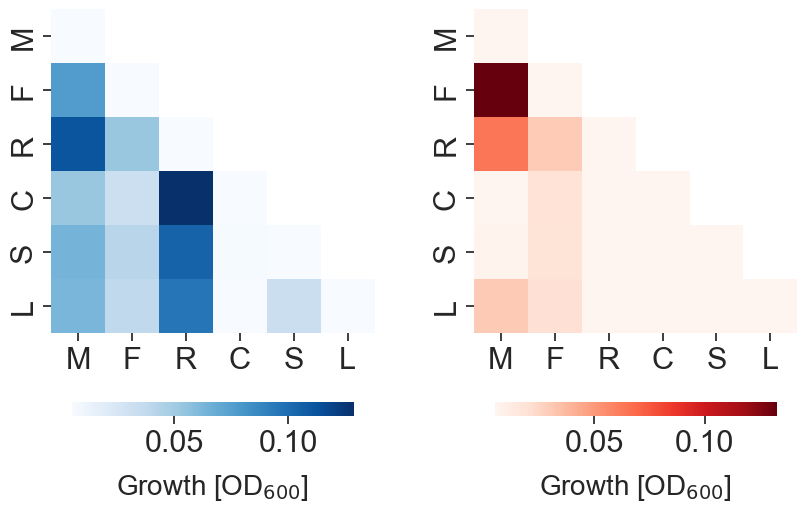

In [40]:
# Figure 1B
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

ax=axes[0]
data=(big_norm_df.query("Environment == 'Glut + Gly' " +
                  "and Aux1!= 'WT' and Species == 'Bs'")
     .pivot(columns='Aux1', index='Aux2', values='Norm_mean')
     .reindex(['M','F','R','C','S','L'])).astype(float)[['M','F','R','C','S','L']]

sns.heatmap(data, cmap='Blues', square=True, linewidths=0, ax=ax, 
             cbar_kws={"orientation": "horizontal", "pad": 0.15, "shrink": 0.8})

cbar = ax.collections[0].colorbar
cbar.set_label(r'Growth [OD$_{600}$]', fontsize=20, labelpad=10)

ax.set_ylabel('');ax.set_xlabel('')

ax=axes[1]
data=(big_norm_df.query("Environment == 'Glut + Gly' " +
                  "and Aux1!= 'WT' and Species == 'Ec'")
     .pivot(columns='Aux1', index='Aux2', values='Norm_mean')
     .reindex(['M','F','R','C','S','L'])).astype(float)[['M','F','R','C','S','L']]

sns.heatmap(data, cmap='Reds', square=True, linewidths=0, ax=ax,
            cbar_kws={"orientation": "horizontal", "pad": 0.15, "shrink": 0.8})
ax.set_ylabel('');ax.set_xlabel('')
cbar = ax.collections[0].colorbar
cbar.set_label(r'Growth [OD$_{600}$]', fontsize=20, labelpad=10)

plt.savefig('images/Fig1B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2); 



C:\Users\amich\AppData\Local\Temp\ipykernel_3628\1676668985.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Prototroph','M\n No AA','L\n No AA','M\nw/ Met','L\nw/ Leu','M+L\nCoculture'], rotation=0, fontsize=20)


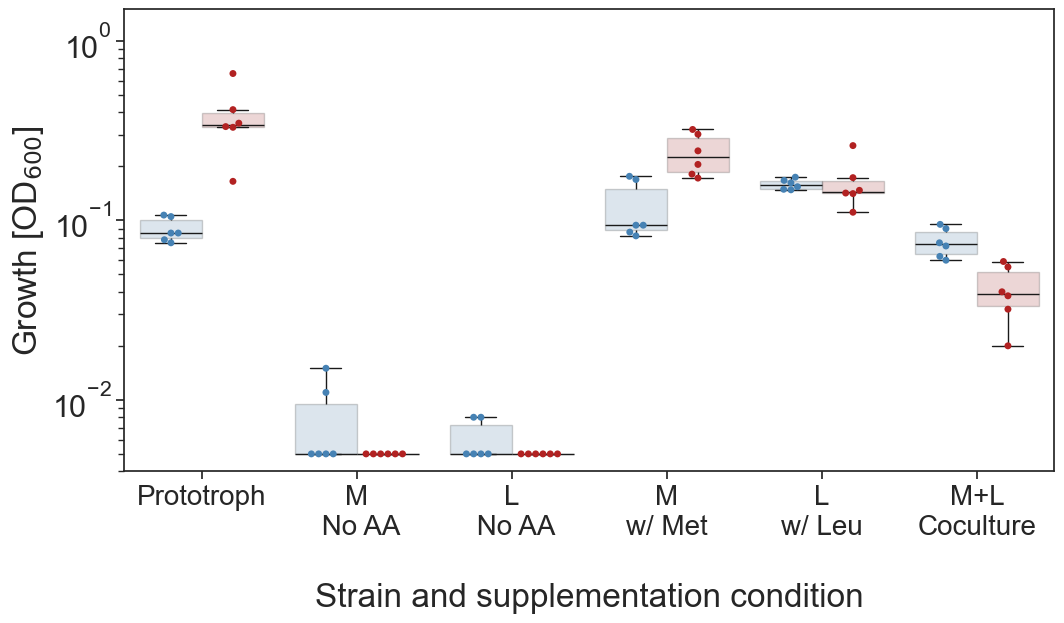

In [41]:
# Figure 1D
data=merged_df.query("Pair == 'WT+WT' or " + "Pair == 'M+Met' or " + 
                  "Pair == 'L+Leu' or " + "Pair == 'M+M' or " + "Pair == 'L+L' or " + 
                  "Pair == 'M+L'").query("Environment == 'Glut + Gly' ")

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sns.swarmplot(data=data, x='Pair', y='OD', ax=ax, s=5, 
              hue='Species', palette=['steelblue','firebrick'],
              hue_order=['Bs', 'Ec'], legend=False, dodge=True,
              order=['WT+WT','M+M','L+L','M+Met','L+Leu','M+L'])

sns.boxplot(data=data, x='Pair', y='OD', ax=ax, 
            hue='Species', palette=['steelblue','firebrick'], 
            hue_order=['Bs', 'Ec'], legend=False,
            fliersize=0, linecolor="k", boxprops={'alpha':0.2},
            order=['WT+WT','M+M','L+L','M+Met','L+Leu','M+L'])


ax.set_yscale('log') ; ax.set_ylim(0.004,1.5)
ax.set_ylabel(r'Growth [OD$_{600}$]') ; ax.set_xlabel('\nStrain and supplementation condition')
ax.tick_params(axis="x", rotation=90)

ax.set_xticklabels(['Prototroph','M\n No AA','L\n No AA','M\nw/ Met','L\nw/ Leu','M+L\nCoculture'], rotation=0, fontsize=20)

plt.savefig('images/Fig1D.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)


## Figure 2. Auxotrophic phenotypes are nutrient dependent

In [43]:
# Figure 2 data preparation
# Quanitfy evnrioments in which each KO is auxotrophic
data=big_norm_df.query("Aux1 == Aux2 and Aux1!= 'WT' and Species == 'Bs'")
data=data.pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()
data

wt_data=filtered_df.query("Aux1== 'WT' and Species == 'Bs'")
wt_data=wt_data.pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()
wt_data

cols = data.columns.difference(['Aux1', 'Species'])
data[cols] = data[cols].div(wt_data.loc[0, cols])

data['n_grows_01'] = (data[cols] > 0.1).sum(axis=1)/40*100
data['rank_01'] = data['n_grows_01'].rank(ascending=False, method='first')

data['n_grows_05'] = (data[cols] > 0.5).sum(axis=1)/40*100
data['rank_05'] = data['n_grows_05'].rank(ascending=False, method='first')

data['n_grows_1'] = (data[cols] > 1).sum(axis=1)/40*100
data['rank_1'] = data['n_grows_1'].rank(ascending=False, method='first')

bs_aux_growth=data.melt(id_vars=['Aux1','Species',], value_vars=['n_grows_01','n_grows_05', 'n_grows_1'])



data=big_norm_df.query("Aux1 == Aux2 and Aux1!= 'WT' and Species == 'Ec'")
data=data.pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()

wt_data=filtered_df.query("Aux1== 'WT' and Species == 'Ec'")
wt_data=wt_data.pivot(index=['Aux1', 'Species'], columns='Environment', values='Mean').reset_index()
wt_data

cols = data.columns.difference(['Aux1', 'Species'])
data[cols] = data[cols].div(wt_data.loc[0, cols])

data['n_grows_01'] = (data[cols] > 0.1).sum(axis=1)/40*100
data['rank_01'] = data['n_grows_01'].rank(ascending=False, method='first')

data['n_grows_05'] = (data[cols] > 0.5).sum(axis=1)/40*100
data['rank_05'] = data['n_grows_05'].rank(ascending=False, method='first')

data['n_grows_1'] = (data[cols] > 1).sum(axis=1)/40*100
data['rank_1'] = data['n_grows_1'].rank(ascending=False, method='first')

ec_aux_growth=data.melt(id_vars=['Aux1','Species',], value_vars=['n_grows_01','n_grows_05', 'n_grows_1'])

C:\Users\amich\AppData\Local\Temp\ipykernel_3628\2780802059.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bs_mono.set_xticklabels([bs_label_map[t.get_text()] for t in ax_bs_mono.get_xticklabels()], rotation=0, fontsize=20)
C:\Users\amich\AppData\Local\Temp\ipykernel_3628\2780802059.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_ec_mono.set_xticklabels([ec_label_map[t.get_text()] for t in ax_ec_mono.get_xticklabels()], rotation=0, fontsize=20)


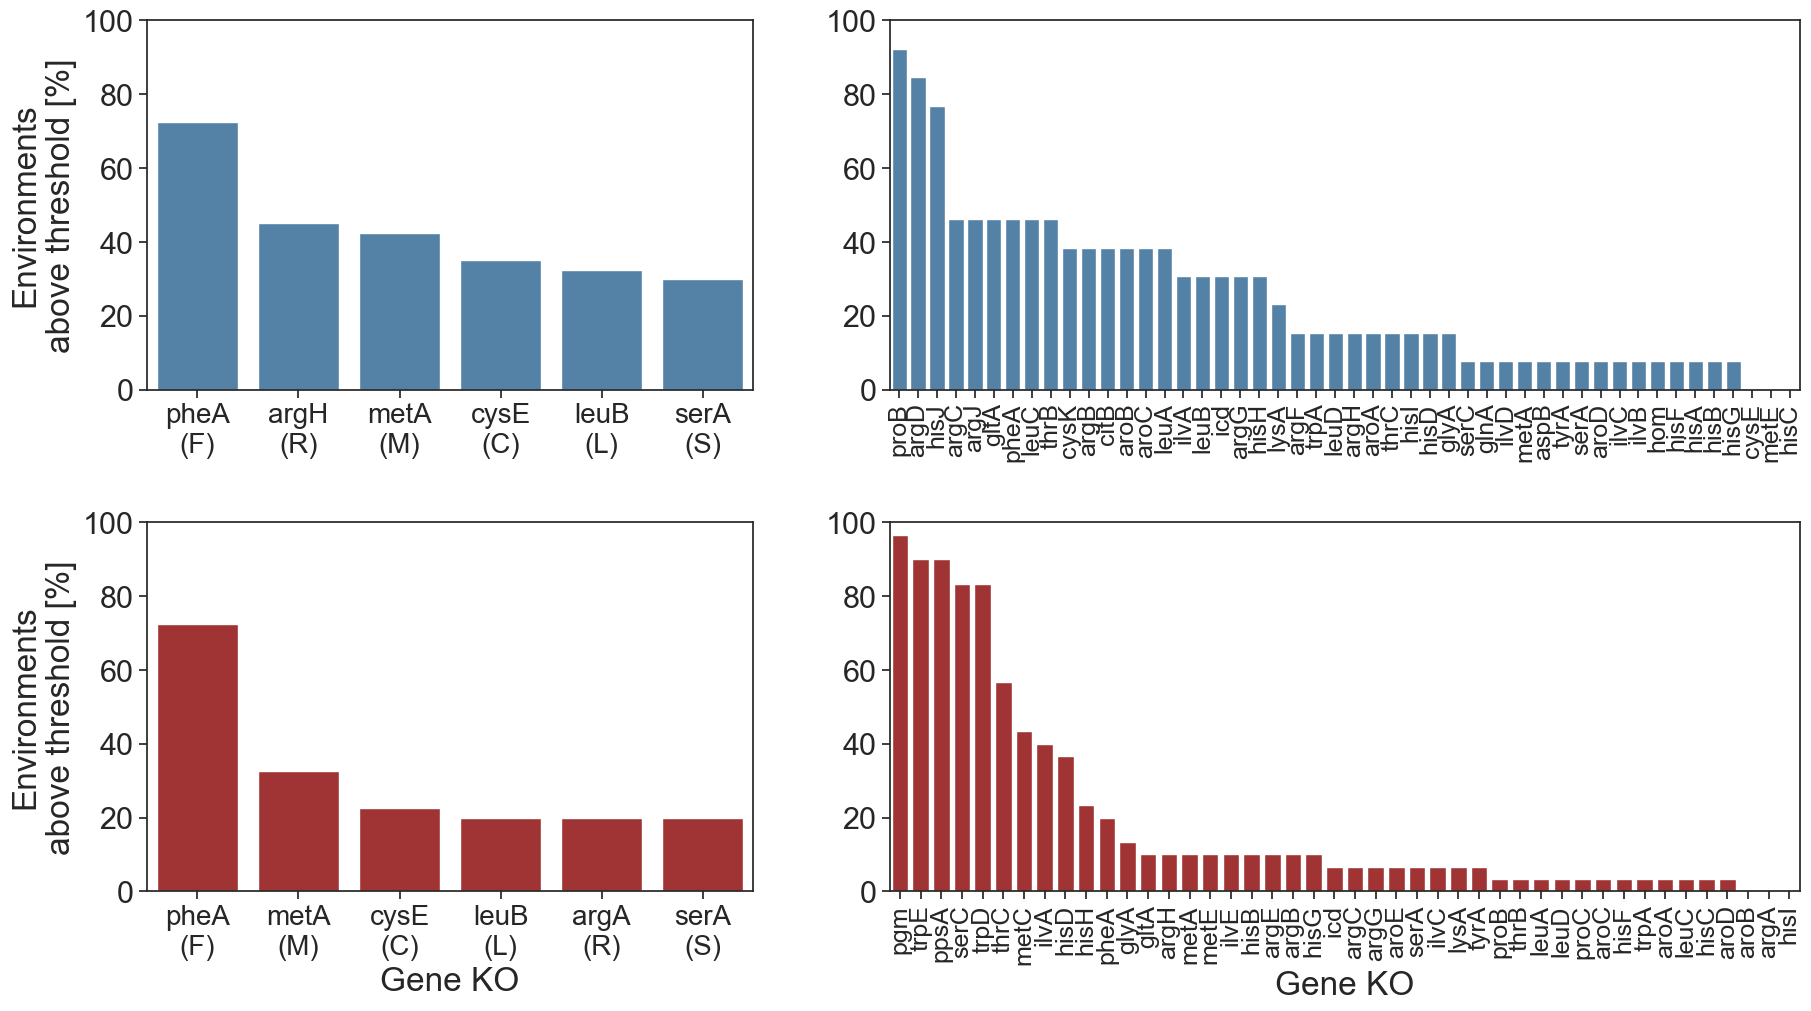

In [44]:
#Generate graphs

bs_label_map = {'M':'metA\n(M)', 'F':'pheA\n(F)', 'R':'argH\n(R)', 'C':'cysE\n(C)', 'S':'serA\n(S)', 'L':'leuB\n(L)'}
ec_label_map = {'M':'metA\n(M)', 'F':'pheA\n(F)', 'R':'argA\n(R)', 'C':'cysE\n(C)', 'S':'serA\n(S)', 'L':'leuB\n(L)'}


fig, axes = plt.subplots(2, 2, figsize=(18, 10),constrained_layout=True,
                         gridspec_kw={'width_ratios': [1, 1.5]},)
fig.set_constrained_layout_pads(wspace=0.08, hspace=0.1)

ax_bs_mono, ax_bs_koo = axes[0]
ax_ec_mono, ax_ec_tong = axes[1]


# Panel A: Bs mono auxotrophs
sns.barplot(data=bs_aux_growth.query("Environment == 'n_grows_01'"), x='Aux1', y='value', color='steelblue', ax=ax_bs_mono,
              order=list(bs_aux_growth.query("Environment == 'n_grows_01'").set_index('Aux1')['value']
                         .sort_values(ascending=False).index))

ax_bs_mono.set_ylabel('Environments\nabove threshold [%]') ; ax_bs_mono.set_xlabel('')
ax_bs_mono.set_ylim(0, 100)
ax_bs_mono.set_xticklabels([bs_label_map[t.get_text()] for t in ax_bs_mono.get_xticklabels()], rotation=0, fontsize=20)

# Panel B: Bs Koo knockouts
bs_koo = koo_df_bs_auxs.query("Casette == 'Erm'")

sns.barplot(data=bs_koo, x='gene', y='n_grows_01', color='steelblue',ax=ax_bs_koo,
            order=list(bs_koo.set_index('gene')['rank_01'].sort_values().index))

ax_bs_koo.tick_params(axis='x', rotation=90, labelsize=18)
ax_bs_koo.set_ylim(0,100)
ax_bs_koo.set_ylabel('') ; ax_bs_koo.set_xlabel('')

# Panel C: Ec mono auxotrophs
sns.barplot(data=ec_aux_growth.query("Environment == 'n_grows_01'"), x='Aux1', y='value', color='firebrick', ax=ax_ec_mono,
              order=list(ec_aux_growth.query("Environment == 'n_grows_01'")
                         .set_index('Aux1')['value'].sort_values(ascending=False).index))

ax_ec_mono.set_ylabel('Environments\nabove threshold [%]') ; ax_ec_mono.set_xlabel('Gene KO')
ax_ec_mono.set_ylim(0, 100)
ax_ec_mono.set_xticklabels([ec_label_map[t.get_text()] for t in ax_ec_mono.get_xticklabels()], rotation=0, fontsize=20)

# Panel D: Ec Tong knockouts
sns.barplot(data=tong_df_ec_auxs, x='gene', y='n_grows_01', color='firebrick',ax=ax_ec_tong,
            order=list(tong_df_ec_auxs.set_index('gene')['rank_01'].sort_values().index))

ax_ec_tong.tick_params(axis='x', rotation=90, labelsize=18)
ax_ec_tong.set_ylim(0,100)
ax_ec_tong.set_ylabel('') ; ax_ec_tong.set_xlabel('Gene KO')


plt.savefig('images/Fig2.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2);

## Figure 3. Crossfeeding varies widely across conditions

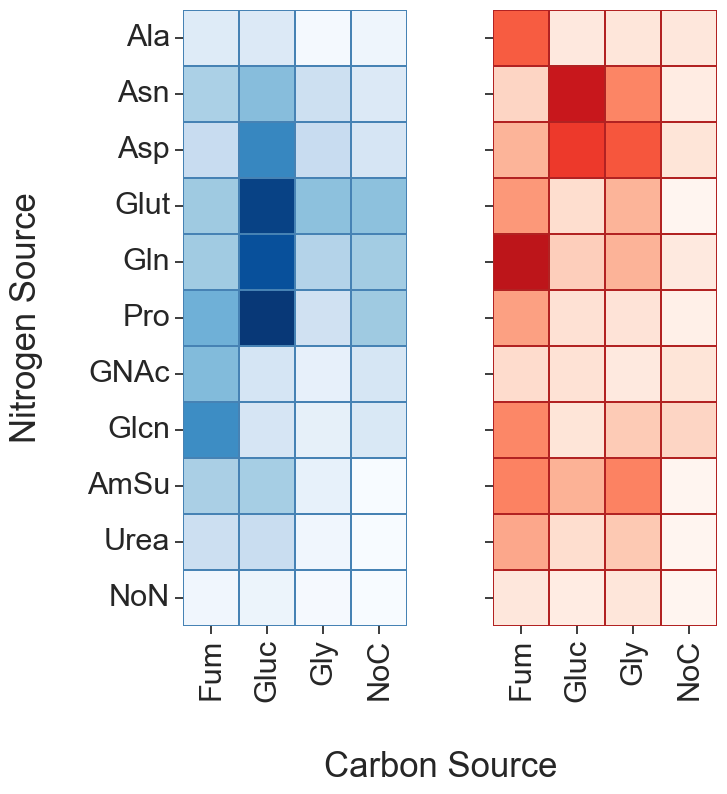

In [46]:
C_order = ['Fum', 'Gluc', 'Gly', 'NoC']                 
N_order = ['Ala',  'Asn', 'Asp', 'Glut', 'Gln', 'Pro',
           'GNAc', 'Glcn', 'AmSu', 'Urea', 'NoN',] 

fig, axes = plt.subplots(1,2, figsize=(8,8),gridspec_kw={'wspace': 0}, sharey=True)

# Bs in lower triangle - values
bs_envs =(comp_env_df
           .pivot(index='C', columns='N', values='Norm_mean_Bs')
           .reindex(index=C_order, columns=N_order)).T

sns.heatmap(bs_envs, cmap='Blues', linecolor='steelblue', ax=axes[0],
            square=True, linewidths=0.1, vmin=0.005, vmax=0.11,
            cbar=False)

ec_envs =(comp_env_df
           .pivot(index='C', columns='N', values='Norm_mean_Ec')
           .reindex(index=C_order, columns=N_order)).T

sns.heatmap(ec_envs, cmap='Reds', linecolor='firebrick', ax=axes[1],
            square=True, linewidths=0.1, vmin=0.005, vmax=0.11,
            cbar=False)

axes[0].set_ylabel("Nitrogen Source\n",  fontsize=25);axes[0].set_xlabel("")
axes[1].set_ylabel("");axes[1].set_xlabel("")
fig.suptitle("\nCarbon Source", y=0.001, fontsize=25)

plt.savefig('images/Fig3A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2);

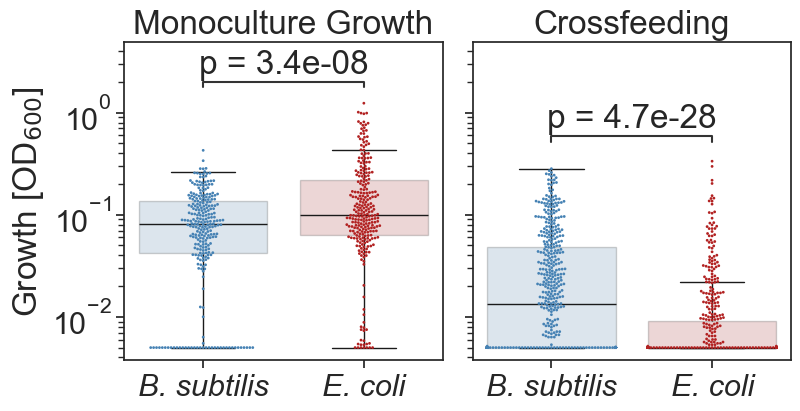

In [47]:
# Figure 4A
warnings.filterwarnings("ignore", message=".*points cannot be placed.*")


fig, axes = plt.subplots(1,2, figsize=(8,4), sharey=True, subplot_kw={'box_aspect': 1},
                         constrained_layout=True)

sns.swarmplot(data=aa_long.query("Aux1 != 'WT'"), x='Species', y='Mean', ax=axes[0], s=2, 
              hue='Species', palette=['steelblue','firebrick'])
sns.boxplot(data=aa_long.query("Aux1 != 'WT'"), x='Species', y='Mean', ax=axes[0],
            hue='Species', palette=['steelblue','firebrick'], 
            fliersize=0, linecolor="k", boxprops={'alpha':0.2},)
axes[0].set_yscale('log'); axes[0].set_ylabel('Growth [OD$_{600}$]')
axes[0].set_xlabel('');axes[0].set_title('Monoculture Growth')

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['B. subtilis', 'E. coli'], style='italic')

# Add statistical annotation
annot = Annotator(ax=axes[0], pairs=[("Bs", "Ec")],
                  data=aa_long.query("Aux1 != 'WT'"), x='Species', y='Mean')
annot.configure(test='Wilcoxon', text_format='full', pvalue_format_string='{:.1e}',
                loc='inside', verbose=0, show_test_name=False)
annot.apply_test()#(alternative='greater')
annot.annotate()

######################################################################################################

sns.swarmplot(data=df_long.query("Aux1 != Aux2"), x='Species', y='Norm_mean',ax=axes[1], s=2,
             hue='Species', palette=['steelblue','firebrick'])
sns.boxplot(data=df_long.query("Aux1 != Aux2"), x='Species', y='Norm_mean', ax=axes[1],
            hue='Species', palette=['steelblue','firebrick'], 
            fliersize=0, linecolor="k", boxprops={'alpha':0.2},)
axes[1].set_yscale('log')
axes[1].set_xlabel('');axes[1].set_title('Crossfeeding')

annot = Annotator(ax=axes[1], pairs=[("Bs", "Ec")],
                  data=df_long[df_long.Aux1!=df_long.Aux2], x='Species', y='Norm_mean')
annot.configure(test='Wilcoxon', text_format='full',pvalue_format_string='{:.1e}',
                loc='inside', verbose=0, show_test_name=False)
annot.apply_test()#(alternative='greater')
annot.annotate()

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['B. subtilis', 'E. coli'], style='italic')

plt.savefig('images/Fig3B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2);

In [48]:
#Calculate means

proto_bs_gmean=sp.stats.gmean(aa_long.query("Species == 'Bs' and Aux1 == 'WT'").Mean)
proto_ec_gmean=sp.stats.gmean(aa_long.query("Species == 'Ec'and Aux1 == 'WT'").Mean)

print(f"Monoculture geometric mean (Bs) = {proto_bs_gmean:.4g}")
print(f"Monoculture geometric mean (Ec) = {proto_ec_gmean:.4g}")
print(f"Monoculture fold-change (Ec/Bs) = {proto_ec_gmean/proto_bs_gmean:.3g}\n")

mono_bs_gmean=sp.stats.gmean(aa_long.query("Species == 'Bs'and Aux1 != 'WT'").Mean)
mono_ec_gmean=sp.stats.gmean(aa_long.query("Species == 'Ec'and Aux1 != 'WT'").Mean)
print(f"Monoculture geometric mean (Bs) = {mono_bs_gmean:.4g}")
print(f"Monoculture geometric mean (Ec) = {mono_ec_gmean:.4g}")
print(f"Monoculture fold-change (Ec/Bs) = {mono_ec_gmean/mono_bs_gmean:.3g}\n")

cf_bs_gmean=sp.stats.gmean(df_long.query("Aux1 != Aux2 and Species == 'Bs'").Norm_mean)
cf_ec_gmean=sp.stats.gmean(df_long.query("Aux1 != Aux2 and Species == 'Ec'").Norm_mean)

print(f"Crossfeeding geometric mean (Bs) = {cf_bs_gmean:.4g}")
print(f"Crossfeeding geometric mean (Ec) = {cf_ec_gmean:.4g}")
print(f"Crossfeeding fold-change (Bs/Ec) = {cf_bs_gmean/cf_ec_gmean:.3g}")

Monoculture geometric mean (Bs) = 0.08353
Monoculture geometric mean (Ec) = 0.1422
Monoculture fold-change (Ec/Bs) = 1.7

Monoculture geometric mean (Bs) = 0.06008
Monoculture geometric mean (Ec) = 0.1042
Monoculture fold-change (Ec/Bs) = 1.73

Crossfeeding geometric mean (Bs) = 0.01669
Crossfeeding geometric mean (Ec) = 0.007888
Crossfeeding fold-change (Bs/Ec) = 2.12


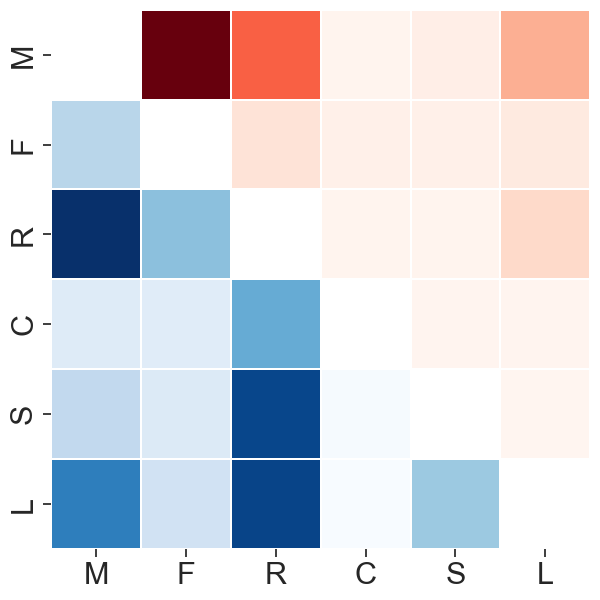

In [49]:
pair_order = ['M','F','R','C','S','L']
fig, ax = plt.subplots(1,1, figsize=(7,7),gridspec_kw={'wspace': 0.5})

# Bs in lower triangle - values
bs_lower =(cf_comp_pair_df
           .pivot(index='Aux1', columns='Aux2', values='Norm_mean_Bs')
           .reindex(index=pair_order, columns=pair_order).T)

# Ec in upper triangle - values
ec_upper = (cf_comp_pair_df
           .pivot(index='Aux1', columns='Aux2', values='Norm_mean_Ec')
           .reindex(index=pair_order, columns=pair_order))

# mask everything except lower triangle for Bs
mask_bs = np.triu(np.ones(bs_lower.shape, dtype=bool), k=0)
# mask everything except upper triangle for Ec
mask_ec = np.tril(np.ones(ec_upper.shape, dtype=bool), k=0)

# plot blue lower triangle
sns.heatmap(bs_lower, mask=mask_bs, cmap='Blues', 
            square=True, linewidths=0.1, cbar=False, ax=ax)

# plot red upper triangle
sns.heatmap(ec_upper, mask=mask_ec, cmap='Reds',  
            square=True, linewidths=0.1, cbar=False, ax=ax)

ax.set_ylabel('');ax.set_xlabel('')

plt.savefig('images/Fig3C.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2);

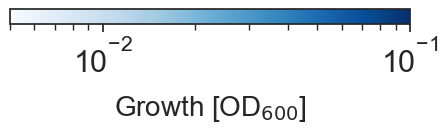

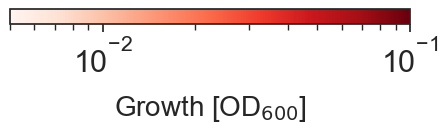

In [50]:
# Figure 3 colorbars
plt.figure(figsize=(5, 0.5))
img = plt.imshow(np.array([[0.005, 0.3]]), cmap="Blues", norm=LogNorm(vmin=0.005, vmax=0.1))
plt.gca().set_visible(False)

cax = plt.axes([0.1, 0.35, 0.8, 0.3])
cb = plt.colorbar(img, cax=cax, orientation="horizontal")
cb.set_label(r'Growth [OD$_{600}$]', fontsize=20, labelpad=10)
plt.savefig('images/Fig3_blue_colorbar.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 


plt.figure(figsize=(5, 0.5))
img = plt.imshow(np.array([[0.005, 0.6]]), cmap="Reds", norm=LogNorm(vmin=0.005, vmax=0.1))
plt.gca().set_visible(False)

cax = plt.axes([0.1, 0.35, 0.8, 0.3])
cb = plt.colorbar(img, cax=cax, orientation="horizontal")
cb.set_label(r'Growth [OD$_{600}$]', fontsize=20, labelpad=10)

plt.savefig('images/Fig3_red_colorbar.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 


## Figure 4. Crossfeeding yield is correlated with, but rarely surpasses, prototroph growth

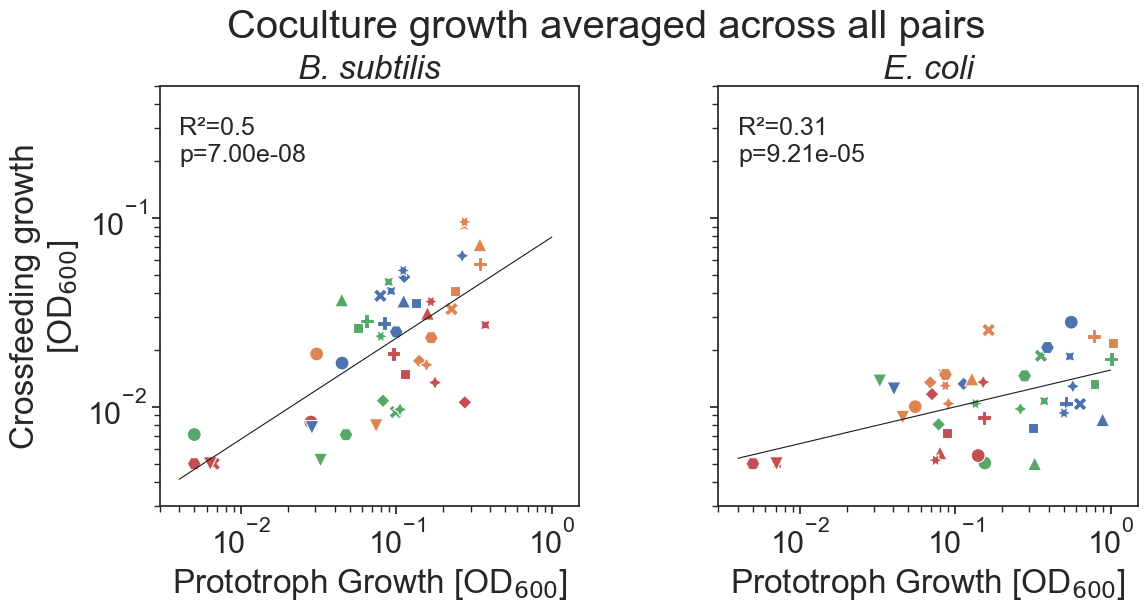

In [52]:
# Figure 4B
mean_by_env_df=(filtered_df.query("Aux1 !='WT'")
                .groupby(['Environment','C','N','Species'])
                .mean(numeric_only=True).reset_index())

fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True, subplot_kw={'box_aspect': 1},
                         constrained_layout=True)

# Iterate over all axes and set the box aspect
for ax in axes:
    ax.set_box_aspect(1) # Sets the box aspect to be 1:1 (square)

title_dic={'Bs':'B. subtilis','Ec':'E. coli'}

for x, s in enumerate(['Bs','Ec']):
    data = mean_by_env_df.query("Species == @s")
    ax=axes[x]
    # 1) scatter with hue=‘C’ and style=‘N’
    sns.scatterplot(x="WT_mean", y="Norm_mean", data=data, 
                    hue="C", style="N", legend=False,
                    ax=ax, s=100, zorder=1)
      
    x_log = np.log10(data["WT_mean"])
    y_log = np.log10(data["Norm_mean"])
    
    # Regression
    r = sp.stats.linregress(x_log, y_log)
    
    x_vals = np.logspace(np.log10(0.004), np.log10(1), 10)
    y_vals = 10**(r.slope * np.log10(x_vals) + r.intercept)
    ax.plot(x_vals, y_vals, color='k', lw=0.8)
    # ax.plot(x_vals, x_vals, color='k', lw=0.8)

    ax.text(0.004, 0.2, ("R²="+str(((r.rvalue)**2).round(2)) +"\n"
                         + f"p={r.pvalue:.2e}"), fontsize=18)

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(0.003, 1.5); ax.set_ylim(0.003, 0.5)
    ax.set_xlabel("Prototroph Growth [OD$_{600}$]"); ax.set_ylabel("Crossfeeding growth\n[OD$_{600}$]")
    ax.set_title(title_dic[s], style='italic')
fig.suptitle("Coculture growth averaged across all pairs")

    
plt.savefig('images/Fig4A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)


Pairs better than WT = 33
747
Pairs better than WT = 1
659
 Total pairs better than WT = 0.021739130434782608


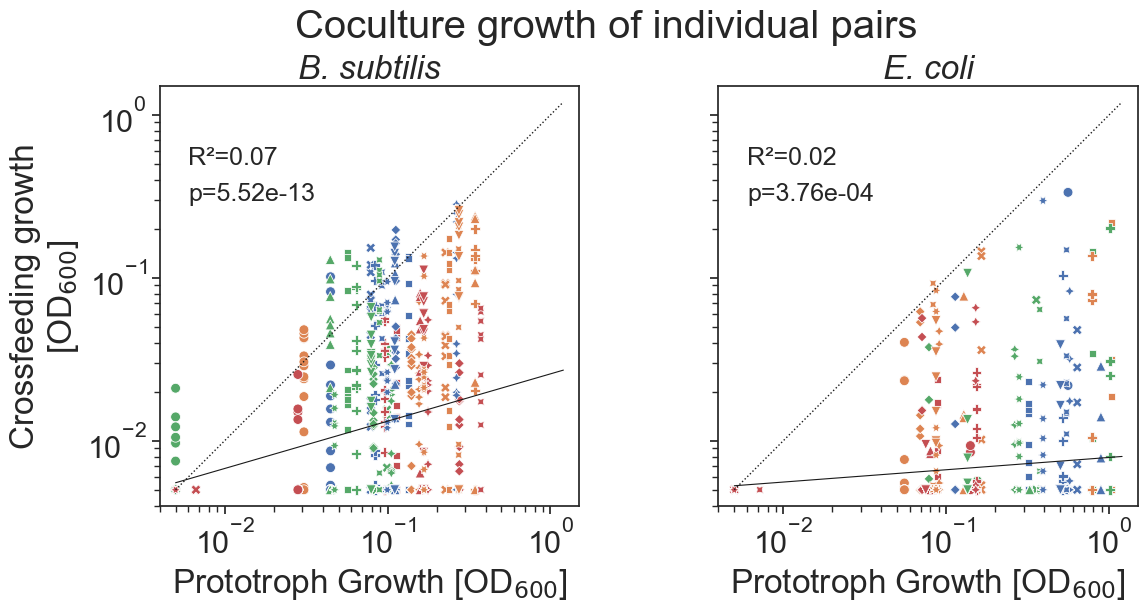

In [53]:
# Figure 4C
fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True, subplot_kw={'box_aspect': 1},
                         constrained_layout=True)

for ax in axes:
    ax.set_box_aspect(1) # Sets the box aspect to be 1:1 (square)
    
title_dic={0:'B. subtilis',1:'E. coli'}

for x, data in enumerate([bs_df,ec_df]):
    ax = axes[x]
    data=data.query("Aux1 != 'WT' and N != 'NoN'")
    # 1) scatter with hue=‘C’ and style=‘N’
    sns.scatterplot(x="WT_mean", y="Norm_mean",  data=data,
                    hue="C", style="N", ax=ax, legend=False, s=50, zorder=1)
    
   
    # Apply log10
    x_log = np.log10(data["WT_mean"])
    y_log = np.log10(data["Norm_mean"])
    
    # Regression
    r = sp.stats.linregress(x_log, y_log)
    ax.text(0.006, 0.5, "R²="+str(((r.rvalue)**2).round(2)), fontsize=18)
    ax.text(0.006, 0.3, f"p={r.pvalue:.2e}", fontsize=18)
    
    x_vals = np.logspace(np.log10(0.005), np.log10(1.2), 10)
    y_vals = 10**(r.slope * np.log10(x_vals) + r.intercept)
    ax.plot(x_vals, y_vals, color='k', lw=0.8)
    ax.plot(x_vals, x_vals, color='k', lw=1, linestyle='dotted')
    
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Prototroph Growth [OD$_{600}$]"); ax.set_ylabel("Crossfeeding growth\n[OD$_{600}$]")
    ax.set_xlim(0.004, 1.5); ax.set_ylim(0.004, 1.5)
    ax.set_title(title_dic[x], style='italic')

    handles, labels = axes[0].get_legend_handles_labels()
    print("Pairs better than WT = " + str(len((data[((data.Norm_mean-data.Norm_sem)>data.WT_mean)]))))
    print(str(len((data))))
print(" Total pairs better than WT = " + str(len((filtered_df[((filtered_df.Norm_mean-filtered_df.Norm_sem)>
                                                                filtered_df.WT_mean)]))/len(filtered_df)))

fig.suptitle("Coculture growth of individual pairs")

plt.savefig('images/Fig4B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

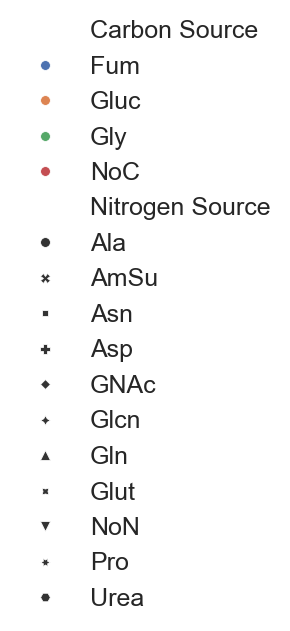

In [54]:
#Depends on variables from the previous cell, so run imidiatly after 

for x, data in enumerate([bs_df,ec_df]):
    ax = axes[x]
    data=data.query("Aux1 != 'WT'")
    # 1) scatter with hue=‘C’ and style=‘N’
    sns.scatterplot(x="WT_mean", y="Norm_mean",  data=data,
                    hue="C", style="N", ax=ax, s=50)
    
    handles, labels = ax.get_legend_handles_labels()

# --- legend-only figure (robust across backends) ---
fig_leg, ax_leg = plt.subplots(figsize=(3, 7))
ax_leg.axis("off")

ax_leg.legend(handles, ['Carbon Source']+labels[1:5]+['Nitrogen Source']+labels[6:],
              loc="center", frameon=False, fontsize=18, ncol=1)

fig_leg.tight_layout()
plt.savefig('images/Fig4_legend.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

## Figure 5. Auxotrophy is a better predictor than environment for crossfeeding across species

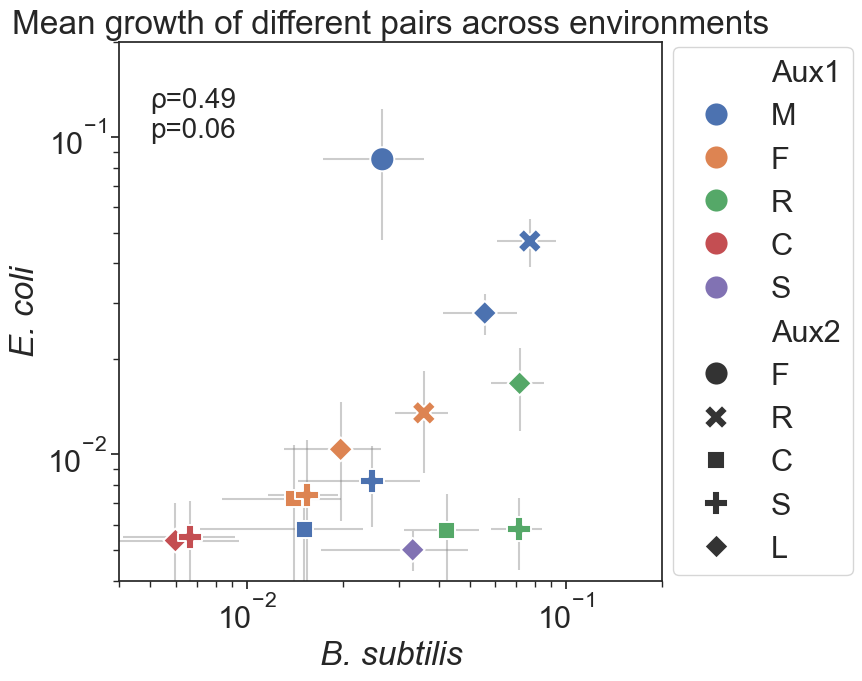

In [56]:
# Figure 5A
fig, ax = plt.subplots(1,1, figsize=(7,7),gridspec_kw={'wspace': 0.5})

data=cf_comp_pair_df[cf_comp_pair_df.Aux1!=cf_comp_pair_df.Aux2]
sns.scatterplot(data=data,
                x='Norm_mean_Bs', y='Norm_mean_Ec',
                hue="Aux1", hue_order=['M', 'F', 'R', 'C', 'S'],
                style="Aux2", style_order=['F', 'R', 'C', 'S', 'L'],
                ax=ax, legend="full", s=300, zorder=1)

# 2) overlay errorbars
for _, row in data.iterrows():
    ax.errorbar(row["Norm_mean_Bs"], row["Norm_mean_Ec"],
                xerr=row["Norm_sem_Bs"], yerr=row["Norm_sem_Ec"],
                fmt="none", ecolor="gray", alpha=0.4, zorder=0)

# ax.plot(np.arange(0.001,0.3,0.002), np.arange(0.001,0.3,0.002), color='k', lw=0.8)

# r, pval = sp.stats.linregress(data["Mean_Bs"], data["Mean_Ec"])[2:4]
# ax.text(0.001, 0.085, "R²="+str((r**2).round(2)), fontsize=20)
# ax.text(0.001, 0.06, f"p={pval.round(2)}", fontsize=20)
rho, rho_pval = sp.stats.spearmanr(data["Norm_mean_Bs"], data["Norm_mean_Ec"])
ax.text(0.005, 0.1, (f"ρ={rho.round(2)}"+"\n"+
                       f"p={rho_pval.round(2)}"), fontsize=20)



ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.004, 0.2); ax.set_ylim(0.004, 0.2)
ax.set_xlabel("B. subtilis", style='italic'); ax.set_ylabel("E. coli", style='italic')
ax.set_title('Mean growth of different pairs across environments')
ax.legend( loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0,)
plt.savefig('images/Fig5A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

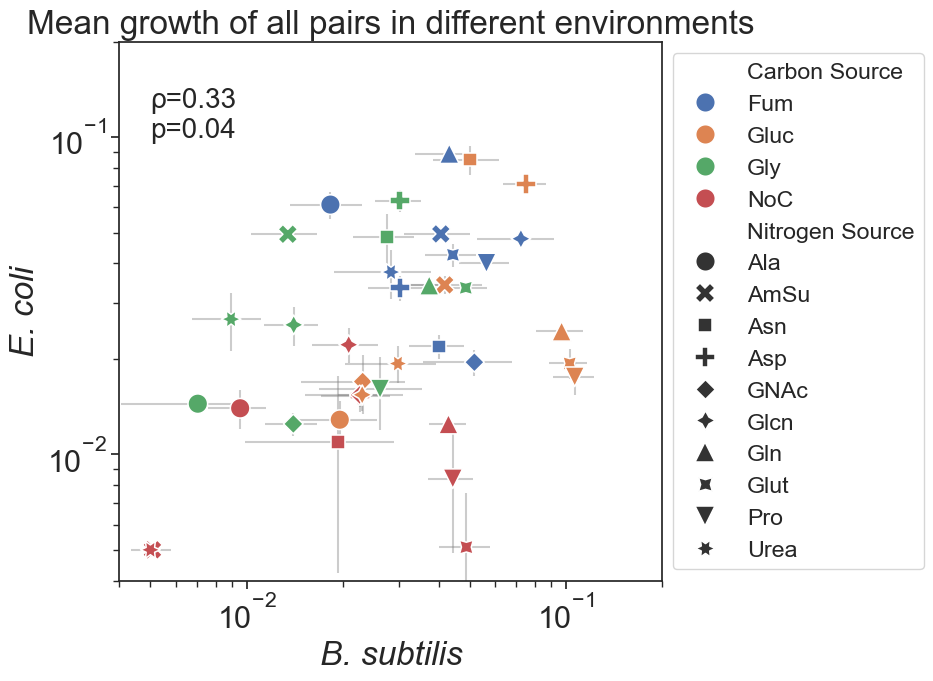

In [57]:
# Figure 5B
fig, ax = plt.subplots(1,1, figsize=(7,7),gridspec_kw={'wspace': 0.5})

data=comp_env_df.query(#"Environment != 'AmSu + NoC' and " +  
                       # "Environment != 'Urea + NoC' and " +  
                       "N != 'NoN'") # removes 3 environments without any carbon and no nitrogen environments
sns.scatterplot(data=data,
                x='Norm_mean_Bs', y='Norm_mean_Ec',
                hue="C", style="N", ax=ax, legend="full", s=200, zorder=1)

# 2) overlay errorbars
for _, row in data.iterrows():
    ax.errorbar(row["Norm_mean_Bs"], row["Norm_mean_Ec"],
                xerr=row["Norm_sem_Bs"], yerr=row["Norm_sem_Ec"],
                fmt="none", ecolor="gray", alpha=0.4, zorder=0)

# ax.plot(np.arange(0.001,0.3,0.002), np.arange(0.001,0.3,0.002), color='k', lw=0.8)

# r, r_pval = sp.stats.linregress(data["Mean_Bs"], data["Mean_Ec"])[2:4]

rho, rho_pval = sp.stats.spearmanr(data["Mean_Bs"], data["Mean_Ec"])
ax.text(0.005, 0.1, (f"ρ={rho.round(2)}"+"\n"+
                       f"p={rho_pval.round(2)}"), fontsize=20)



ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.004, 0.2); ax.set_ylim(0.004, 0.2)
ax.set_xlabel("B. subtilis", style='italic'); ax.set_ylabel("E. coli", style='italic')
ax.set_title('Mean growth of all pairs in different environments')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Carbon Source']+labels[1:5]+['Nitrogen Source']+labels[6:],
          loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0, fontsize=16.7)

plt.savefig('images/Fig5B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

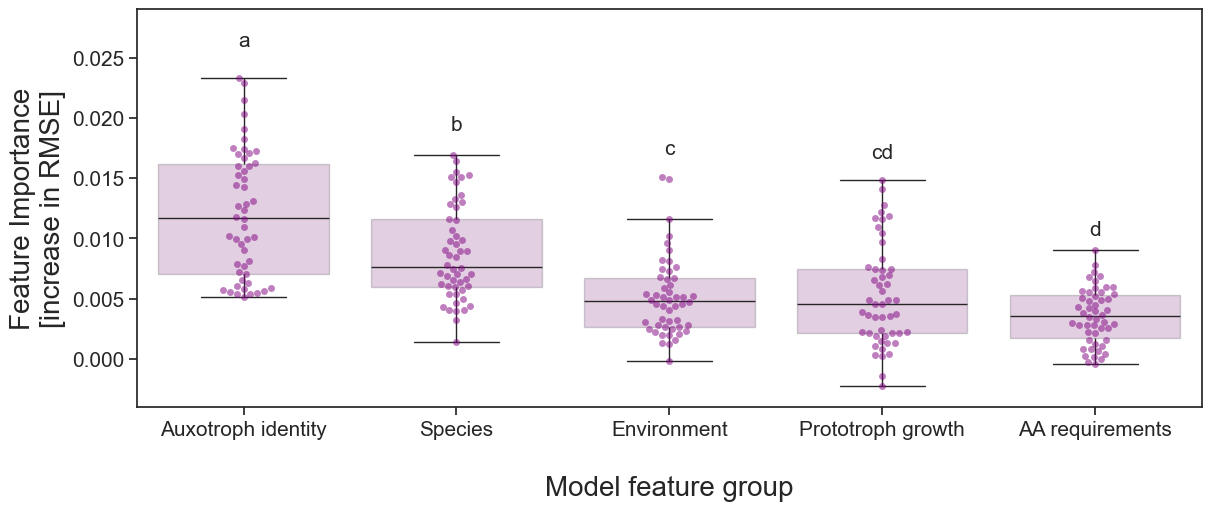

In [58]:
# Figure 5C
fig, ax = plt.subplots(1, 1, figsize=(12, 5), constrained_layout=True)

sns.swarmplot(data=block_cv_folds_fast, x="block", y="rmse_increase",
              color="purple", ax=ax, s=5, alpha=0.5,
              order=list(cld.sort_values('Letters').index))

sns.boxplot(data=block_cv_folds_fast, x="block", y="rmse_increase", ax=ax,
            color="purple", fliersize=0, boxprops={'alpha':0.2},
            order=list(cld.sort_values('Letters').index))

# ax.set_yscale('log')
ax.set_ylim(-0.004,0.029)
ax.set_ylabel('Feature Importance\n[increase in RMSE]', size=20)
ax.set_xlabel('\nModel feature group', size=20)
ax.tick_params(axis="x", rotation=0, labelsize=15)
ax.tick_params(axis="y", rotation=0, labelsize=15)

# Add letters
ymax = block_cv_folds_fast.groupby("block")["rmse_increase"].max()
for i, g in enumerate(list(cld.sort_values('Letters').index)):
    # place slightly above max (multiplicative offset works well on log scale)
    y = ymax[g] * 1.1
    ax.text(i, y, cld.to_dict()['Letters'][g], ha="center", va="bottom", fontsize=15)

plt.savefig('images/Fig5C.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()


## Supplementary figures

### Figure S1. Nutrient dependent phenotypes of *B. subtilis* KOs with ErmR cassette

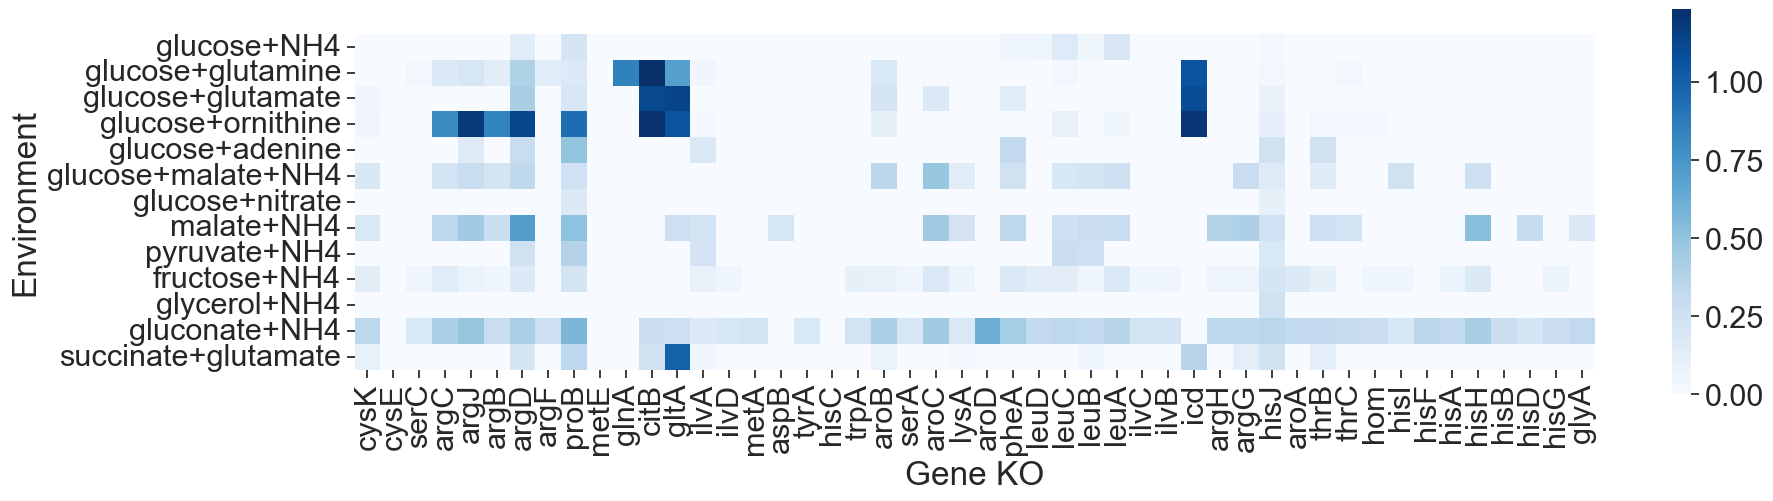

In [61]:
# Figure S1A
data=koo_df_bs_auxs.query("Casette == 'Erm'")[koo_df_bs_auxs.columns[1:15]]
data=data.set_index('gene').T
data.index = data.index.str.replace('_', '+', regex=False)


fig, ax = plt.subplots(1, 1, figsize=(20,5))
sns.heatmap(data=data, yticklabels=1, xticklabels=1, cmap='Blues', square=True, ax=ax)
ax.set_ylabel('Environment') ; ax.set_xlabel('Gene KO');

plt.savefig('images/FigS1A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

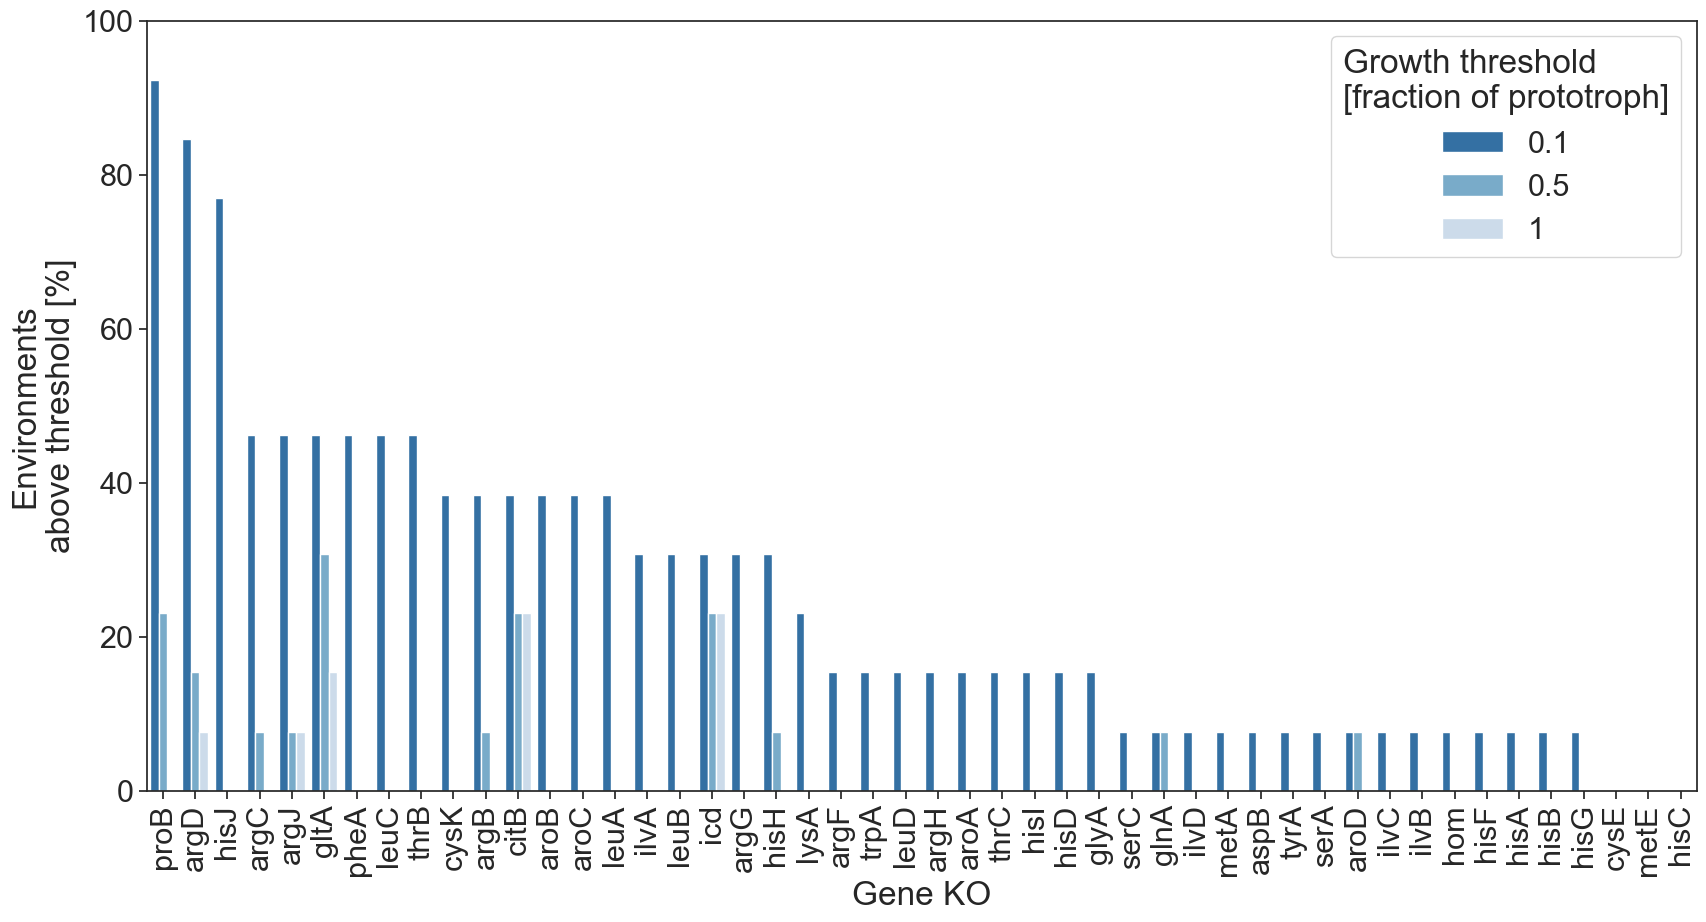

In [62]:
# Figure S1B
aux_melt=koo_df_bs_auxs.melt(id_vars=['gene','Casette','rank_01',], value_vars=['n_grows_01', 'n_grows_05', 'n_grows_1'])


fig, ax = plt.subplots(1, 1, figsize=(20, 10))

g=sns.barplot(data=aux_melt.query("Casette == 'Erm'"), x='gene', y='value',  
            hue= 'variable', palette='Blues_r',
           order=list(aux_melt.query("Casette == 'Erm'").set_index('gene')['rank_01'].sort_values().index))

plt.xticks(rotation=90)
ax.set_ylim(0,100)
ax.set_ylabel('Environments\nabove threshold [%]') ; ax.set_xlabel('Gene KO')
# ax.tick_params(axis="x", rotation=90)
plt.xticks(rotation=90);
# get legend entries created by seaborn
handles, labels = ax.get_legend_handles_labels()

# keep only the first 4 
handles = handles[:3]
labels = labels[:3]

# rename them manually
new_labels = ["0.1", "0.5", "1"]   

ax.legend(handles, new_labels, title="Growth threshold\n[fraction of prototroph]");
plt.savefig('images/FigS1B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

### Figure S2. Nutrient dependent phenotypes of *B. subtilis* KOs with KanR cassette

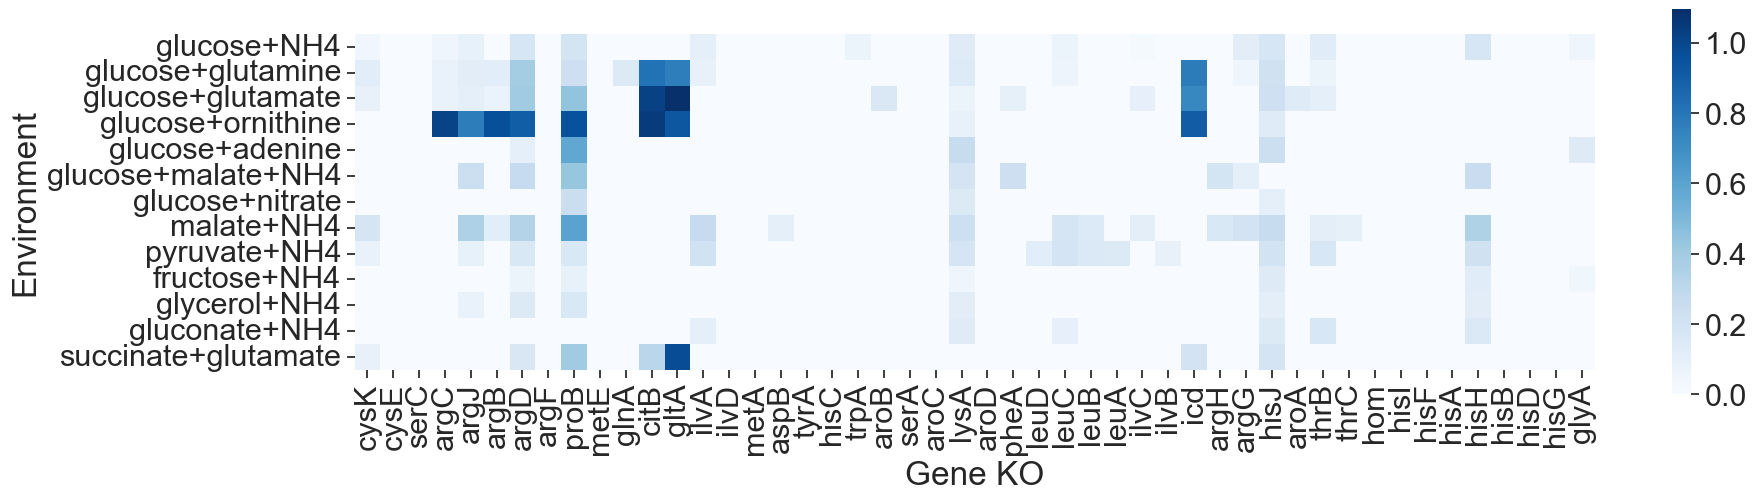

In [64]:
# Figure S2A
data=koo_df_bs_auxs.query("Casette == 'Kan'")[koo_df_bs_auxs.columns[1:15]]
data=data.set_index('gene').T
data.index = data.index.str.replace('_', '+', regex=False)


fig, ax = plt.subplots(1, 1, figsize=(20,5))
sns.heatmap(data=data, yticklabels=1, xticklabels=1, cmap='Blues', square=True, ax=ax)
ax.set_ylabel('Environment') ; ax.set_xlabel('Gene KO');

plt.savefig('images/FigS2A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

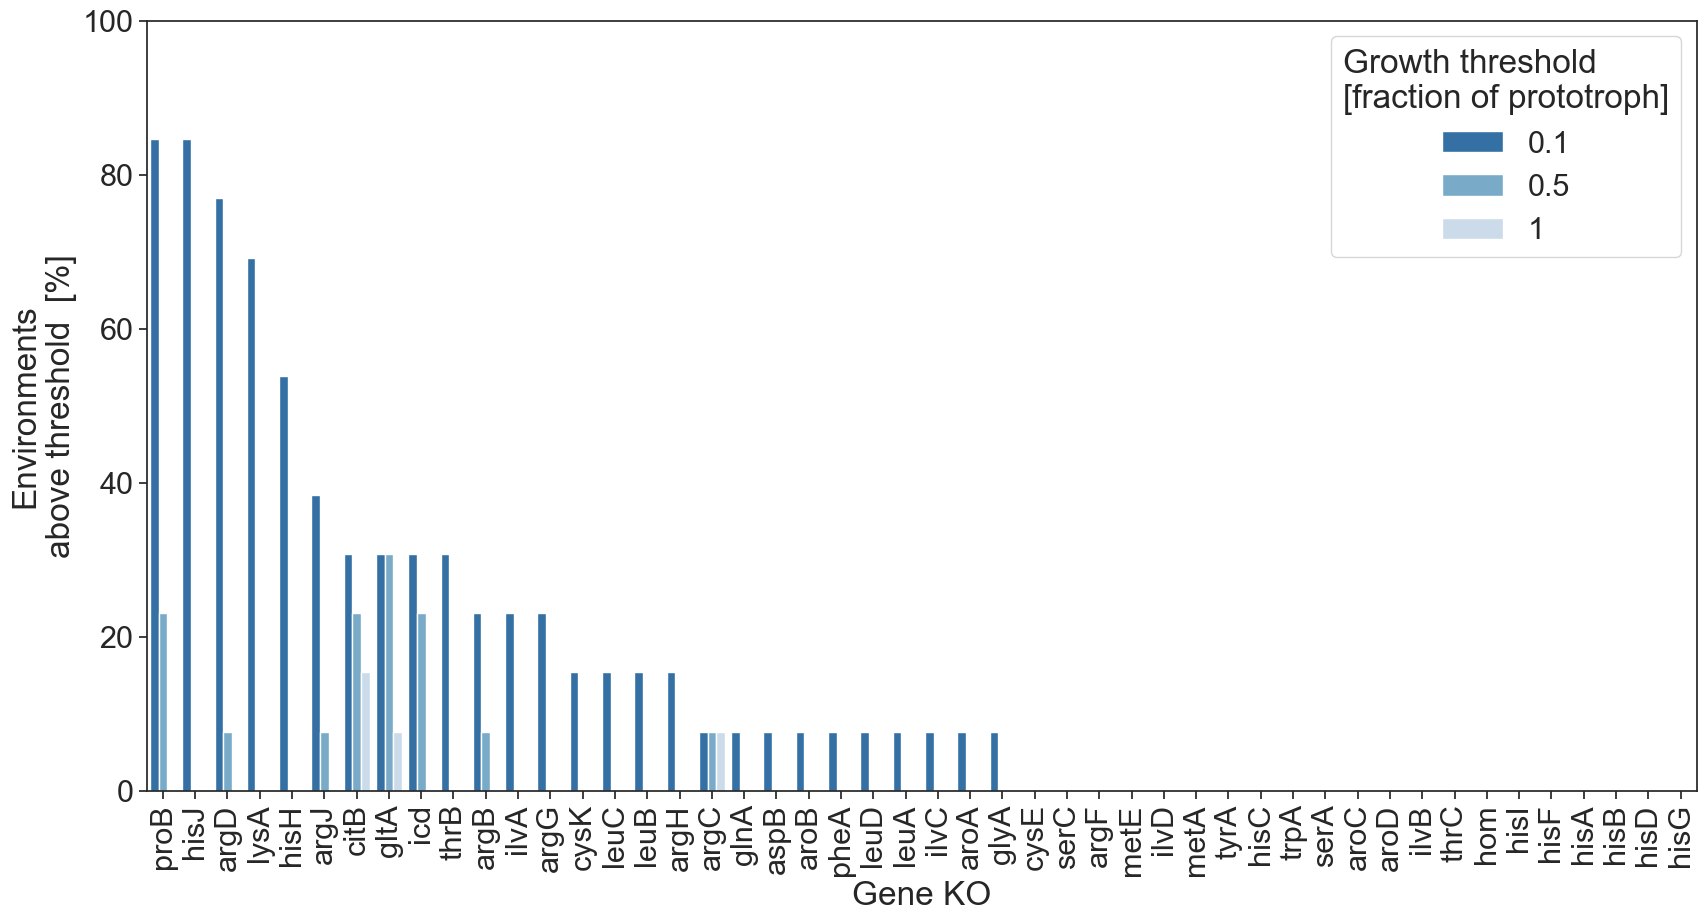

In [65]:
# Figure S2B
aux_melt=koo_df_bs_auxs.melt(id_vars=['gene','Casette','rank_01',], value_vars=['n_grows_01', 'n_grows_05', 'n_grows_1'])


fig, ax = plt.subplots(1, 1, figsize=(20, 10))

g=sns.barplot(data=aux_melt.query("Casette == 'Kan'"), x='gene', y='value',  
            hue= 'variable', palette='Blues_r',
           order=list(aux_melt.query("Casette == 'Kan'").set_index('gene')['rank_01'].sort_values().index))

plt.xticks(rotation=90)
ax.set_ylim(0,100)
ax.set_ylabel('Environments\nabove threshold  [%]') ; ax.set_xlabel('Gene KO')
# ax.tick_params(axis="x", rotation=90)
plt.xticks(rotation=90);
# get legend entries created by seaborn
handles, labels = ax.get_legend_handles_labels()

# keep only the first 4 
handles = handles[:3]
labels = labels[:3]

# rename them manually
new_labels = ["0.1", "0.5", "1"]   

ax.legend(handles, new_labels, title="Growth threshold\n[fraction of prototroph]");
plt.savefig('images/FigS2B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

### Figure S3. Nutrient dependent phenotypes of *E. coli* KOs

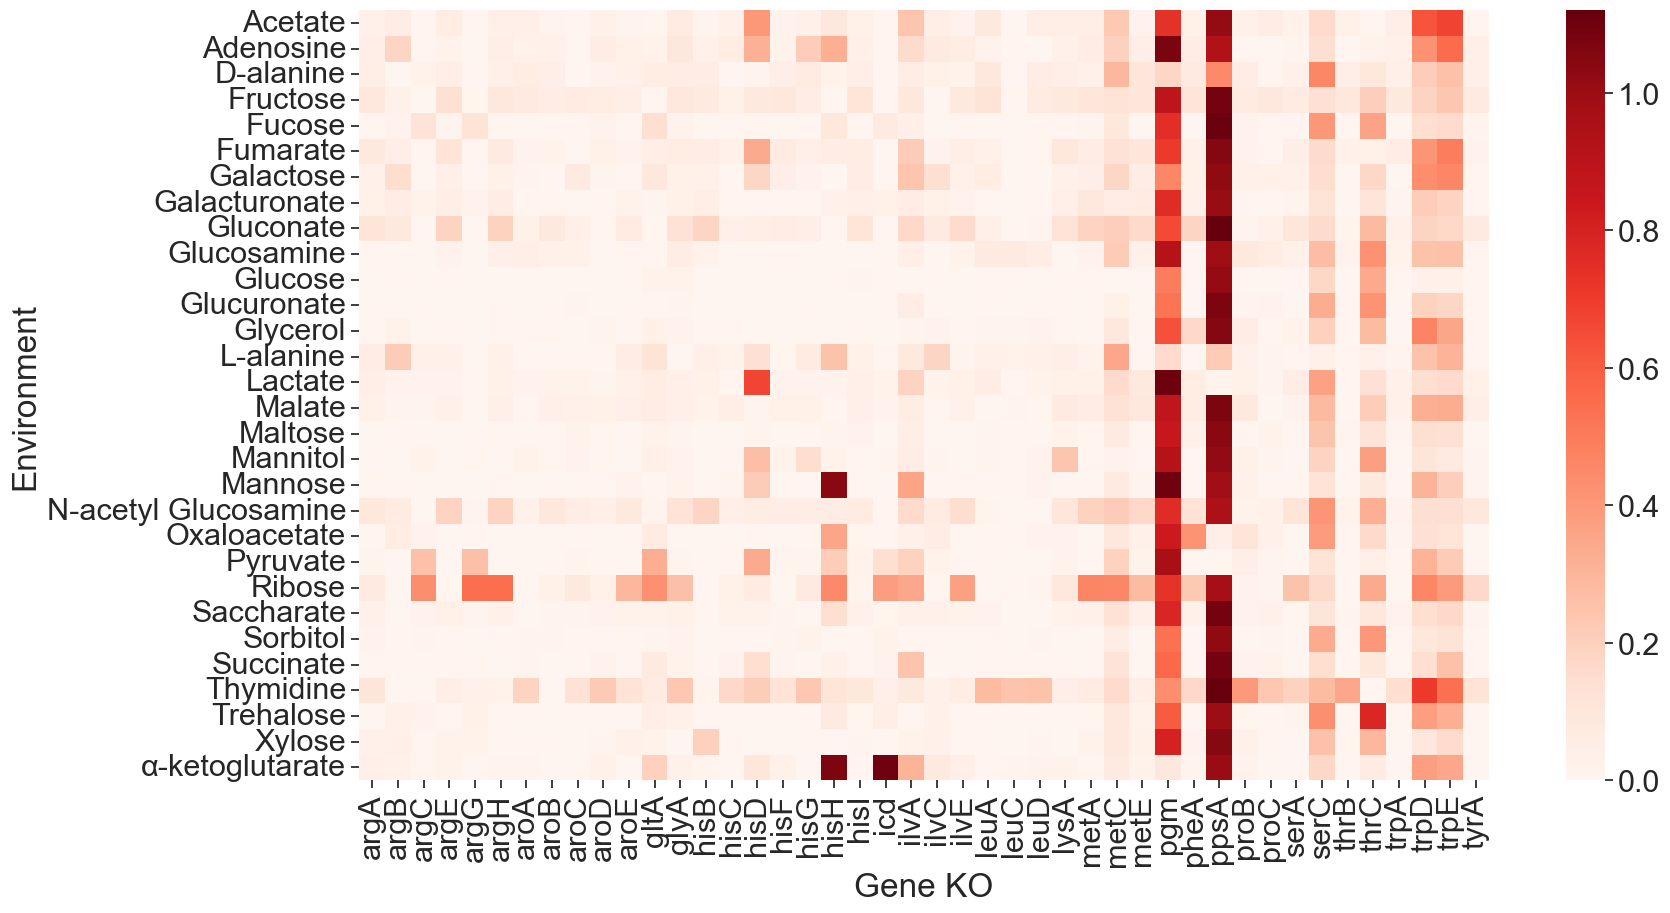

In [67]:
# Figure S3A
data=ec_auxs[ec_auxs.columns[1:]].sort_values('gene')
data=data.set_index('gene').drop('kdsC').T
data=data.loc[sorted(data.index)]

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
sns.heatmap(data=data, yticklabels=1, xticklabels=1, cmap='Reds', square=True, ax=ax)
ax.set_ylabel('Environment') ; ax.set_xlabel('Gene KO');
plt.savefig('images/FigS3A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

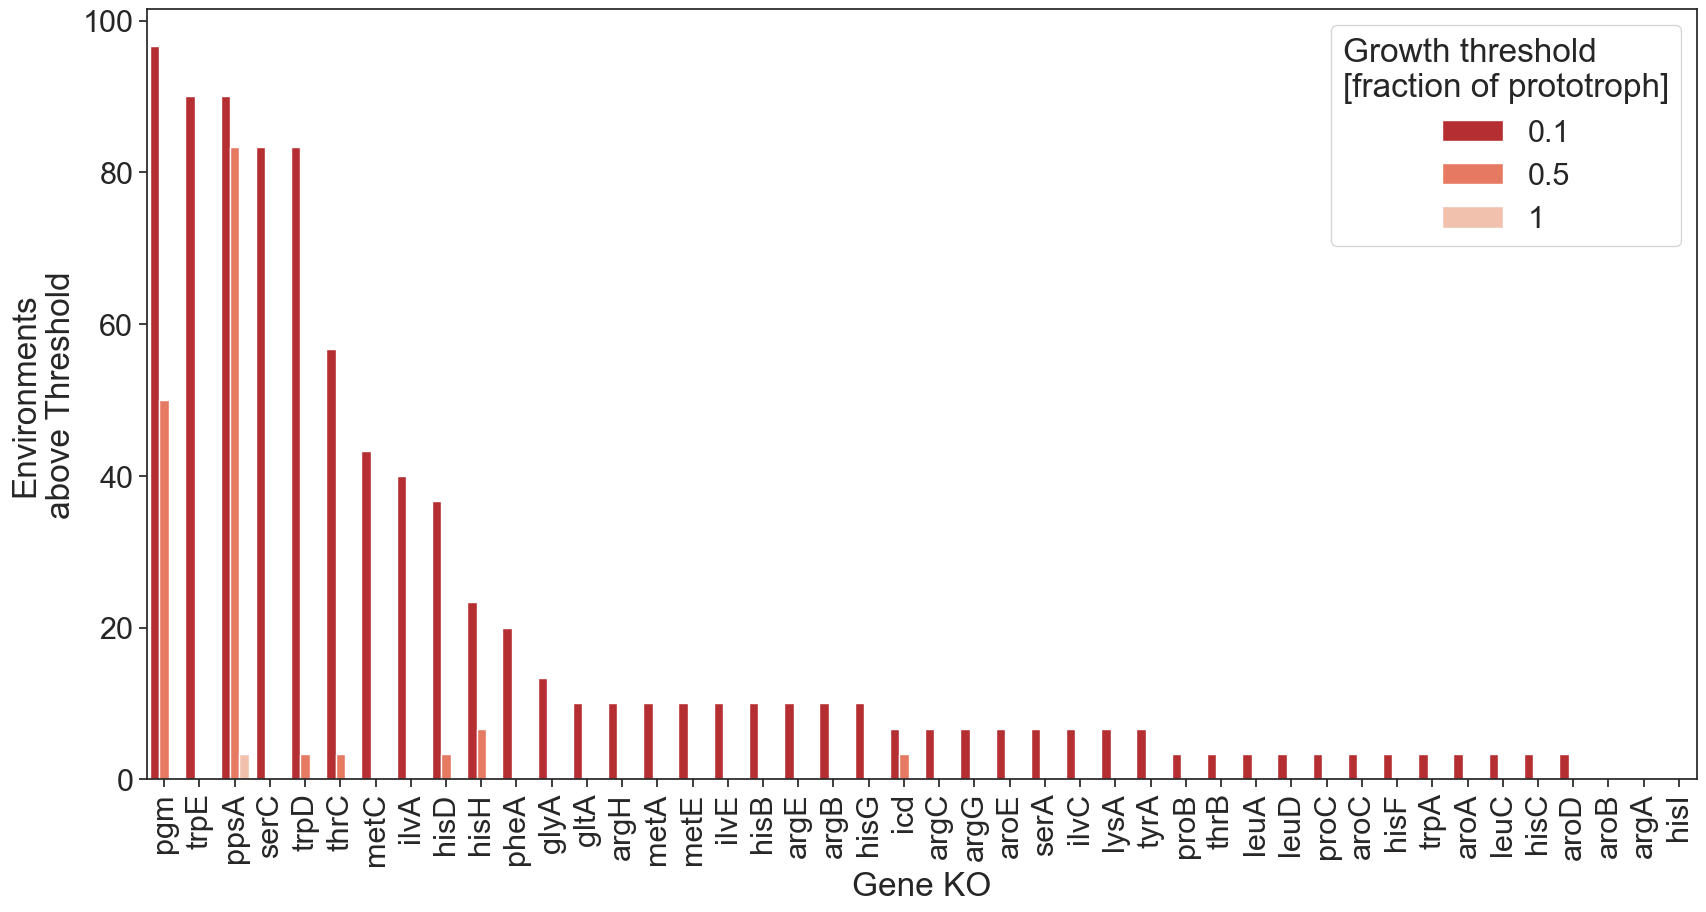

In [68]:
# Figure S3B
aux_melt=tong_df_ec_auxs.melt(id_vars=['gene','rank_01',], value_vars=['n_grows_01', 'n_grows_05', 'n_grows_1'])


fig, ax = plt.subplots(1, 1, figsize=(20, 10))
g=sns.barplot(data=aux_melt, x='gene', y='value', hue= 'variable', palette='Reds_r',
              order=list(tong_df_ec_auxs.set_index('gene')['rank_01'].sort_values().index))

plt.xticks(rotation=90)

ax.set_ylabel('Environments\nabove Threshold') ; ax.set_xlabel('Gene KO')
# ax.tick_params(axis="x", rotation=90)
plt.xticks(rotation=90);
# get legend entries created by seaborn
handles, labels = ax.get_legend_handles_labels()

# keep only the first 4 
handles = handles[:3]
labels = labels[:3]

# rename them manually
new_labels = ["0.1", "0.5", "1"]   

ax.legend(handles, new_labels, title="Growth threshold\n[fraction of prototroph]");
plt.savefig('images/FigS3B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

### Figure S4. Nutrient dependent phenotypes of pooled *E. coli* KOs

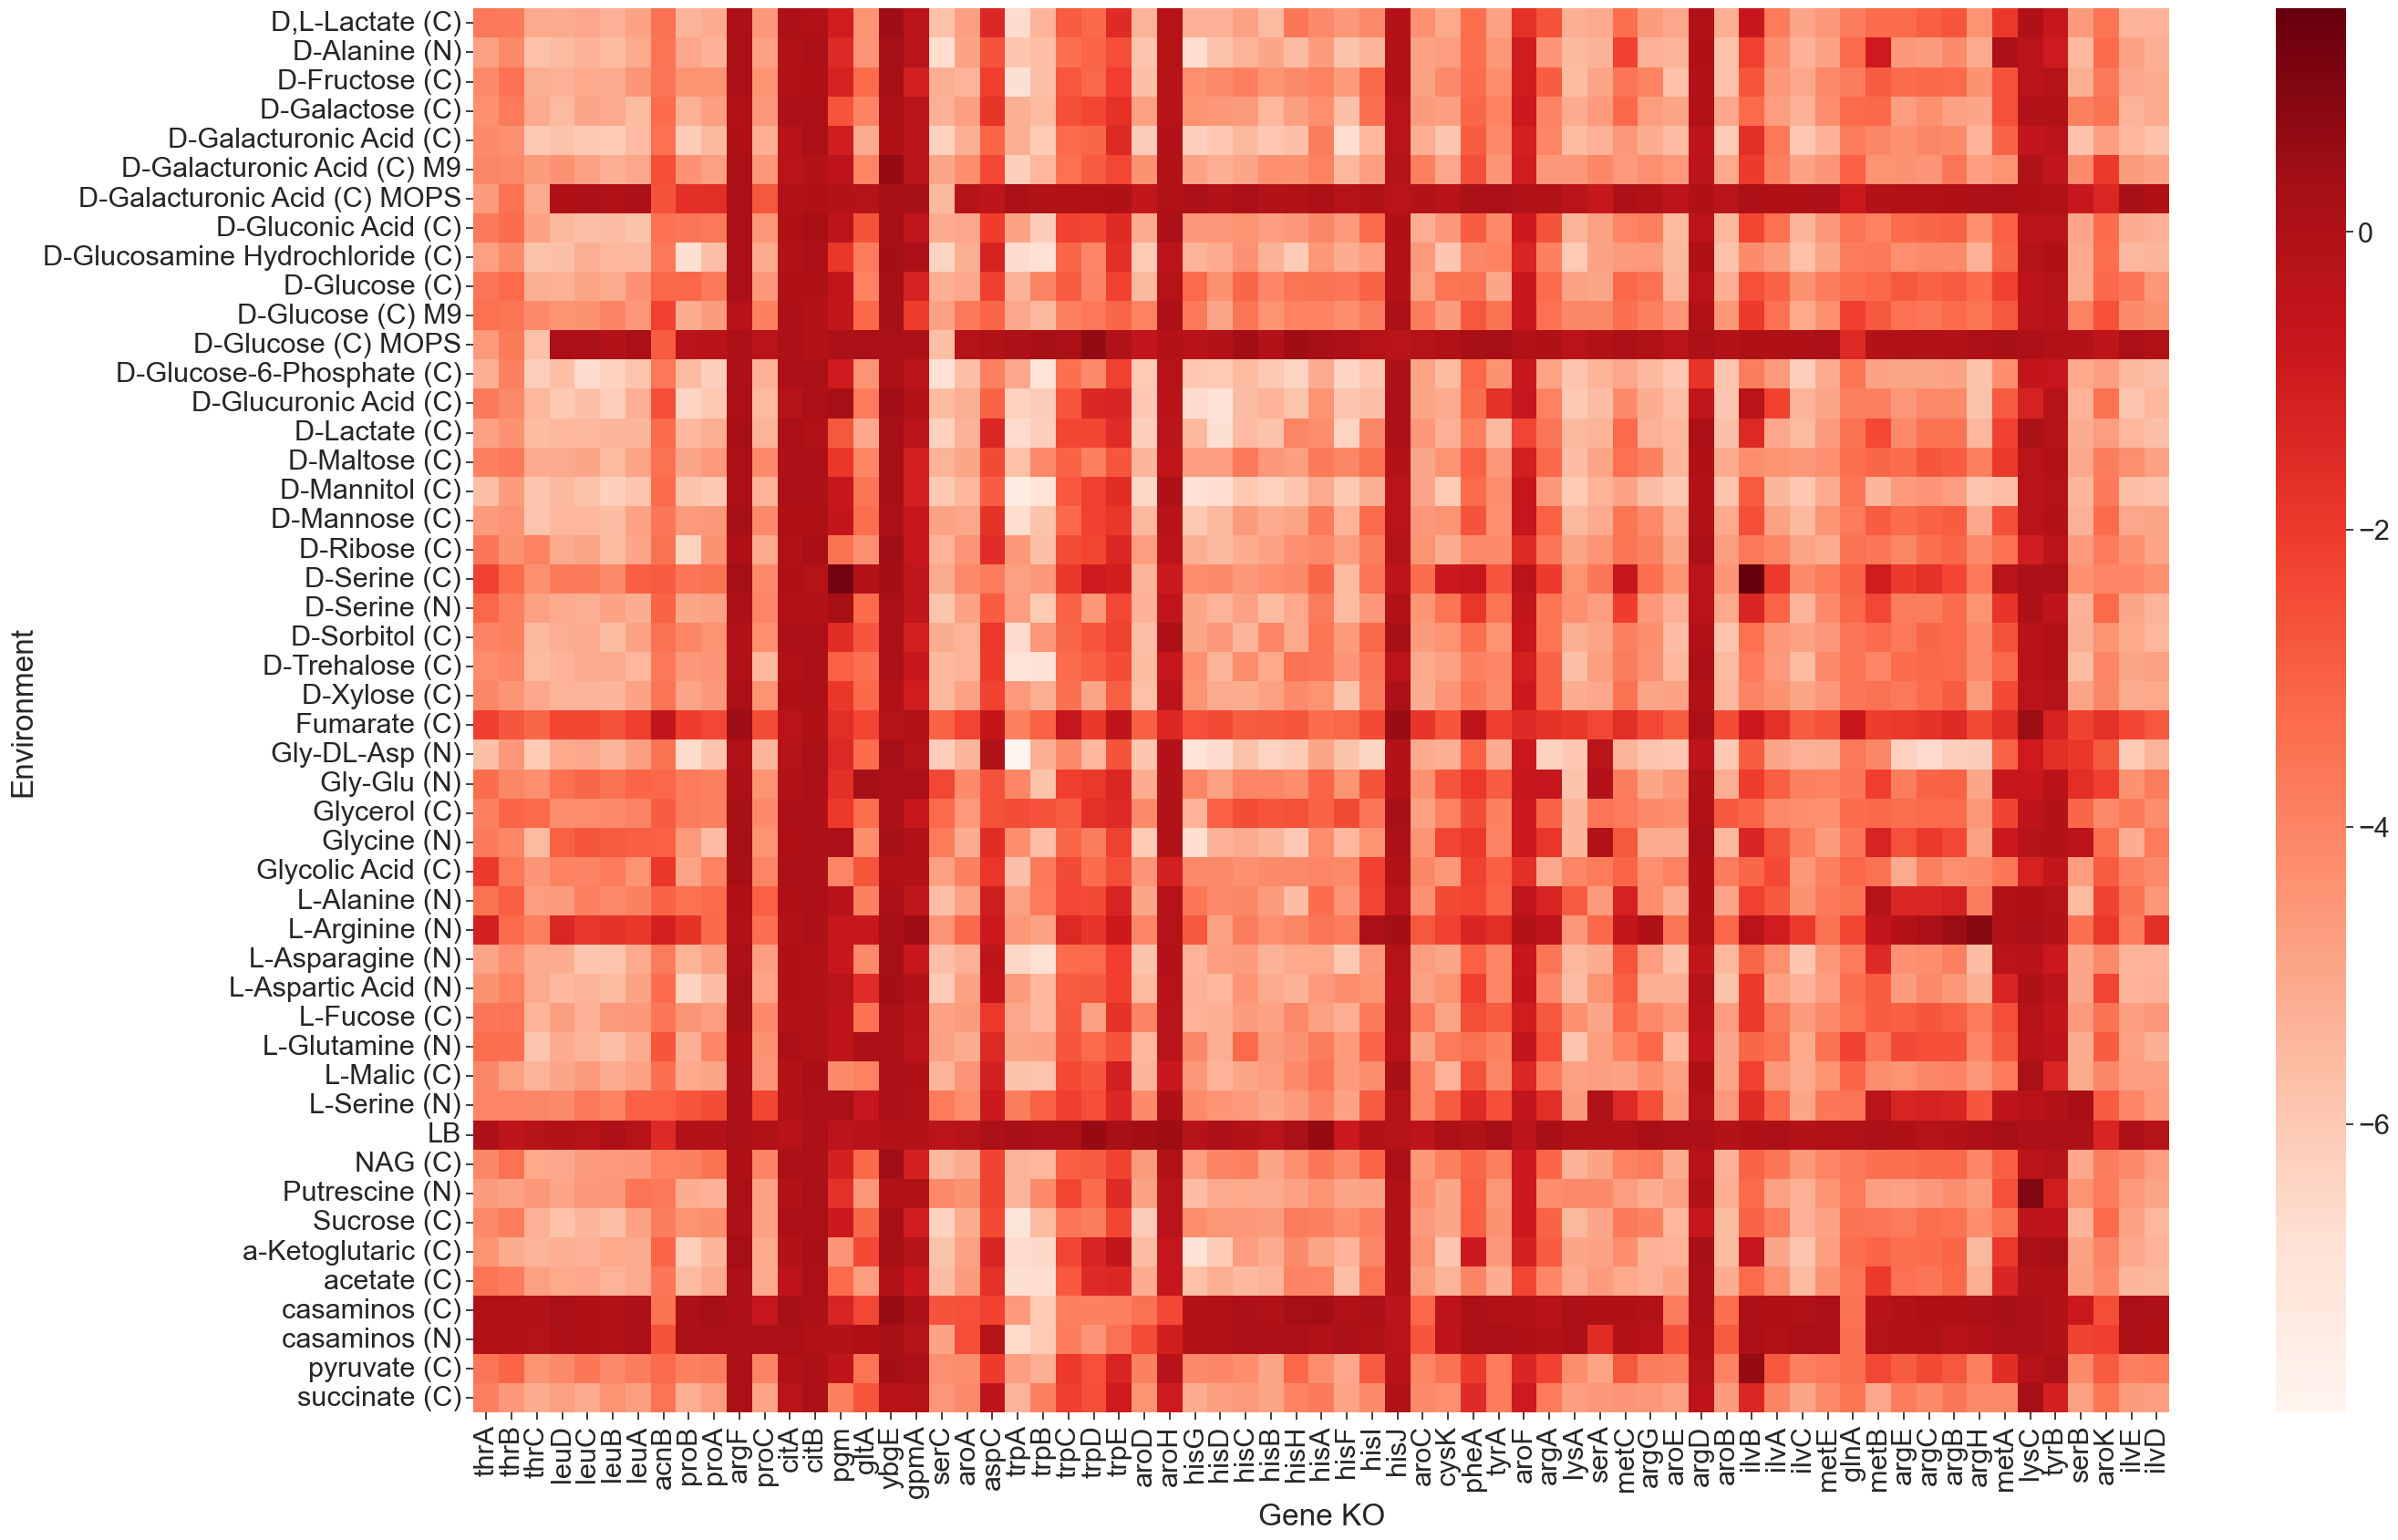

In [70]:
# Figure S4
fig, ax = plt.subplots(1, 1, figsize=(30, 20))
sns.heatmap(data=Wetmore_aux_df_ec.set_index('gene')[Wetmore_aux_df_ec.set_index('gene').columns[3:]].T,
            yticklabels=1, xticklabels=1, cmap='Reds',)

ax.set_ylabel('Environment') ; ax.set_xlabel('Gene KO')

plt.savefig('images/FigS4.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

### Figure S5: Arg shows larger difference than other auxtrophs across species

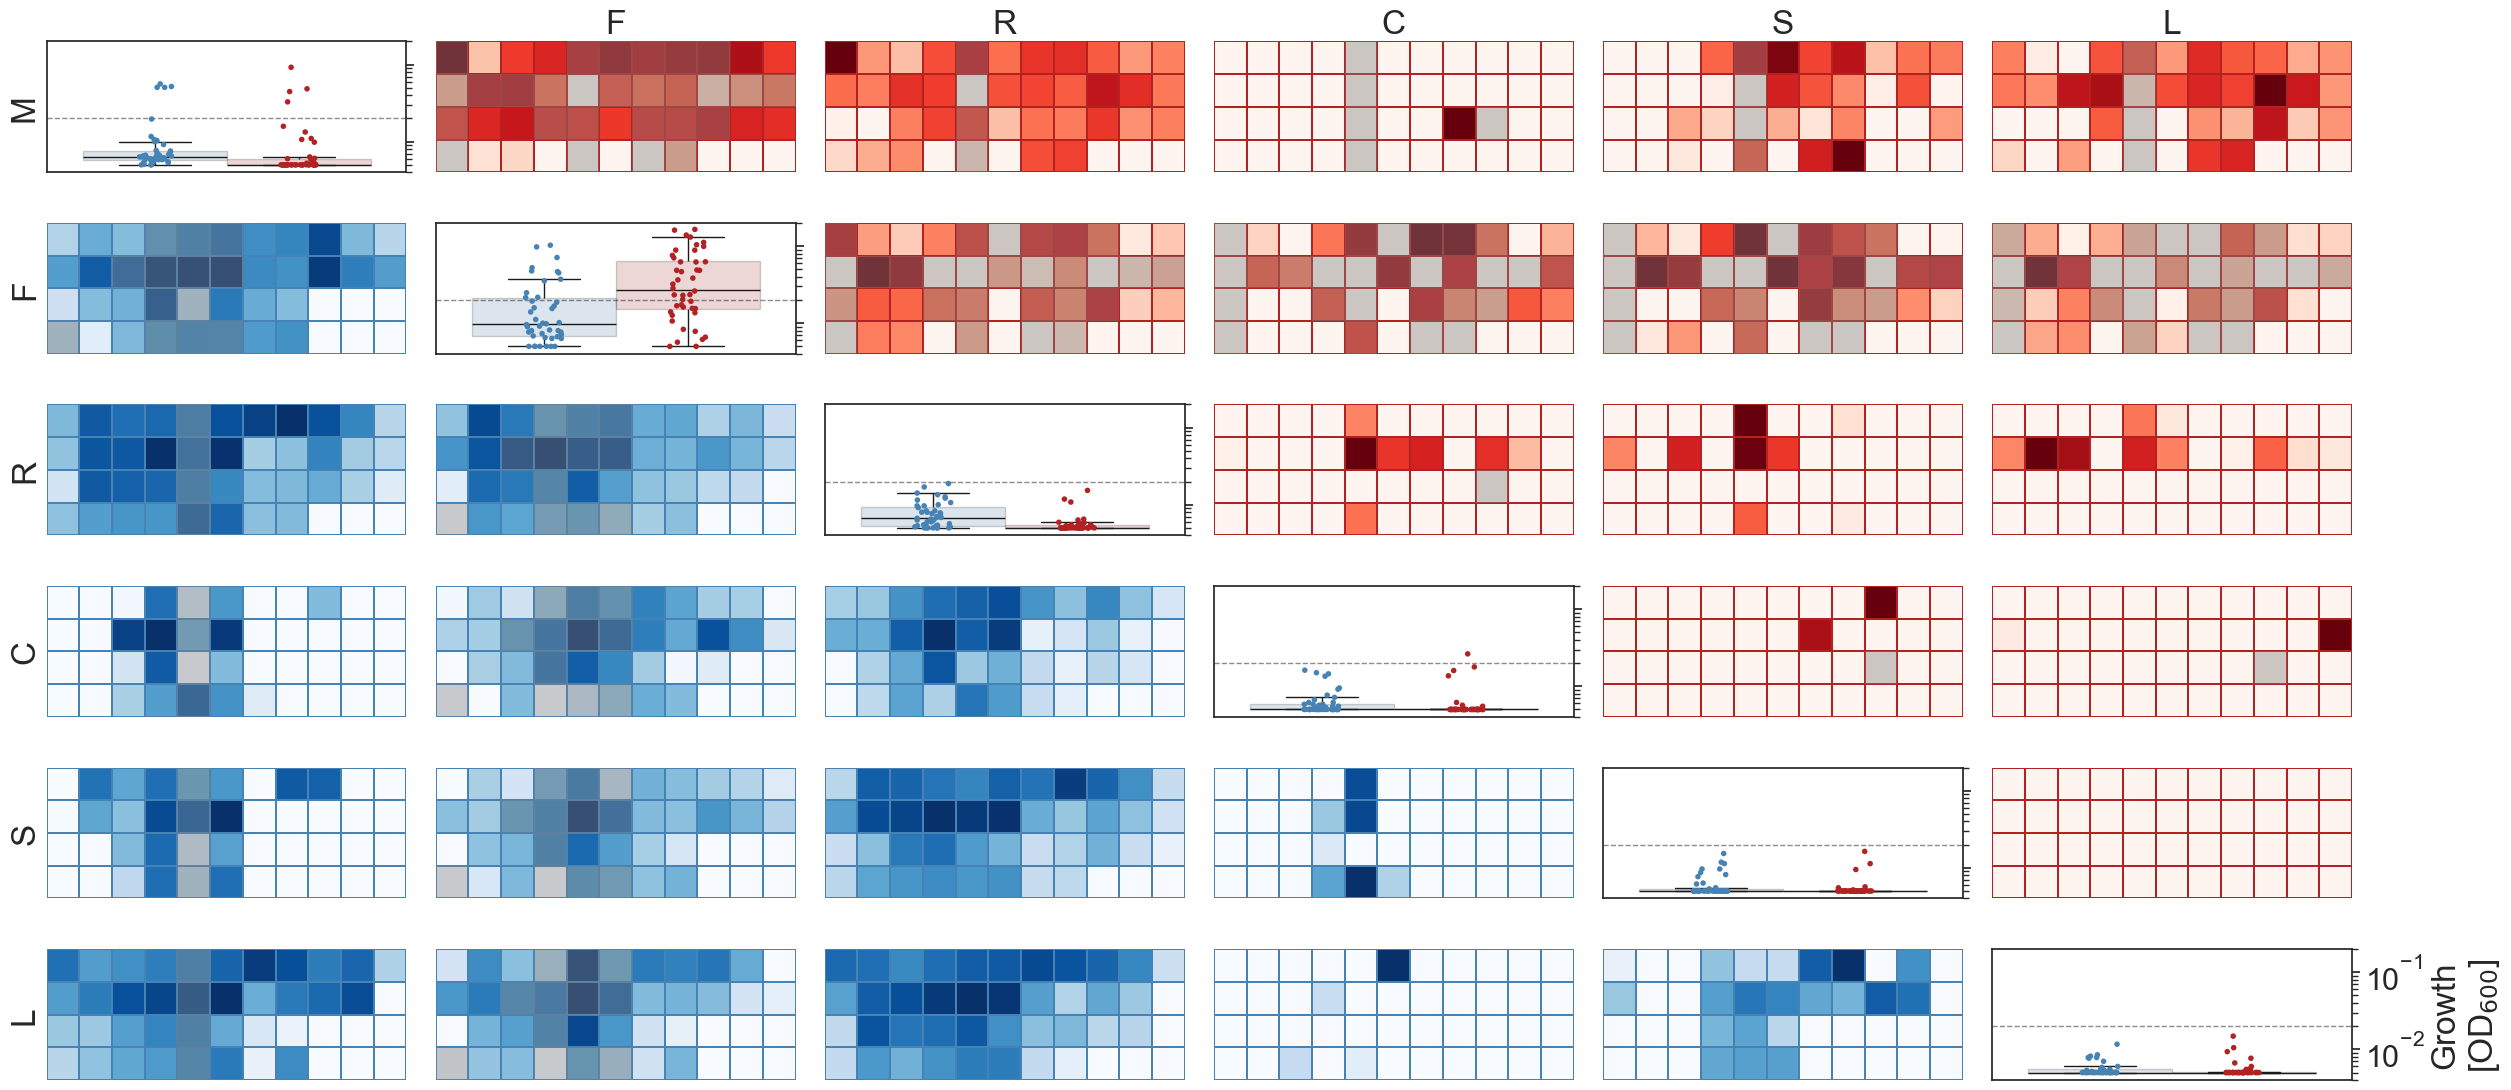

In [72]:
# Figure S5A

# colormaps
cmap_blue = mpl.colormaps['Blues'].copy() ; cmap_red = mpl.colormaps['Reds'].copy()
cmap_blue.set_bad((1, 1, 1, 0)) ; cmap_red.set_bad((1, 1, 1, 0))

graph_order=dict(zip(list(range(0,40)),
                     list(itertools.product(['M','F','R', 'C', 'S', 'L'],
                                            ['M','F','R', 'C', 'S', 'L']))))

C_order = ['Fum', 'Gluc', 'Gly', 'NoC']                 
N_order = ['Ala',  'Asn', 'Asp', 'Glut', 'Gln', 'Pro',
           'GNAc', 'Glcn', 'AmSu', 'Urea', 'NoN',] 

fig, axes = plt.subplots(6, 6, figsize=(25, 11),  constrained_layout=True,
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
for pair in graph_order.keys():
    
    row = pair // 6 ; col = pair % 6
    ax = axes[row, col]
    
    if row <= col:
        aux1=graph_order[pair][0]
        aux2=graph_order[pair][1]
    else:
        aux1=graph_order[pair][1]
        aux2=graph_order[pair][0]
        
    
    if col == row:
        temp=big_norm_df.query("Aux1 == @aux1 and Aux2 == @aux2")

        sns.stripplot(data=temp, x='Pair', y='Mean', ax=ax, s=4, 
                      hue='Species', palette=['steelblue','firebrick'],
                      hue_order=['Bs', 'Ec'], legend=False, dodge=True)        
        sns.boxplot(data=temp, x='Pair', y='Mean', ax=ax, 
                    hue='Species', palette=['steelblue','firebrick'], 
                    hue_order=['Bs', 'Ec'], legend=False,
                    fliersize=0, linecolor="k", boxprops={'alpha':0.2})
        
        ax.set_yscale('log') ; ax.set_ylim(0.004,0.2)
        ax.set_ylabel(''); ax.set_xlabel('')
        ax.tick_params(axis="x", rotation=90)
        ax.axhline(0.02, color='k', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_box_aspect(4/11)
        
        # draw ticks/labels inward so they stay inside the axes box
        ax.tick_params(axis='x', bottom=False, labelbottom=False)
                           
        if col == 5:
            ax.yaxis.tick_right()
            ax.yaxis.set_label_position("right")
            ax.tick_params(axis='y', which='both', right=True, labelright=True,
                           left=False, labelleft=False)   
            ax.set_ylabel('Growth\n'+r'[OD$_{600}$]')


        elif col == 0:
            ax.set_ylabel(aux2)
            ax.set_yticklabels([])
            ax.tick_params(axis='y', left=False)
            ax.tick_params(axis='y', which='both', right=True, labelright=False,
                           left=False, labelleft=False) 

        else:
            ax.yaxis.set_label_position("right")
            ax.set_yticklabels([])
            ax.tick_params(axis='y', which='both', right=True, labelright=False,
                           left=False, labelleft=False) 
        continue
        
    if col > row:
        temp_vals = (big_norm_df.query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Ec'")
                     .pivot(index='C', columns='N', values='Norm_mean')
                     .reindex(index=C_order, columns=N_order))
        
        temp_mask = (big_norm_df.query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Ec'")
                     .pivot(index='C', columns='N', values='filtered_out')
                     .reindex(index=C_order, columns=N_order))

                
        sns.heatmap(temp_vals, cmap='Reds', vmax=0.6, vmin=0.005, square=True, 
                    linewidths=0.005, linecolor='firebrick', norm='log',
                    ax=ax, cbar=False, xticklabels=False, yticklabels=False)
        
         # overlay gray boxes where filtered_out == True
        for y in range(temp_mask.shape[0]):
            for x in range(temp_mask.shape[1]):
                if temp_mask.iloc[y, x]:
                    ax.add_patch(Rectangle((x, y), 1, 1,facecolor='gray',edgecolor='none',alpha=0.4,zorder=10))        
                        
        ax.set_ylabel(''); ax.set_xlabel('')
        if row == 0:
            ax.set_title(aux2)
        continue
        
    if col < row:
        temp_vals = (big_norm_df.query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Bs'")
                     .pivot(index='C', columns='N', values='Norm_mean')
                     .reindex(index=C_order, columns=N_order))
        
        temp_mask = (big_norm_df.query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Bs'")
                     .pivot(index='C', columns='N', values='filtered_out')
                     .reindex(index=C_order, columns=N_order))

                
        sns.heatmap(temp_vals, cmap='Blues', vmax=0.3, vmin=0.005, square=True, 
                    linewidths=0.005, linecolor='steelblue', norm='log',
                    ax=ax, cbar=False, xticklabels=False, yticklabels=False)
        
         # overlay gray boxes where filtered_out == True
        for y in range(temp_mask.shape[0]):
            for x in range(temp_mask.shape[1]):
                if temp_mask.iloc[y, x]:
                    ax.add_patch(Rectangle((x, y), 1, 1,facecolor='gray',edgecolor='none',alpha=0.4,zorder=10))
        
        ax.set_ylabel(''); ax.set_xlabel('')
        if col == 0:
            ax.set_ylabel(aux2);  


plt.savefig('images/FigS5A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

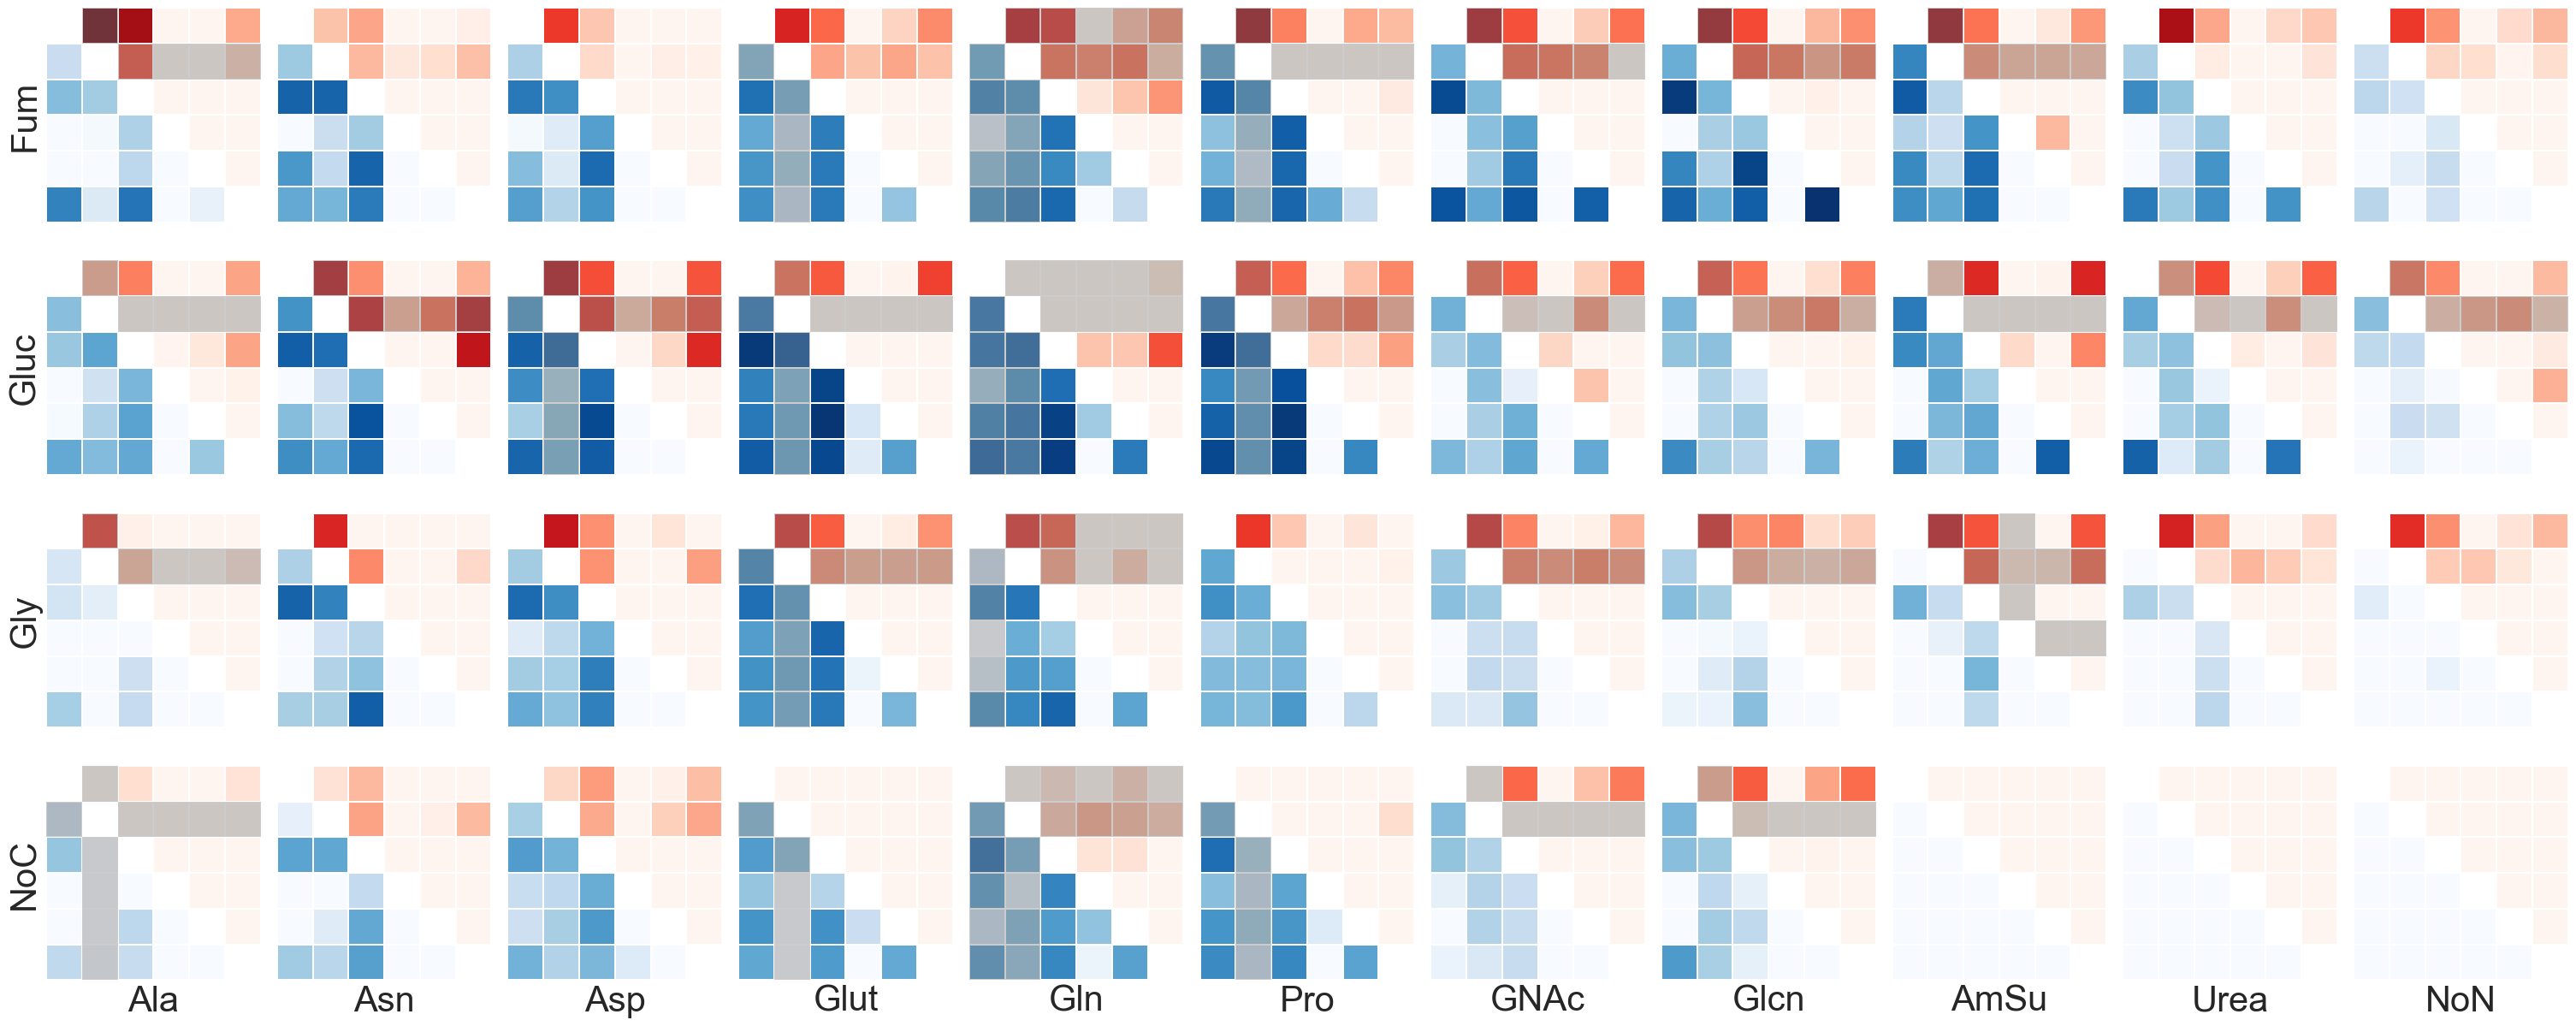

In [73]:
# Figure S5B
graph_order = dict(zip(list(range(0,44)),
                       list(itertools.product(['Fum', 'Gluc', 'Gly', 'NoC'],
                                              ['Ala', 'Asn', 'Asp', 'Glut',
                                               'Gln', 'Pro', 'GNAc', 'Glcn',
                                               'AmSu', 'Urea', 'NoN']))))

pair_order = ['M','F','R','C','S','L']

fig, axes = plt.subplots(4, 11, figsize=(30, 12), constrained_layout=True,
                         gridspec_kw={'wspace': 0.07, 'hspace': 0.07})

for x in graph_order.keys():
    
    row = x // 11; col = x % 11
    ax = axes[row, col]
    env = graph_order[x][1] + " + " + graph_order[x][0]
    
    # Bs in lower triangle - values
    bs_lower = (big_norm_df.query("Environment == @env and Aux1 != 'WT' and Species == 'Bs'")
                .pivot(columns='Aux1', index='Aux2', values='Norm_mean')
                .reindex(index=pair_order, columns=pair_order).astype(float))

    # Bs overlay mask
    bs_overlay = (big_norm_df.query("Environment == @env and Aux1 != 'WT' and Species == 'Bs'")
                  .pivot(columns='Aux1', index='Aux2', values='filtered_out')
                  .reindex(index=pair_order, columns=pair_order).fillna(False).astype(bool))

    # Ec in upper triangle - values
    ec_upper = (big_norm_df.query("Environment == @env and Aux1 != 'WT' and Species == 'Ec'")
                .pivot(columns='Aux1', index='Aux2', values='Norm_mean')
                .reindex(index=pair_order, columns=pair_order).astype(float).T)

    # Ec overlay mask
    ec_overlay = (big_norm_df.query("Environment == @env and Aux1 != 'WT' and Species == 'Ec'")
                  .pivot(columns='Aux1', index='Aux2', values='filtered_out')
                  .reindex(index=pair_order, columns=pair_order).fillna(False).astype(bool).T)
    
    # mask everything except lower triangle for Bs
    mask_bs = np.triu(np.ones(bs_lower.shape, dtype=bool), k=0)
    # mask everything except upper triangle for Ec
    mask_ec = np.tril(np.ones(ec_upper.shape, dtype=bool), k=0)
    
    # plot blue lower triangle
    sns.heatmap(bs_lower, mask=mask_bs, cmap=cmap_blue, norm=LogNorm(vmin=0.005, vmax=0.3), 
                xticklabels=0, yticklabels=0, square=True, linewidths=0.1, cbar=False, ax=ax)
    
    # plot red upper triangle
    sns.heatmap(ec_upper, mask=mask_ec, cmap=cmap_red, norm=LogNorm(vmin=0.005, vmax=0.6), 
                xticklabels=0, yticklabels=0, square=True, linewidths=0.1, cbar=False, ax=ax)

    # gray overlay for Bs lower triangle
    for y in range(bs_overlay.shape[0]):
        for xx in range(bs_overlay.shape[1]):
            if bs_overlay.iloc[y, xx] and y > xx:
                ax.add_patch(Rectangle((xx, y), 1, 1, facecolor='gray', edgecolor='none', alpha=0.4, zorder=10))

    # gray overlay for Ec upper triangle
    for y in range(ec_overlay.shape[0]):
        for xx in range(ec_overlay.shape[1]):
            if ec_overlay.iloc[y, xx] and y < xx:
                ax.add_patch(Rectangle((xx, y), 1, 1,facecolor='gray', edgecolor='none', alpha=0.4, zorder=10))
    
    if col == 0:
        ax.set_ylabel(graph_order[x][0], fontsize=30)
    else:
        ax.set_ylabel('')

    if row == 3: 
        ax.set_xlabel(graph_order[x][1], fontsize=30)
    else:
        ax.set_xlabel('')
    
plt.savefig('images/FigS5B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

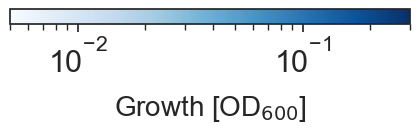

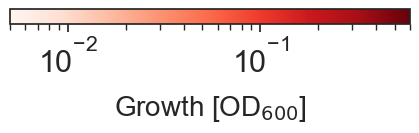

In [74]:
# Figure S5 colorbars
plt.figure(figsize=(5, 0.5))
img = plt.imshow(np.array([[0.005, 0.3]]), cmap="Blues", norm=LogNorm(vmin=0.005, vmax=0.3))
plt.gca().set_visible(False)

cax = plt.axes([0.1, 0.35, 0.8, 0.3])
cb = plt.colorbar(img, cax=cax, orientation="horizontal")
cb.set_label(r'Growth [OD$_{600}$]', fontsize=20, labelpad=10)
plt.savefig('images/Fig3_blue_colorbar.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 


plt.figure(figsize=(5, 0.5))
img = plt.imshow(np.array([[0.005, 0.6]]), cmap="Reds", norm=LogNorm(vmin=0.005, vmax=0.6))
plt.gca().set_visible(False)

cax = plt.axes([0.1, 0.35, 0.8, 0.3])
cb = plt.colorbar(img, cax=cax, orientation="horizontal")
cb.set_label(r'Growth [OD$_{600}$]', fontsize=20, labelpad=10)

plt.savefig('images/Fig3_red_colorbar.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 


# Figure S6
Auxotroph growth without supplemented amino acids

C:\Users\amich\AppData\Local\Temp\ipykernel_3628\2849353239.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pair_order, rotation=0, fontsize=20)


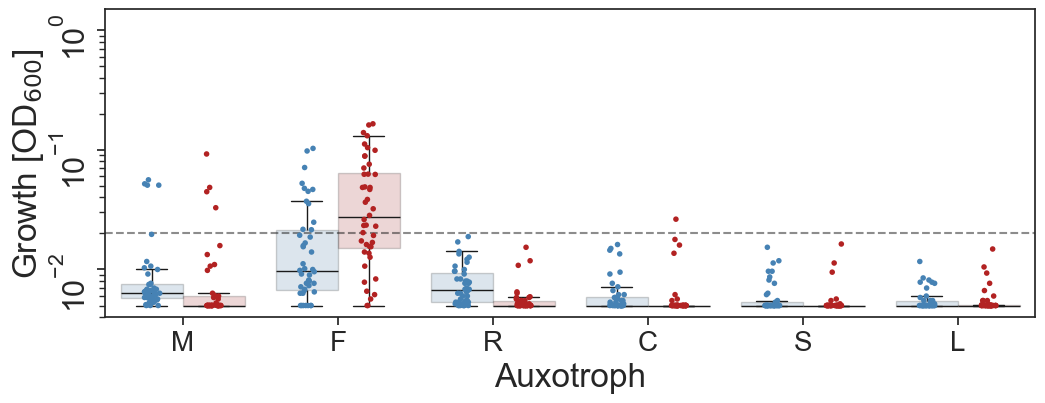

In [76]:
data=big_norm_df.query("Aux1 == Aux2 and Aux1 != 'WT'")
pair_order = ['M','F','R','C','S','L']


fig, ax = plt.subplots(1, 1, figsize=(12, 4))

sns.stripplot(data=data, x='Aux1', y='Mean', ax=ax, s=4, 
              hue='Species', palette=['steelblue','firebrick'],
              hue_order=['Bs', 'Ec'], legend=False, dodge=True,
              order= pair_order)

sns.boxplot(data=data, x='Aux1', y='Mean', ax=ax,
            hue='Species', palette=['steelblue','firebrick'], 
            hue_order=['Bs', 'Ec'], legend=False,
            fliersize=0, linecolor="k", boxprops={'alpha':0.2},
            order= pair_order)


ax.set_yscale('log') ; ax.set_ylim(0.004,1.5)
ax.set_ylabel(r'Growth [OD$_{600}$]') ; ax.set_xlabel('Auxotroph')
ax.tick_params(axis="y", rotation=90)
ax.axhline(0.02, ls="--", color='k', alpha=0.5)
ax.set_xticklabels(pair_order, rotation=0, fontsize=20)

plt.savefig('images/FigS6.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)


### Figures S7-S8

Unfiltered Datasets


In [78]:
#re-generate relvant dataframes from unfiltered data

bs_df_uf = big_norm_df[big_norm_df.Species == 'Bs'].copy()
ec_df_uf = big_norm_df[big_norm_df.Species == 'Ec'].copy()

comp_species_df_uf = pd.merge(bs_df_uf, ec_df_uf, 
                           on=['Environment', 'Pair', 'N', 'C', 'Aux1', 'Aux2'],
                           suffixes=['_Bs', '_Ec'])

# Supplemented monoculture dataframe across species
aa_dic = {}
for pair in ['WT+WT', 'M+Met', 'F+Phe', 'R+Arg', 'C+Cys', 'S+Ser', 'L+Leu']:
    aa_dic[pair] = big_df[big_df.Pair == pair].drop(columns=['Aux1', 'Aux2', 'SEM', 'C', 'N'])

comp_aa_df_uf = aa_dic["WT+WT"]
for pair in ['M+Met', 'F+Phe', 'R+Arg', 'C+Cys', 'S+Ser', 'L+Leu']:
    comp_aa_df_uf = pd.concat([comp_aa_df_uf, aa_dic[pair]])

comp_aa_df_uf_b = pd.merge(comp_aa_df_uf.query("Species == 'Bs'"), 
                           comp_aa_df_uf.query("Species == 'Ec'"), 
                           on=['Environment', 'Pair'], suffixes=['_Bs', '_Ec'])

aa_long_uf = pd.merge(comp_aa_df_uf_b.melt(id_vars=['Environment', 'Pair'], value_vars=['Mean_Bs', 'Mean_Ec'],
                                     var_name='Species', value_name='Mean')
                   .assign(Species=lambda d: d['Species'].str.replace('^Mean_', '', regex=True)),
                   comp_aa_df_uf_b.melt(id_vars=['Environment', 'Pair'], value_vars=['Mean_Bs', 'Mean_Ec'],
                                     var_name='Species', value_name='SEM')
                   .assign(Species=lambda d: d['Species'].str.replace('^Mean_', '', regex=True)))

aa_long_uf[['Aux1', 'Aux2']] = aa_long_uf['Pair'].str.split("+", expand=True)
aa_long_uf[['N', 'C']] = aa_long_uf['Environment'].str.split("+", expand=True)
aa_long_uf['Mean'] = aa_long_uf['Mean'].astype(float)

# Crossfeeding long-form dataframe
df_long_uf = pd.merge((comp_species_df_uf.melt(id_vars=['Environment', 'Pair'], 
                                              value_vars=['Norm_mean_Bs', 'Norm_mean_Ec'],
                                              var_name='Species', value_name='Norm_mean')
                      .replace({"Norm_mean_Bs": "Bs", "Norm_mean_Ec": "Ec"})),
                      (comp_species_df_uf.melt(id_vars=['Environment', 'Pair'], 
                                              value_vars=['Norm_sem_Bs', 'Norm_sem_Ec'],
                                              var_name='Species', value_name='Norm_sem')
                      .replace({"Norm_sem_Bs": "Bs", "Norm_sem_Ec": "Ec"})))

df_long_uf[['Aux1', 'Aux2']] = df_long_uf['Pair'].str.split("+", expand=True)
df_long_uf['Norm_mean'] = df_long_uf['Norm_mean'].astype(float)

mean_by_env_df_uf = big_norm_df.groupby(['Environment', 'C', 'N', 'Species']).mean(numeric_only=True).reset_index()
mean_by_pair_df_uf = big_norm_df.groupby(['Pair', 'Aux1', 'Aux2', 'Species']).mean(numeric_only=True).reset_index()

comp_env_df_uf = pd.merge(mean_by_env_df_uf[mean_by_env_df_uf.Species == 'Bs'],
                       mean_by_env_df_uf[mean_by_env_df_uf.Species == 'Ec'],
                       on=['Environment', 'N', 'C'], suffixes=['_Bs', '_Ec'])

comp_pair_df_uf = pd.merge(mean_by_pair_df_uf[mean_by_pair_df_uf.Species == 'Bs'],
                        mean_by_pair_df_uf[mean_by_pair_df_uf.Species == 'Ec'],
                        on=['Pair', 'Aux1', 'Aux2'], suffixes=['_Bs', '_Ec'])

comp_pair_df_uf = comp_pair_df_uf[comp_pair_df_uf.Aux1 != 'WT'].copy()

cf_comp_pair_df_uf = comp_pair_df_uf[comp_pair_df_uf.Aux1 != 'WT'].copy()


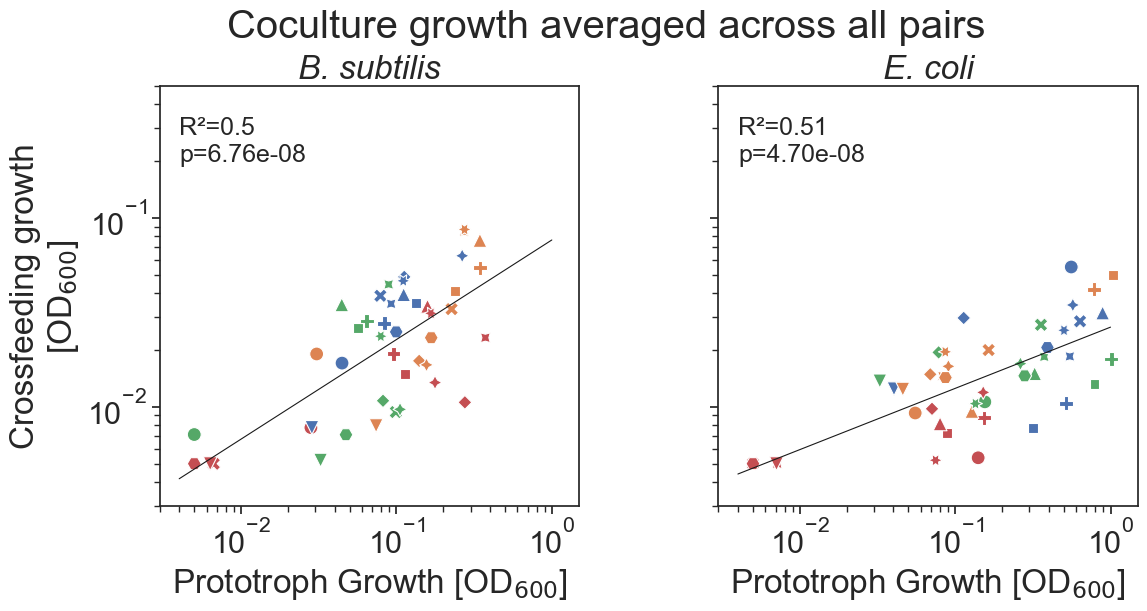

In [79]:
# Figure S7A
mean_by_env_df=(big_norm_df.query("Aux1 !='WT'")
                .groupby(['Environment','C','N','Species'])
                .mean(numeric_only=True).reset_index())

fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True, subplot_kw={'box_aspect': 1},
                         constrained_layout=True)

# Iterate over all axes and set the box aspect
for ax in axes:
    ax.set_box_aspect(1) # Sets the box aspect to be 1:1 (square)

title_dic={'Bs':'B. subtilis','Ec':'E. coli'}

for x, s in enumerate(['Bs','Ec']):
    data = mean_by_env_df[mean_by_env_df["Species"] == s]
    ax=axes[x]
    # 1) scatter with hue=‘C’ and style=‘N’
    sns.scatterplot(x="WT_mean", y="Norm_mean", data=data, 
                    hue="C", style="N", legend=False,
                    ax=ax, s=100, zorder=1)
      
    x_log = np.log10(data["WT_mean"])
    y_log = np.log10(data["Norm_mean"])
    
    # Regression
    r = sp.stats.linregress(x_log, y_log)
    
    x_vals = np.logspace(np.log10(0.004), np.log10(1), 10)
    y_vals = 10**(r.slope * np.log10(x_vals) + r.intercept)
    ax.plot(x_vals, y_vals, color='k', lw=0.8)
    # ax.plot(x_vals, x_vals, color='k', lw=0.8)

    ax.text(0.004, 0.2, ("R²="+str(((r.rvalue)**2).round(2)) +"\n"
                         + f"p={r.pvalue:.2e}"), fontsize=18)

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(0.003, 1.5); ax.set_ylim(0.003, 0.5)
    ax.set_xlabel("Prototroph Growth [OD$_{600}$]"); ax.set_ylabel("Crossfeeding growth\n[OD$_{600}$]")
    ax.set_title(title_dic[s], style='italic')
    fig.suptitle("Coculture growth averaged across all pairs")
    
plt.savefig('images/FigS7A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

Pairs better than WT = 35
924
Pairs better than WT = 5
924
 Total pairs better than WT = 0.021739130434782608


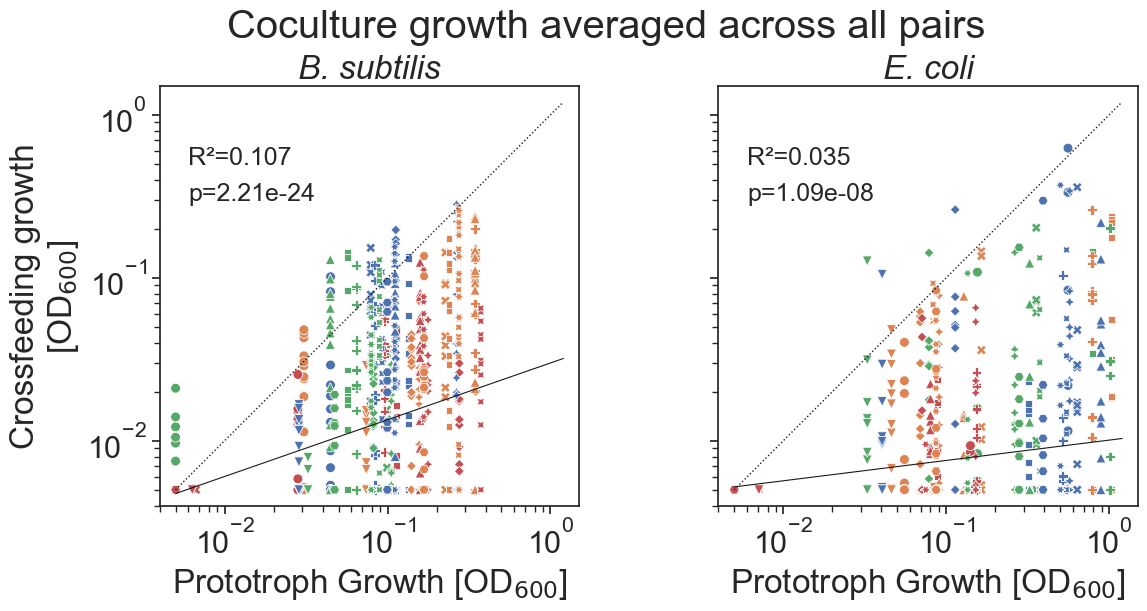

In [80]:
# Figure S7B
fig, axes = plt.subplots(1,2, figsize=(12,6), sharey=True, subplot_kw={'box_aspect': 1},
                         constrained_layout=True)

for ax in axes:
    ax.set_box_aspect(1) # Sets the box aspect to be 1:1 (square)
    
title_dic={0:'B. subtilis',1:'E. coli'}

for x, data in enumerate([bs_df_uf,ec_df_uf]):
    ax = axes[x]
    data=data.query("Aux1 != 'WT'")
    # 1) scatter with hue=‘C’ and style=‘N’
    sns.scatterplot(x="WT_mean", y="Norm_mean",  data=data,
                    hue="C", style="N", ax=ax, legend=False, s=50, zorder=1)
    
   
    # Apply log10
    x_log = np.log10(data["WT_mean"])
    y_log = np.log10(data["Norm_mean"])
    
    # Regression
    r = sp.stats.linregress(x_log, y_log)
    ax.text(0.006, 0.5, "R²="+str(((r.rvalue)**2).round(3)), fontsize=18)
    ax.text(0.006, 0.3, f"p={r.pvalue:.2e}", fontsize=18)
    
    x_vals = np.logspace(np.log10(0.005), np.log10(1.2), 10)
    y_vals = 10**(r.slope * np.log10(x_vals) + r.intercept)
    ax.plot(x_vals, y_vals, color='k', lw=0.8)
    ax.plot(x_vals, x_vals, color='k', lw=1, linestyle='dotted')
    
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Prototroph Growth [OD$_{600}$]"); ax.set_ylabel("Crossfeeding growth\n[OD$_{600}$]")
    ax.set_xlim(0.004, 1.5); ax.set_ylim(0.004, 1.5)
    ax.set_title(title_dic[x], style='italic')
    fig.suptitle("Coculture growth averaged across all pairs")


    handles, labels = axes[0].get_legend_handles_labels()
    print("Pairs better than WT = " + str(len((data[((data.Norm_mean-data.Norm_sem)>data.WT_mean)]))))
    print(str(len((data))))
print(" Total pairs better than WT = " + str(len((filtered_df[((filtered_df.Norm_mean-filtered_df.Norm_sem)>
                                                                filtered_df.WT_mean)]))/len(filtered_df)))

plt.savefig('images/FigS7B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

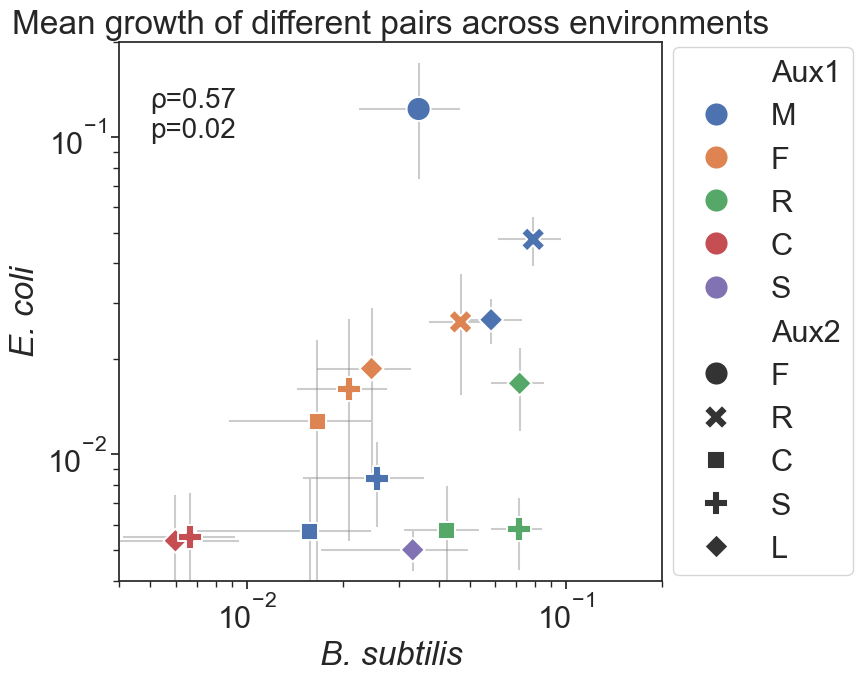

In [81]:
# Source comparison plot related to S7/S8
fig, ax = plt.subplots(1,1, figsize=(7,7),gridspec_kw={'wspace': 0.5})

data=cf_comp_pair_df_uf.query('Aux1!= Aux2')
sns.scatterplot(data=data,
                x='Norm_mean_Bs', y='Norm_mean_Ec',
                hue="Aux1", hue_order=['M', 'F', 'R', 'C', 'S'],
                style="Aux2", style_order=['F', 'R', 'C', 'S', 'L'],
                ax=ax, legend="full", s=300, zorder=1)

# 2) overlay errorbars
for _, row in data.iterrows():
    ax.errorbar(row["Norm_mean_Bs"], row["Norm_mean_Ec"],
                xerr=row["Norm_sem_Bs"], yerr=row["Norm_sem_Ec"],
                fmt="none", ecolor="gray", alpha=0.4, zorder=0)

# ax.plot(np.arange(0.001,0.3,0.002), np.arange(0.001,0.3,0.002), color='k', lw=0.8)

# r, pval = sp.stats.linregress(data["Mean_Bs"], data["Mean_Ec"])[2:4]
# ax.text(0.001, 0.085, "R²="+str((r**2).round(2)), fontsize=20)
# ax.text(0.001, 0.06, f"p={pval.round(2)}", fontsize=20)
rho, rho_pval = sp.stats.spearmanr(data["Norm_mean_Bs"], data["Norm_mean_Ec"])
ax.text(0.005, 0.1, (f"ρ={rho.round(2)}"+"\n"+
                       f"p={rho_pval.round(2)}"), fontsize=20)



ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.004, 0.2); ax.set_ylim(0.004, 0.2)
ax.set_xlabel("B. subtilis", style='italic'); ax.set_ylabel("E. coli", style='italic')
ax.set_title('Mean growth of different pairs across environments')
ax.legend( loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0,)
plt.savefig('images/FigS8A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

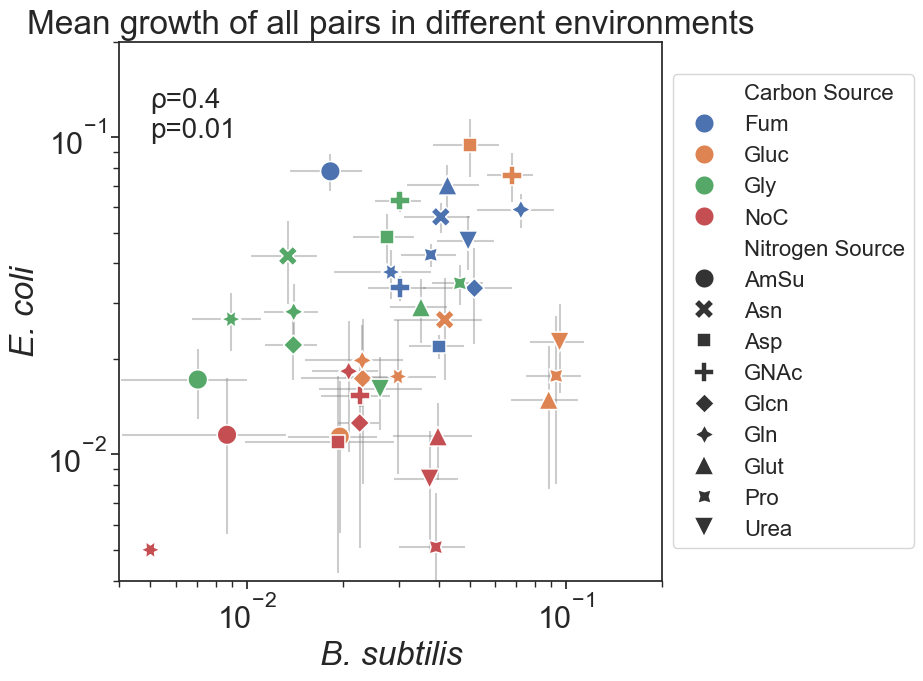

In [82]:
# Source comparison plot related to S7/S8
fig, ax = plt.subplots(1,1, figsize=(7,7),gridspec_kw={'wspace': 0.5})

data=comp_env_df_uf.query("Environment != 'AmSu + NoC' and " +  
                          # "Environment != 'Urea + NoC' and " +  
                          "N != 'NoN'") # removes 3 environments without any carbon and no nitrogen environments
sns.scatterplot(data=data,
                x='Norm_mean_Bs', y='Norm_mean_Ec',
                hue="C", style="N", ax=ax, legend="full", s=200, zorder=1)

# 2) overlay errorbars
for _, row in data.iterrows():
    ax.errorbar(row["Norm_mean_Bs"], row["Norm_mean_Ec"],
                xerr=row["Norm_sem_Bs"], yerr=row["Norm_sem_Ec"],
                fmt="none", ecolor="gray", alpha=0.4, zorder=0)

# ax.plot(np.arange(0.001,0.3,0.002), np.arange(0.001,0.3,0.002), color='k', lw=0.8)

# r, r_pval = sp.stats.linregress(data["Mean_Bs"], data["Mean_Ec"])[2:4]

rho, rho_pval = sp.stats.spearmanr(data["Mean_Bs"], data["Mean_Ec"])
ax.text(0.005, 0.1, (f"ρ={rho.round(2)}"+"\n"+
                       f"p={rho_pval.round(2)}"), fontsize=20)



ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.004, 0.2); ax.set_ylim(0.004, 0.2)
ax.set_xlabel("B. subtilis", style='italic'); ax.set_ylabel("E. coli", style='italic')
ax.set_title('Mean growth of all pairs in different environments')
handles, labels = ax.get_legend_handles_labels()

ax.legend(handles, ['Carbon Source']+labels[1:5]+['Nitrogen Source']+labels[7:],
          loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0, fontsize=16)
handles, labels = ax.get_legend_handles_labels()
plt.savefig('images/FigS8B.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

### Figure S9 High variation still in growth after normalization to prototroph growth

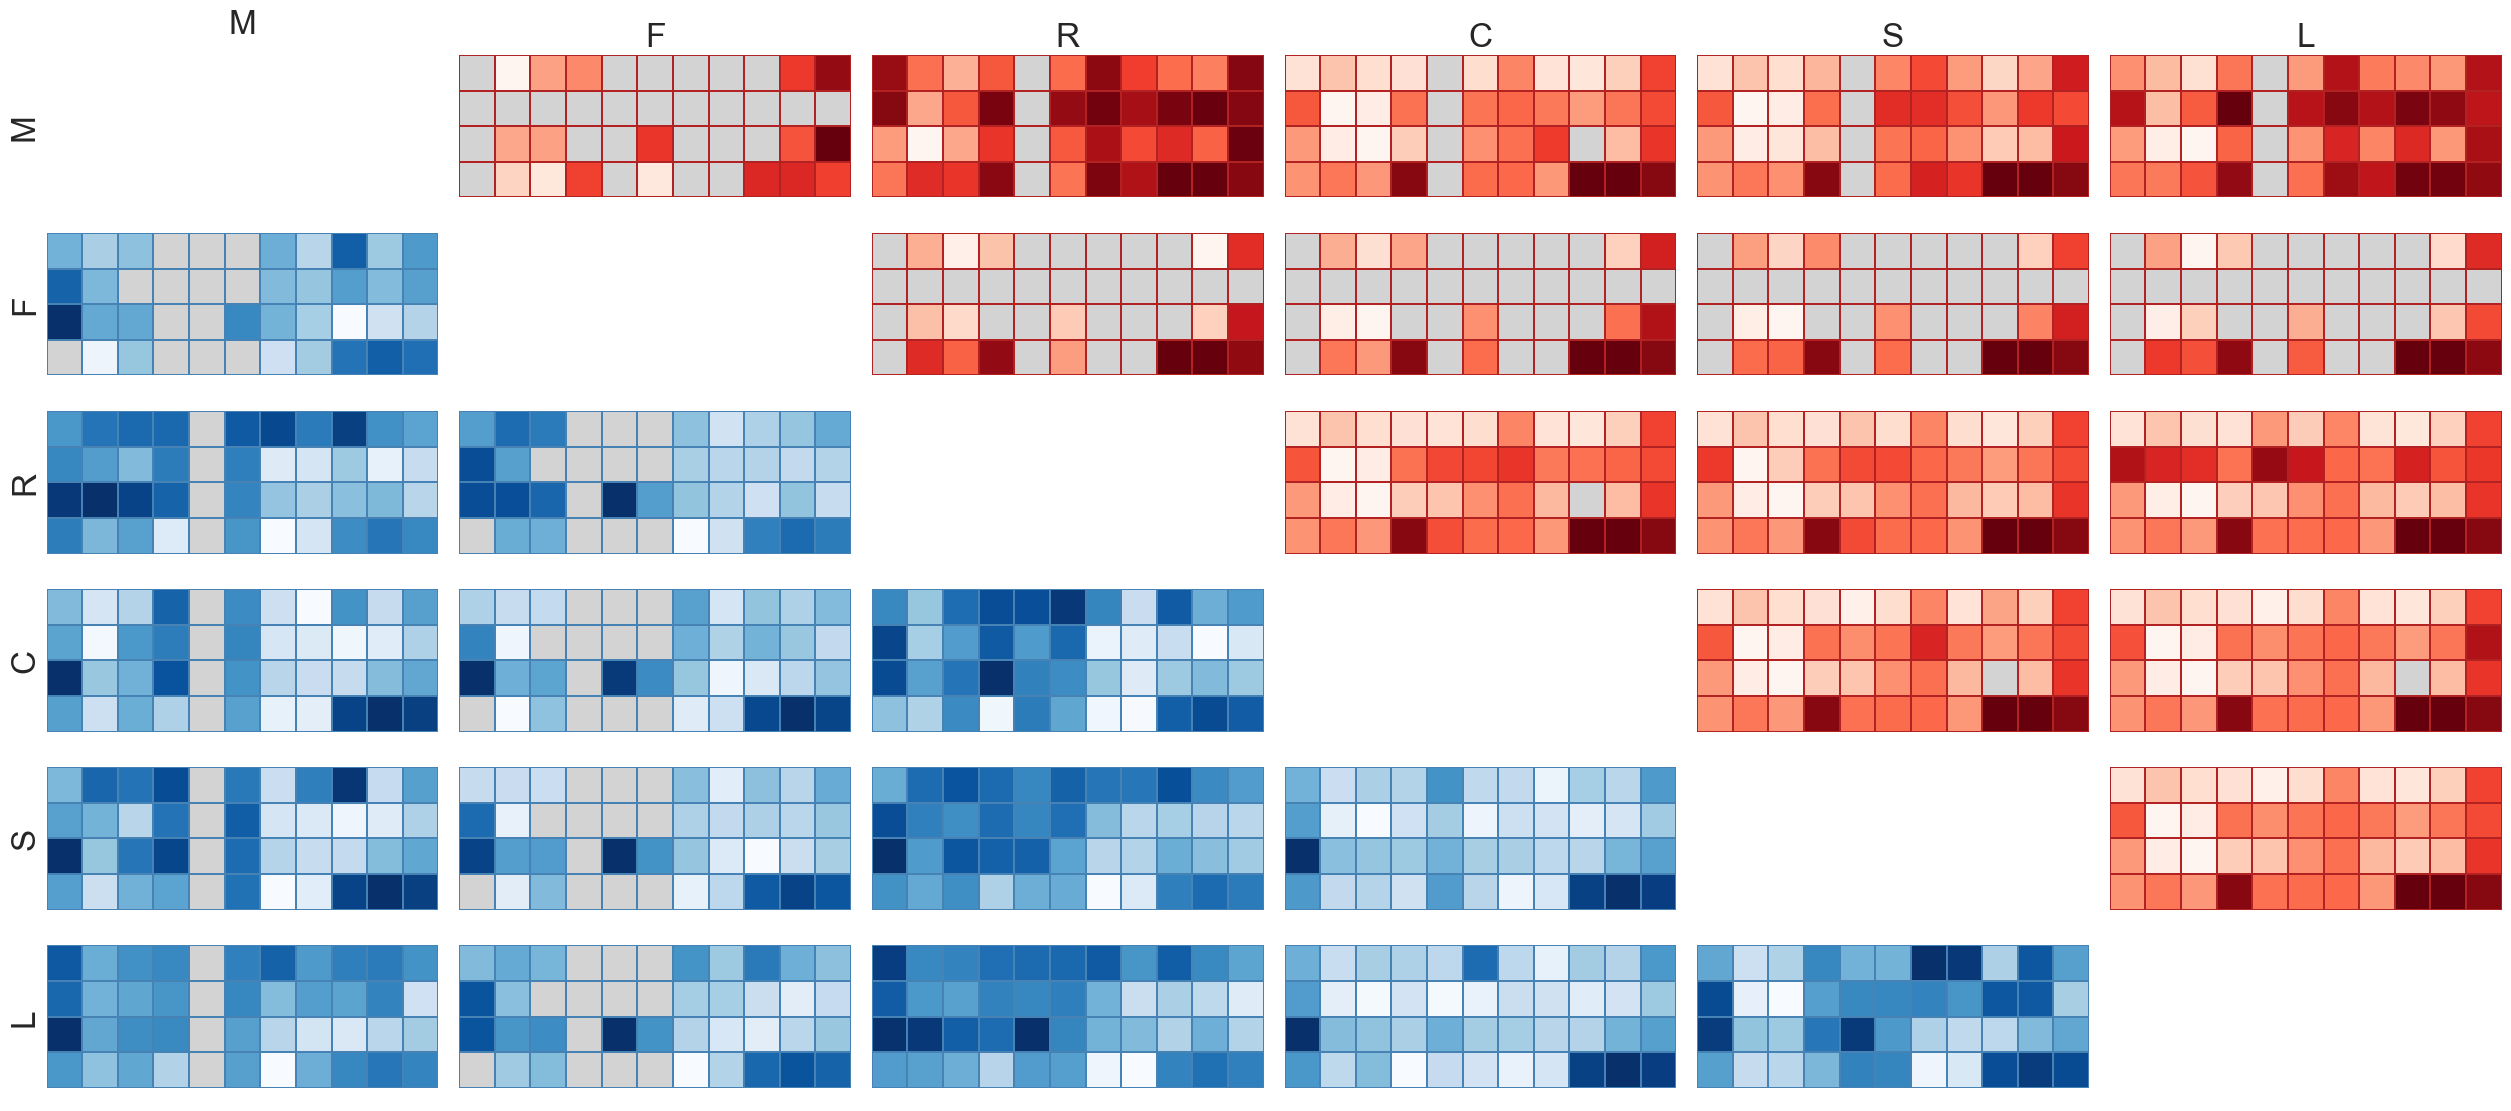

In [84]:
# Figure S9

cmap_red = mpl.colormaps['Reds'].copy(); cmap_blue = mpl.colormaps['Blues'].copy()
cmap_red.set_bad('lightgray'); cmap_blue.set_bad('lightgray')


graph_order=dict(zip(list(range(0,40)),
                     list(itertools.product(['M','F','R', 'C', 'S', 'L'],
                                            ['M','F','R', 'C', 'S', 'L']))))

C_order = ['Fum', 'Gluc', 'Gly', 'NoC']                 
N_order = ['Ala',  'Asn', 'Asp', 'Glut', 'Gln', 'Pro',
           'GNAc', 'Glcn', 'AmSu', 'Urea', 'NoN',] 

fig, axes = plt.subplots(6, 6, figsize=(25, 11),  constrained_layout=True,
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
for pair in graph_order.keys():
    
    row = pair // 6 ; col = pair % 6
    ax = axes[row, col]
    
    if row <= col:
        aux1=graph_order[pair][0]
        aux2=graph_order[pair][1]
    else:
        aux1=graph_order[pair][1]
        aux2=graph_order[pair][0]
        
    
    if col == row:
        ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
        ax.tick_params(left=False, bottom=False)
        ax.tick_params(labelleft=False, labelbottom=False)
        if col == 0:
            ax.set_title(aux2)
            ax.set_ylabel(aux2)

        
    if col > row:
        temp_norm=(filtered_df
              .query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Ec'")
              .pivot(index='C', columns='N', values='Norm_mean')
              .reindex(index=C_order, columns=N_order))

        temp_WT=(filtered_df
              .query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Ec'")
              .pivot(index='C', columns='N', values='WT_mean')
              .reindex(index=C_order, columns=N_order))

        sns.heatmap(temp_norm/temp_WT, cmap=cmap_red, vmin=0.04, vmax=3, square=True, 
                    linewidths=0.005, linecolor='firebrick', norm='log',
                    ax=ax, cbar=False, xticklabels=False, yticklabels=False)
        ax.set_ylabel(''); ax.set_xlabel('')
        if row == 0:
            ax.set_title(aux2)
        continue
        
    if col < row:
        temp_norm=(filtered_df
              .query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Bs'")
              .pivot(index='C', columns='N', values='Norm_mean')
              .reindex(index=C_order, columns=N_order))

        temp_WT=(filtered_df
              .query("Aux1 == @aux1 and Aux2 == @aux2 and Species == 'Bs'")
              .pivot(index='C', columns='N', values='WT_mean')
              .reindex(index=C_order, columns=N_order))

        sns.heatmap(temp_norm/temp_WT, cmap=cmap_blue, vmin=0.04, vmax=3, square=True,
                    linewidths=0.005, linecolor='steelblue', norm='log',
                    ax=ax, cbar=False, xticklabels=False, yticklabels=False)
        ax.set_ylabel(''); ax.set_xlabel('')

        if col == 0:
            ax.set_ylabel(aux2);

plt.savefig('images/FigS9.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 


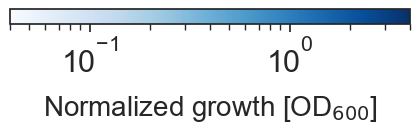

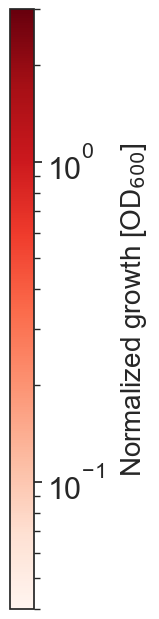

In [85]:
# Figure S6 colorbars
plt.figure(figsize=(5, 0.5))
img = plt.imshow(np.array([[0.004, 4]]), cmap="Blues", norm=LogNorm(vmin=0.04, vmax=4))
plt.gca().set_visible(False)

cax = plt.axes([0.1, 0.35, 0.8, 0.3])
cb = plt.colorbar(img, cax=cax, orientation="horizontal")
cb.set_label(r'Normalized growth [OD$_{600}$]', fontsize=20, labelpad=10)
plt.savefig('images/FigS9_blue_colorbar.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 


# Vertical colorbar
plt.figure(figsize=(0.3, 20))
img = plt.imshow(np.array([[0.004, 3]]), cmap="Reds", norm=LogNorm(vmin=0.04, vmax=3))
plt.gca().set_visible(False)

cax = plt.axes([0.1, 0.35, 0.8, 0.3])
cb = plt.colorbar(img, cax=cax, orientation="vertical")
cb.set_label(r'Normalized growth [OD$_{600}$]', fontsize=20, labelpad=10)
plt.savefig('images/FigS9_red_colorbar.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2) 

# Figure S10 Amino acid requirments

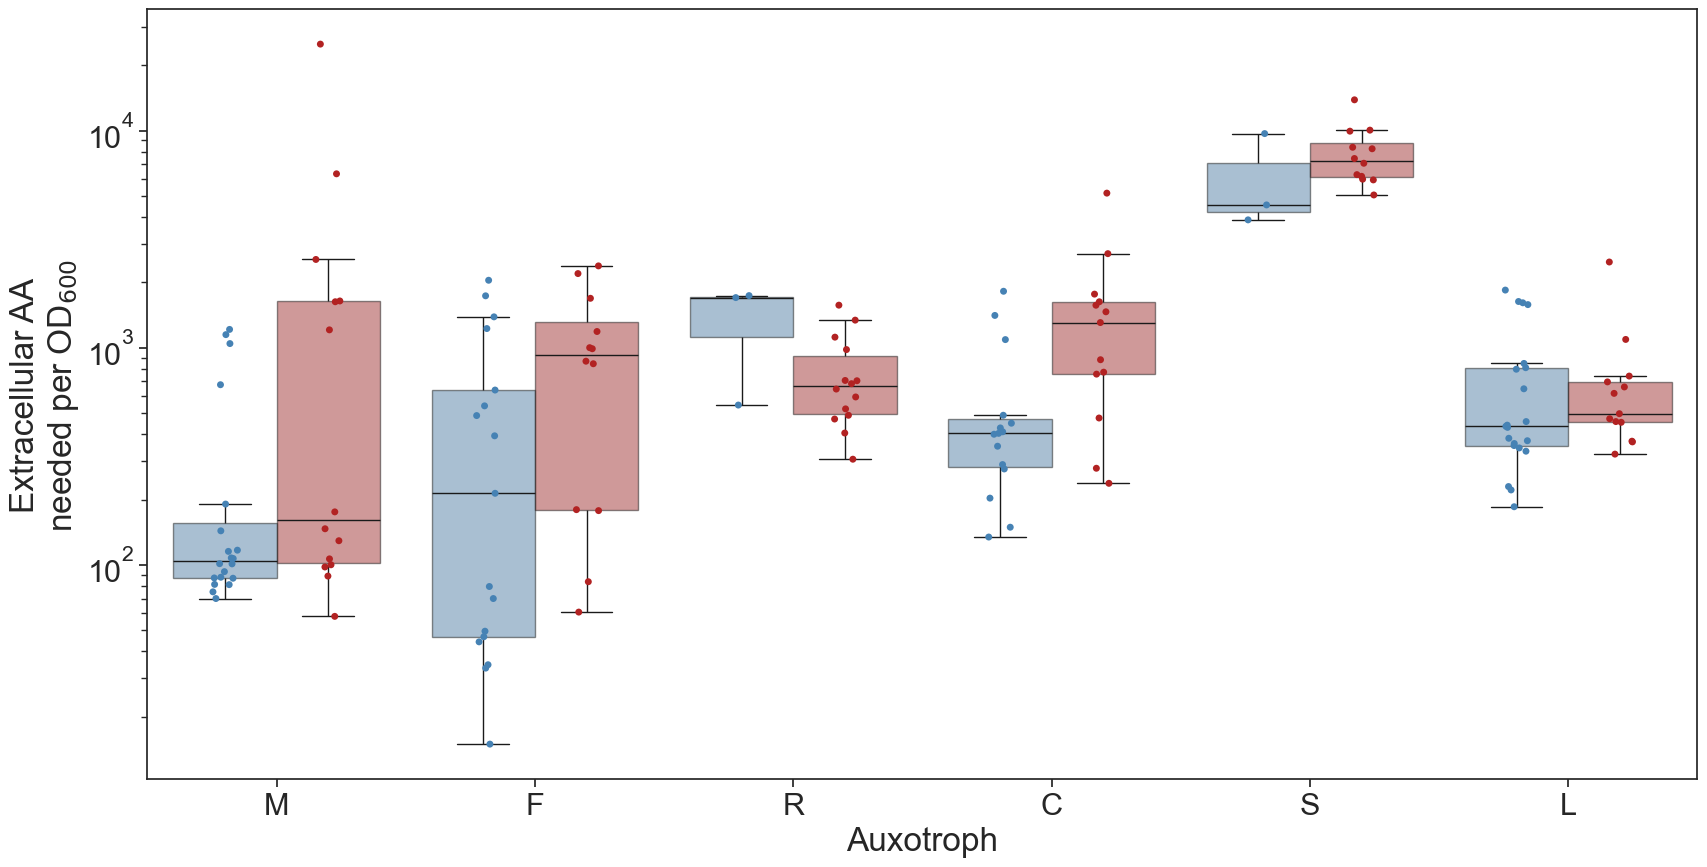

In [87]:
fig, axes = plt.subplots(1,1, figsize=(20,10))
 
g=sns.stripplot(data=aa_requirments_dataset, x='Aux', y='aa_per_od', s=5, hue='Species', 
                dodge=True, palette=['steelblue','firebrick'], legend=False,
                order=["M", "F", "R", "C", "S", "L"])

g=sns.boxplot(data=aa_requirments_dataset, x='Aux', y='aa_per_od', legend=False, hue='Species', dodge=True,
              palette=['steelblue','firebrick'], boxprops=dict(alpha=0.5), 
              fliersize=0, linecolor="k",)

g.set_yscale('log')
g.set_ylabel('Extracellular AA\nneeded per OD$_{600}$')
g.set_xlabel('Auxotroph');
# g.legend( loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0,);
plt.savefig('images/FigS10.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)

### Figure S11. Random forest model performance and feature importance

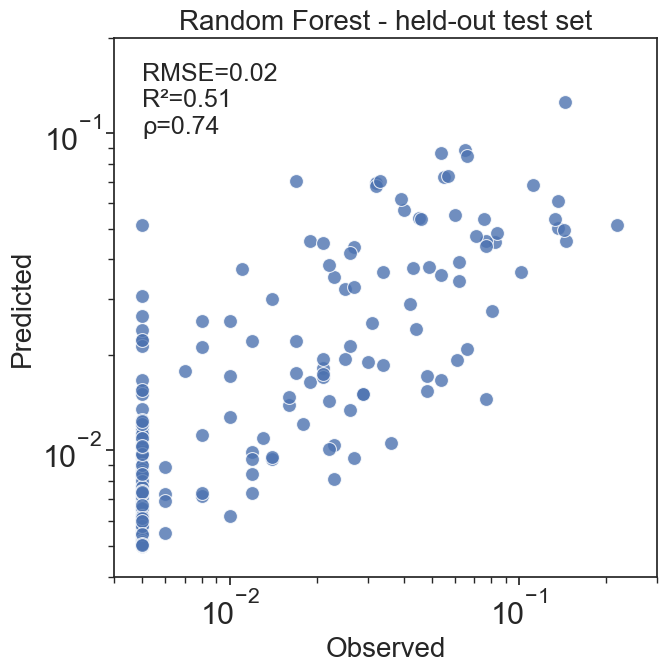

In [89]:
# Figure S9A
fig, ax = plt.subplots(1,1, figsize=(7,7),gridspec_kw={'wspace': 0.5})

sns.scatterplot(x=y_test, y=pred_test, s=100, zorder=1, alpha=0.8)


ax.text(0.005, 0.1, (f"RMSE={round(rmse_test,2)}"+"\n"+
                     f"R²={round(r2_test,2)}"+"\n"+
                     f"ρ={round(spearmanr(y_test, pred_test).correlation,2)}"), fontsize=18)


ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.004, 0.3); ax.set_ylim(0.004, 0.2)
ax.set_xlabel("Observed", fontsize=20); ax.set_ylabel("Predicted", fontsize=20)
ax.set_title('Random Forest - held-out test set', fontsize=20)
plt.savefig('images/FigS11A.jpeg', dpi=300, bbox_inches='tight', pad_inches=0.2)


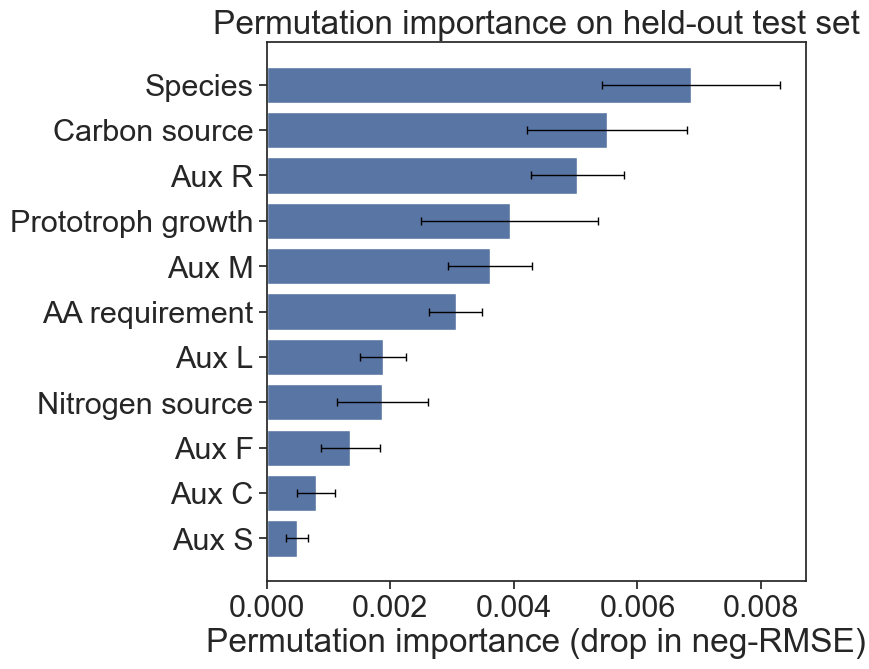

In [90]:
label_map = {"WT_mean": "Prototroph growth","pair_aa_requirment": "AA requirement",
             "Aux_R": "Aux R", "Aux_M": "Aux M", "Aux_L": "Aux L",
             "Aux_F": "Aux F", "Aux_C": "Aux C", "Aux_S": "Aux S",
             "C":"Carbon source","N":"Nitrogen source"}

perm_test_df["feature_label"] = perm_test_df["feature"].replace(label_map)


# Figure S9B
fig, ax = plt.subplots(1,1, figsize=(10,7), subplot_kw={'box_aspect': 1})
ax = sns.barplot(data=perm_test_df, y="feature_label",x="importance_mean",
                 orient="h")

ax.errorbar(x=perm_test_df["importance_mean"], y=range(len(perm_test_df)),
            xerr=perm_test_df["importance_std"], fmt="none",
            capsize=3, color="black", linewidth=1)

ax.set_xlabel("Permutation importance (drop in neg-RMSE)")
ax.set_ylabel("")
ax.set_title("Permutation importance on held-out test set")

plt.savefig("images/FigS11B.jpeg", dpi=300, bbox_inches="tight", pad_inches=0.2)


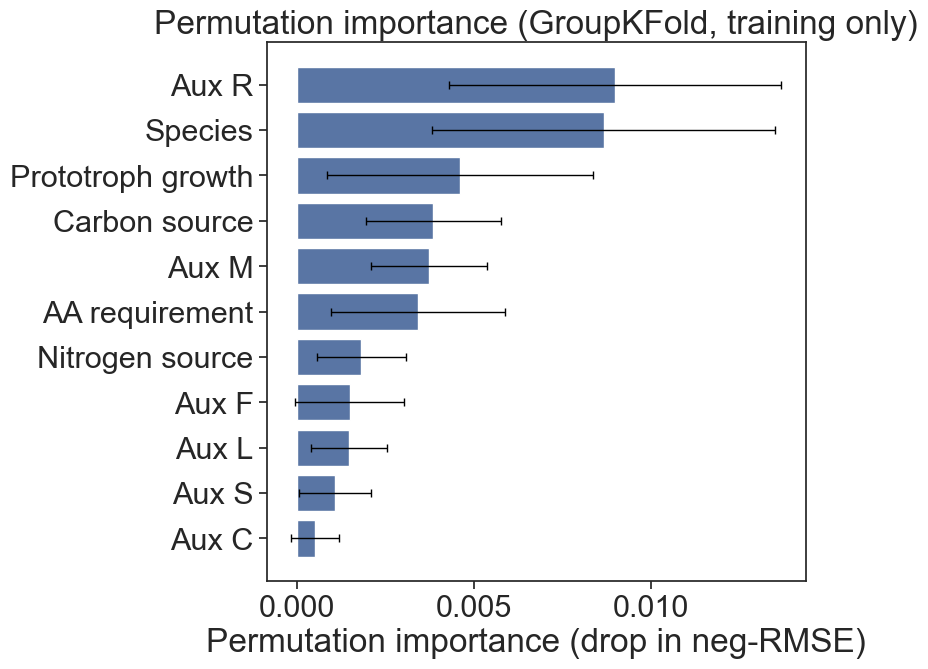

In [91]:
# Figure S9C
perm_cv_df["feature_label"] = perm_cv_df["feature"].replace(label_map)

fig, ax = plt.subplots(1,1, figsize=(10,7), subplot_kw={'box_aspect': 1})
ax = sns.barplot(data=perm_cv_df, y="feature_label",x="importance_mean",
                 orient="h")

ax.errorbar(x=perm_cv_df["importance_mean"], y=range(len(perm_cv_df)),
            xerr=perm_cv_df["importance_std"], fmt="none",
            capsize=3, color="black", linewidth=1)

ax.set_xlabel("Permutation importance (drop in neg-RMSE)")
ax.set_ylabel("")
plt.title("Permutation importance (GroupKFold, training only)")

plt.savefig("images/FigS11C.jpeg", dpi=300, bbox_inches="tight", pad_inches=0.2)


# Table S1
Auxotrophy type level differences in cross-feeding between species


In [93]:
aux_diff_across_sp=cf_comp_pair_df.copy().query("Aux1 != Aux2")[['Aux1','Aux2','Norm_mean_Bs','Norm_mean_Ec']]
aux_diff_across_sp['diff']=abs(aux_diff_across_sp['Norm_mean_Bs']-aux_diff_across_sp['Norm_mean_Ec'])


results = []

for aux in ['M', 'F', 'R', 'C', 'S', 'L']:
    contains_aux = (aux_diff_across_sp["Aux1"] == aux) | (aux_diff_across_sp["Aux2"] == aux)

    contains_vals = aux_diff_across_sp.loc[contains_aux, "diff"].values
    other_vals = aux_diff_across_sp.loc[~contains_aux, "diff"].values

    mean_contains = contains_vals.mean()
    mean_other = other_vals.mean()
    contrast = mean_contains - mean_other

    # One-sided test: are pairs containing this auxotrophy more species-divergent?
    mw = mannwhitneyu(contains_vals, other_vals, alternative= 'greater')

    results.append({"Auxotrophy": aux, "Mean difference in pairs containing auxotrophy type": mean_contains,
                    "Mean difference in pairs not containing auxotrophy type": mean_other, 
                    "Contrast": contrast, "Mann-WhitneyU_p": mw.pvalue})

results = pd.DataFrame(results)

# Correct for testing all six auxotrophies
results["FDR_p"] = multipletests(results["Mann-WhitneyU_p"], method="fdr_bh")[1]

results = results.sort_values("Contrast", ascending=False).round(3)

results

,Auxotrophy,Mean difference in pairs containing auxotrophy type,Mean difference in pairs not containing auxotrophy type,Contrast,Mann-WhitneyU_p,FDR_p
2,R,0.042,0.017,0.025,0.010,0.058
0,M,0.028,0.023,0.005,0.257,0.770
5,L,0.024,0.025,-0.001,0.570,0.892
4,S,0.024,0.026,-0.002,0.616,0.892
1,F,0.021,0.027,-0.006,0.743,0.892
3,C,0.011,0.032,-0.021,0.986,0.986


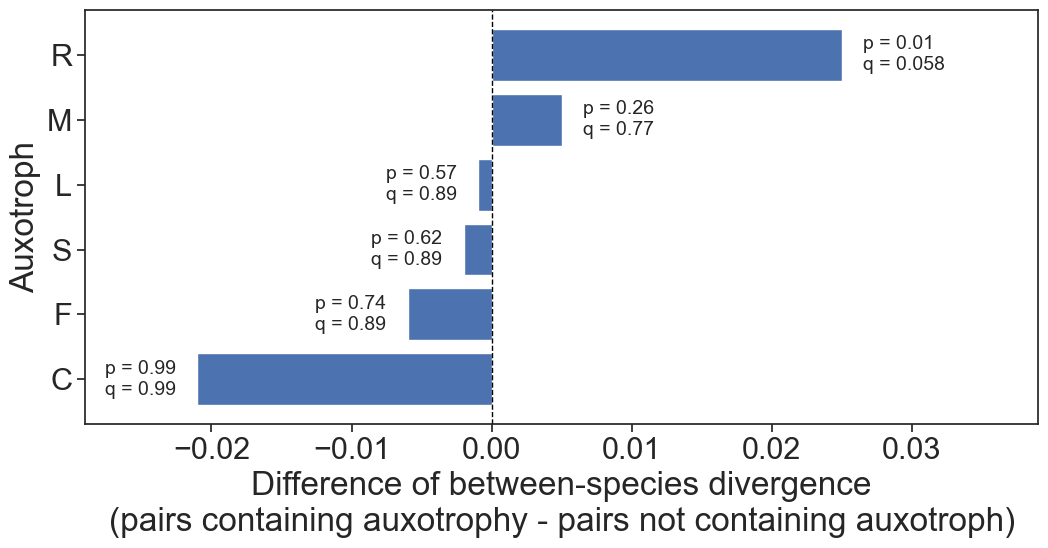

In [155]:
#Visualization of table S1, not used in manuscript

plot_df = results.sort_values("Contrast", ascending=True).copy()

fig, ax = plt.subplots(figsize=(11, 6)) 

# Bar plot 
bars = ax.barh(plot_df["Auxotrophy"], plot_df["Contrast"]) 

# Vertical zero line 
ax.axvline(0, color="black", linestyle="--", linewidth=1) 
ax.set_xlim(-0.029,0.039) 


# Axis labels 
ax.set_xlabel("Difference of between-species divergence\n"+ "(pairs containing auxotrophy - pairs not containing auxotroph)") 
ax.set_ylabel("Auxotroph") 

# Add p and q values next to each bar 
for i, row in plot_df.iterrows(): 
    x = row["Contrast"] 
    y = list(plot_df.index).index(i) 
    label = f"p = {row['Mann-WhitneyU_p']:.2g}\nq = {row['FDR_p']:.2g}" 
    if x >= 0: 
        ax.text(x + 0.0015, y, label, va="center", ha="left", fontsize=14) 
    else: 
        ax.text(x - 0.0015, y, label, va="center", ha="right", fontsize=14) 

plt.tight_layout() 
plt.show()
